In [1]:
print("Alzheimer GNN project started successfully!")

Alzheimer GNN project started successfully!


In [1]:
import sys

print("Python being used:")
print(sys.executable)

Python being used:
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Scripts\python.exe


In [2]:
import GEOparse

print("GEOparse version:", GEOparse.__version__)

GEOparse version: 2.0.4


In [3]:
import GEOparse
import os

# Project data directory
raw_dir = "../data/raw"

# Create the directory if it doesn't exist
os.makedirs(raw_dir, exist_ok=True)

# Download GSE63060
print("Downloading GSE63060...")

gse63060 = GEOparse.get_GEO(
    geo="GSE63060",
    destdir=raw_dir,
    silent=False
)

print("GSE63060 downloaded successfully!")

25-Aug-2026 22:44:10 DEBUG utils - Directory ../data/raw already exists. Skipping.
25-Aug-2026 22:44:10 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE63nnn/GSE63060/soft/GSE63060_family.soft.gz to ../data/raw\GSE63060_family.soft.gz


100%|██████████| 120M/120M [06:09<00:00, 340kB/s]    
25-Aug-2026 22:50:21 DEBUG downloader - Size validation passed
25-Aug-2026 22:50:21 DEBUG downloader - Moving C:\Users\91903\AppData\Local\Temp\tmpykv4d7fp to C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\raw\GSE63060_family.soft.gz
25-Aug-2026 22:50:22 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE63nnn/GSE63060/soft/GSE63060_family.soft.gz
25-Aug-2026 22:50:22 INFO GEOparse - Parsing ../data/raw\GSE63060_family.soft.gz: 
25-Aug-2026 22:50:22 DEBUG GEOparse - DATABASE: GeoMiame
25-Aug-2026 22:50:22 DEBUG GEOparse - SERIES: GSE63060
25-Aug-2026 22:50:22 DEBUG GEOparse - PLATFORM: GPL6947
25-Aug-2026 22:50:25 DEBUG GEOparse - SAMPLE: GSM1539080
25-Aug-2026 22:50:26 DEBUG GEOparse - SAMPLE: GSM1539081
25-Aug-2026 22:50:26 DEBUG GEOparse - SAMPLE: GSM1539082
25-Aug-2026 22:50:26 DEBUG GEOparse - SAMPLE: GSM1539083
25-Aug-2026 22:50:26 DEBUG GEOparse - SAMPLE: GSM1539084
25-Aug-20

GSE63060 downloaded successfully!


In [4]:
# Basic information about the GEO dataset

print("Dataset:", gse63060.name)
print("Number of samples:", len(gse63060.gsms))
print("Number of platforms:", len(gse63060.gpls))

print("\nSample IDs:")
print(list(gse63060.gsms.keys())[:10])

Dataset: GSE63060
Number of samples: 329
Number of platforms: 1

Sample IDs:
['GSM1539080', 'GSM1539081', 'GSM1539082', 'GSM1539083', 'GSM1539084', 'GSM1539085', 'GSM1539086', 'GSM1539087', 'GSM1539088', 'GSM1539089']


In [5]:
# Inspect the metadata of the first sample

sample_id = list(gse63060.gsms.keys())[0]
sample = gse63060.gsms[sample_id]

print("Sample ID:", sample_id)
print("\nAvailable metadata fields:")
print(sample.metadata.keys())

print("\nSample characteristics:")
print(sample.metadata.get("characteristics_ch1"))

Sample ID: GSM1539080

Available metadata fields:
dict_keys(['title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'taxid_ch1', 'characteristics_ch1', 'molecule_ch1', 'extract_protocol_ch1', 'label_ch1', 'label_protocol_ch1', 'hyb_protocol', 'scan_protocol', 'description', 'data_processing', 'platform_id', 'contact_name', 'contact_email', 'contact_institute', 'contact_address', 'contact_city', 'contact_zip/postal_code', 'contact_country', 'supplementary_file', 'series_id', 'data_row_count'])

Sample characteristics:
['status: MCI', 'ethnicity: Western European', 'age: 65', 'gender: Female', 'included in case -control study: yes', 'tissue: blood']


In [6]:
import pandas as pd

# Extract clinical information from all samples
sample_records = []

for sample_id, sample in gse63060.gsms.items():
    characteristics = sample.metadata.get("characteristics_ch1", [])

    record = {
        "sample_id": sample_id,
        "status": None,
        "age": None,
        "gender": None,
        "ethnicity": None,
        "tissue": None
    }

    # Extract each characteristic
    for item in characteristics:
        if ":" in item:
            key, value = item.split(":", 1)
            key = key.strip().lower()
            value = value.strip()

            if key == "status":
                record["status"] = value
            elif key == "age":
                record["age"] = value
            elif key == "gender":
                record["gender"] = value
            elif key == "ethnicity":
                record["ethnicity"] = value
            elif key == "tissue":
                record["tissue"] = value

    sample_records.append(record)

# Create a DataFrame
clinical_data = pd.DataFrame(sample_records)

print("Clinical data extracted successfully!")
print("\nNumber of samples:", len(clinical_data))

print("\nDiagnosis distribution:")
print(clinical_data["status"].value_counts())

print("\nFirst 10 samples:")
display(clinical_data.head(10))

Clinical data extracted successfully!

Number of samples: 329

Diagnosis distribution:
status
AD     145
CTL    104
MCI     80
Name: count, dtype: int64

First 10 samples:


,sample_id,status,age,gender,ethnicity,tissue
0,GSM1539080,MCI,65,Female,Western European,blood
1,GSM1539081,MCI,66,Female,Other Caucasian,blood
2,GSM1539082,MCI,67,Female,Western European,blood
3,GSM1539083,MCI,67,Female,Unknown,blood
4,GSM1539084,MCI,67,Female,Western European,blood
5,GSM1539085,MCI,68,Female,Western European,blood
6,GSM1539086,MCI,69,Female,Western European,blood
7,GSM1539087,MCI,69,Female,Western European,blood
8,GSM1539088,MCI,69,Female,Other Caucasian,blood
9,GSM1539089,MCI,69,Female,Other Caucasian,blood


In [7]:
# Save clinical metadata for future use

clinical_path = "../data/processed/GSE63060_clinical.csv"

clinical_data.to_csv(clinical_path, index=False)

print("Clinical metadata saved successfully!")
print("Location:", clinical_path)

Clinical metadata saved successfully!
Location: ../data/processed/GSE63060_clinical.csv


In [8]:
# Inspect the gene-expression table of the first sample

sample_id = list(gse63060.gsms.keys())[0]
sample = gse63060.gsms[sample_id]

print("Sample ID:", sample_id)
print("Expression table shape:", sample.table.shape)

print("\nColumns:")
print(sample.table.columns.tolist())

print("\nFirst 5 rows:")
display(sample.table.head())

Sample ID: GSM1539080
Expression table shape: (38323, 2)

Columns:
['ID_REF', 'VALUE']

First 5 rows:


,ID_REF,VALUE
0,ILMN_2055271,7.600951
1,ILMN_2383229,7.401991
2,ILMN_1806310,7.650042
3,ILMN_1779670,7.439318
4,ILMN_2321282,7.538710


In [9]:
# Inspect the GEO platform annotation

platform_id = list(gse63060.gpls.keys())[0]
platform = gse63060.gpls[platform_id]

print("Platform ID:", platform_id)
print("Platform table shape:", platform.table.shape)

print("\nPlatform annotation columns:")
print(platform.table.columns.tolist())

print("\nFirst 5 annotation rows:")
display(platform.table.head())

Platform ID: GPL6947
Platform table shape: (49576, 30)

Platform annotation columns:
['ID', 'nuID', 'Species', 'Source', 'Search_Key', 'Transcript', 'ILMN_Gene', 'Source_Reference_ID', 'RefSeq_ID', 'Unigene_ID', 'Entrez_Gene_ID', 'GI', 'Accession', 'Symbol', 'Protein_Product', 'Array_Address_Id', 'Probe_Type', 'Probe_Start', 'SEQUENCE', 'Chromosome', 'Probe_Chr_Orientation', 'Probe_Coordinates', 'Cytoband', 'Definition', 'Ontology_Component', 'Ontology_Process', 'Ontology_Function', 'Synonyms', 'Obsolete_Probe_Id', 'GB_ACC']

First 5 annotation rows:


,ID,nuID,Species,Source,Search_Key,Transcript,ILMN_Gene,Source_Reference_ID,RefSeq_ID,Unigene_ID,...,Probe_Chr_Orientation,Probe_Coordinates,Cytoband,Definition,Ontology_Component,Ontology_Process,Ontology_Function,Synonyms,Obsolete_Probe_Id,GB_ACC
0,ILMN_1725881,rp13_p1x6D80lNLk3c,Homo sapiens,RefSeq,ILMN_44919,ILMN_44919,LOC23117,XM_933824.1,XM_933824.1,NaN,...,-,21766363-21766363:21769901-21769949,16p12.2a,"PREDICTED: Homo sapiens KIAA0220-like protein,...",NaN,NaN,NaN,NaN,NaN,XM_933824.1
1,ILMN_1910180,NEX0oqCV8.er4HVfU4,Homo sapiens,Unigene,ILMN_127219,ILMN_127219,HS.575038,Hs.575038,NaN,Hs.575038,...,NaN,NaN,NaN,"Homo sapiens cDNA: FLJ21027 fis, clone CAE07110",NaN,NaN,NaN,NaN,NaN,AK024680
2,ILMN_1804174,KyqQynMZxJcruyylEU,Homo sapiens,RefSeq,ILMN_139282,ILMN_139282,FCGR2B,XM_938851.1,XM_938851.1,NaN,...,NaN,NaN,1q23.3b,"PREDICTED: Homo sapiens Fc fragment of IgG, lo...",NaN,NaN,NaN,NaN,NaN,XM_938851.1
3,ILMN_1796063,xXl7eXuF7sbPEp.KFI,Homo sapiens,RefSeq,ILMN_5006,ILMN_5006,TRIM44,NM_017583.3,NM_017583.3,NaN,...,+,35786070-35786119,11p13a,Homo sapiens tripartite motif-containing 44 (T...,intracellular [goid 5622] [evidence IEA],NaN,zinc ion binding [goid 8270] [evidence IEA]; m...,MGC3490; MC7; HSA249128; DIPB,MGC3490; MC7; HSA249128; DIPB,NM_017583.3
4,ILMN_1811966,9ckqJrioiaej9_ajeQ,Homo sapiens,RefSeq,ILMN_38756,ILMN_38756,LOC653895,XM_936379.1,XM_936379.1,NaN,...,NaN,NaN,10q11.23b,PREDICTED: Homo sapiens similar to protein ger...,NaN,NaN,NaN,NaN,NaN,XM_936379.1


In [10]:
# Build the sample × probe expression matrix

import pandas as pd
import numpy as np

print("Building expression matrix...")

expression_data = {}

for sample_id, sample in gse63060.gsms.items():
    table = sample.table
    
    # Keep probe ID and expression value
    expression_data[sample_id] = table.set_index("ID_REF")["VALUE"]

# Combine all samples into one DataFrame
expression_matrix = pd.DataFrame(expression_data)

print("Expression matrix created!")
print("Shape:", expression_matrix.shape)

print("\nFirst 5 rows:")
display(expression_matrix.head())

print("\nFirst 5 samples:")
print(expression_matrix.columns[:5].tolist())

Building expression matrix...
Expression matrix created!
Shape: (38323, 329)

First 5 rows:


,GSM1539080,GSM1539081,GSM1539082,GSM1539083,GSM1539084,GSM1539085,GSM1539086,GSM1539087,GSM1539088,GSM1539089,...,GSM1539399,GSM1539400,GSM1539401,GSM1539402,GSM1539403,GSM1539404,GSM1539405,GSM1539406,GSM1539407,GSM1539408
ID_REF,,,,,,,,,,,,,,,,,,,,,
ILMN_2055271,7.600951,7.672496,7.538046,7.577860,7.678150,7.821754,7.538325,7.595028,7.617149,7.893230,...,7.577844,7.657990,7.702664,7.549431,7.424009,7.563977,7.606099,7.545535,7.567928,7.567190
ILMN_2383229,7.401991,7.414577,7.406980,7.455003,7.354241,7.487114,7.473277,7.414765,7.369689,7.425769,...,7.420044,7.327676,7.395640,7.455264,7.437403,7.296285,7.476446,7.365189,7.385004,7.411265
ILMN_1806310,7.650042,7.469146,7.478494,7.486963,7.446429,7.576292,7.408330,7.554633,7.430346,7.568055,...,7.648986,7.528787,7.527087,7.393601,7.511023,7.447771,7.507259,7.411622,7.456276,7.646164
ILMN_1779670,7.439318,7.505310,7.542144,7.567281,7.450938,7.664372,7.461290,7.591936,7.413166,7.438316,...,7.505358,7.490749,7.426290,7.428289,7.449399,7.499828,7.557032,7.497207,7.582703,7.498368
ILMN_2321282,7.538710,7.687544,7.602953,7.657317,7.615673,7.603043,7.537349,7.661408,7.624915,7.431161,...,7.693395,7.560890,7.411534,7.397306,7.544783,7.556252,7.575734,7.539473,7.578211,7.541192



First 5 samples:
['GSM1539080', 'GSM1539081', 'GSM1539082', 'GSM1539083', 'GSM1539084']


In [11]:
# Verify the expression matrix

print("Expression matrix shape:", expression_matrix.shape)

# Count missing values
missing_values = expression_matrix.isnull().sum().sum()

print("Total missing values:", missing_values)

# Check whether all clinical samples exist in the expression matrix
clinical_sample_ids = set(clinical_data["sample_id"])
expression_sample_ids = set(expression_matrix.columns)

print("Clinical samples:", len(clinical_sample_ids))
print("Expression samples:", len(expression_sample_ids))

print("\nSamples missing from expression data:")
print(clinical_sample_ids - expression_sample_ids)

print("\nExtra samples in expression data:")
print(expression_sample_ids - clinical_sample_ids)

Expression matrix shape: (38323, 329)
Total missing values: 0
Clinical samples: 329
Expression samples: 329

Samples missing from expression data:
set()

Extra samples in expression data:
set()


In [12]:
# Create Probe ID -> Gene Symbol mapping

# Keep only the columns we need from the platform annotation
probe_annotation = platform.table[["ID", "Symbol"]].copy()

# Remove rows where the gene symbol is missing
probe_annotation = probe_annotation.dropna(subset=["Symbol"])

# Remove empty gene symbols
probe_annotation["Symbol"] = probe_annotation["Symbol"].astype(str).str.strip()
probe_annotation = probe_annotation[probe_annotation["Symbol"] != ""]

# Keep only probes that actually exist in our expression matrix
probe_annotation = probe_annotation[
    probe_annotation["ID"].isin(expression_matrix.index)
]

print("Number of annotated probes:", len(probe_annotation))
print("\nFirst 10 mappings:")
display(probe_annotation.head(10))

Number of annotated probes: 30061

First 10 mappings:


,ID,Symbol
0,ILMN_1725881,LOC23117
2,ILMN_1804174,FCGR2B
3,ILMN_1796063,TRIM44
4,ILMN_1811966,LOC653895
5,ILMN_1668162,DGAT2L3
8,ILMN_1793729,C15orf39
10,ILMN_2296644,PCDHGA9
11,ILMN_1711283,PCDHGA9
12,ILMN_1682799,STAMBPL1
16,ILMN_1665311,STH


In [13]:
# Keep only probes that have a valid gene annotation

annotated_probe_ids = probe_annotation["ID"].tolist()

expression_annotated = expression_matrix.loc[
    expression_matrix.index.intersection(annotated_probe_ids)
].copy()

print("Annotated expression matrix shape:")
print(expression_annotated.shape)

print("\nNumber of annotated probes retained:", len(expression_annotated))

Annotated expression matrix shape:
(30061, 329)

Number of annotated probes retained: 30061


In [14]:
# Add gene symbols to the expression matrix

probe_to_gene = probe_annotation.set_index("ID")["Symbol"]

expression_annotated["Gene_Symbol"] = expression_annotated.index.map(
    probe_to_gene
)

print("Gene symbols added successfully!")

print("\nFirst 10 rows:")
display(expression_annotated.head(10))

Gene symbols added successfully!

First 10 rows:


,GSM1539080,GSM1539081,GSM1539082,GSM1539083,GSM1539084,GSM1539085,GSM1539086,GSM1539087,GSM1539088,GSM1539089,...,GSM1539400,GSM1539401,GSM1539402,GSM1539403,GSM1539404,GSM1539405,GSM1539406,GSM1539407,GSM1539408,Gene_Symbol
ID_REF,,,,,,,,,,,,,,,,,,,,,
ILMN_2055271,7.600951,7.672496,7.538046,7.577860,7.678150,7.821754,7.538325,7.595028,7.617149,7.893230,...,7.657990,7.702664,7.549431,7.424009,7.563977,7.606099,7.545535,7.567928,7.567190,A1BG
ILMN_2383229,7.401991,7.414577,7.406980,7.455003,7.354241,7.487114,7.473277,7.414765,7.369689,7.425769,...,7.327676,7.395640,7.455264,7.437403,7.296285,7.476446,7.365189,7.385004,7.411265,A1CF
ILMN_1806310,7.650042,7.469146,7.478494,7.486963,7.446429,7.576292,7.408330,7.554633,7.430346,7.568055,...,7.528787,7.527087,7.393601,7.511023,7.447771,7.507259,7.411622,7.456276,7.646164,A1CF
ILMN_1779670,7.439318,7.505310,7.542144,7.567281,7.450938,7.664372,7.461290,7.591936,7.413166,7.438316,...,7.490749,7.426290,7.428289,7.449399,7.499828,7.557032,7.497207,7.582703,7.498368,A1CF
ILMN_2321282,7.538710,7.687544,7.602953,7.657317,7.615673,7.603043,7.537349,7.661408,7.624915,7.431161,...,7.560890,7.411534,7.397306,7.544783,7.556252,7.575734,7.539473,7.578211,7.541192,A26A1
ILMN_1671474,7.397005,7.371831,7.350322,7.399166,7.406877,7.399872,7.436121,7.448270,7.431444,7.647644,...,7.381889,7.422602,7.351778,7.368148,7.416650,7.365986,7.431059,7.513364,7.418343,A26A1
ILMN_1772582,7.466492,7.395266,7.417368,7.549804,7.439417,7.470780,7.501439,7.420647,7.472154,7.321115,...,7.453175,7.438215,7.487046,7.399601,7.465964,7.430598,7.460191,7.465247,7.508356,A26B1
ILMN_1653355,7.650277,7.905123,7.610028,7.647674,7.676041,7.698627,7.572017,7.731587,7.635251,7.888204,...,7.642863,7.703498,7.621314,7.610929,7.648049,7.682978,7.647467,7.677256,7.703001,A26C3
ILMN_1717783,7.370770,7.564370,7.389195,7.402531,7.375251,7.373232,7.340316,7.397447,7.399222,7.359797,...,7.376779,7.386679,7.445759,7.409352,7.353887,7.431597,7.373267,7.457233,7.395443,A26C3


In [15]:
# Convert probe-level expression to gene-level expression
# by averaging probes that map to the same gene

gene_expression = expression_annotated.drop(
    columns=[]
).groupby("Gene_Symbol").mean(numeric_only=True)

print("Gene-level expression matrix created!")

print("Shape:", gene_expression.shape)

print("\nFirst 10 genes:")
display(gene_expression.head(10))

Gene-level expression matrix created!
Shape: (21696, 329)

First 10 genes:


,GSM1539080,GSM1539081,GSM1539082,GSM1539083,GSM1539084,GSM1539085,GSM1539086,GSM1539087,GSM1539088,GSM1539089,...,GSM1539399,GSM1539400,GSM1539401,GSM1539402,GSM1539403,GSM1539404,GSM1539405,GSM1539406,GSM1539407,GSM1539408
Gene_Symbol,,,,,,,,,,,,,,,,,,,,,
A1BG,7.600951,7.672496,7.538046,7.577860,7.678150,7.821754,7.538325,7.595028,7.617149,7.893230,...,7.577844,7.657990,7.702664,7.549431,7.424009,7.563977,7.606099,7.545535,7.567928,7.567190
A1CF,7.497117,7.463011,7.475873,7.503082,7.417203,7.575926,7.447632,7.520444,7.404400,7.477380,...,7.524796,7.449071,7.449672,7.425718,7.465942,7.414628,7.513579,7.424673,7.474661,7.518599
A26A1,7.467857,7.529688,7.476638,7.528242,7.511275,7.501457,7.486735,7.554839,7.528179,7.539403,...,7.600568,7.471390,7.417068,7.374542,7.456466,7.486451,7.470860,7.485266,7.545788,7.479767
A26B1,7.466492,7.395266,7.417368,7.549804,7.439417,7.470780,7.501439,7.420647,7.472154,7.321115,...,7.475168,7.453175,7.438215,7.487046,7.399601,7.465964,7.430598,7.460191,7.465247,7.508356
A26C3,7.476685,7.651896,7.461754,7.488248,7.481259,7.479330,7.447321,7.547453,7.491914,7.586403,...,7.584207,7.466693,7.501507,7.481510,7.489715,7.478948,7.533513,7.520345,7.519412,7.494656
A2BP1,7.463816,7.570863,7.484247,7.508958,7.443698,7.474320,7.514130,7.539816,7.455747,7.386975,...,7.495746,7.461599,7.539739,7.481716,7.454672,7.532157,7.510385,7.494740,7.473062,7.495988
A2M,7.433537,7.356446,7.458673,7.393698,7.399299,7.522921,7.418918,7.489375,7.362017,7.483346,...,7.440928,7.365864,7.427213,7.382352,7.380700,7.385536,7.452687,7.497501,7.414949,7.404502
A3GALT2,7.407560,7.413902,7.520830,7.442423,7.458149,7.411331,7.449886,7.374093,7.345720,7.373735,...,7.417071,7.472809,7.389665,7.333756,7.513663,7.386734,7.424000,7.381801,7.332305,7.397823
A4GALT,7.476840,7.445267,7.314818,7.486045,7.428502,7.552807,7.451533,7.362040,7.382742,7.530549,...,7.385122,7.470115,7.470648,7.438565,7.397189,7.402466,7.488986,7.411593,7.471363,7.416447


In [16]:
# Convert probe-level expression to gene-level expression
# by averaging probes that map to the same gene

gene_expression = expression_annotated.drop(
    columns=[]
).groupby("Gene_Symbol").mean(numeric_only=True)

print("Gene-level expression matrix created!")

print("Shape:", gene_expression.shape)

print("\nFirst 10 genes:")
display(gene_expression.head(10))

Gene-level expression matrix created!
Shape: (21696, 329)

First 10 genes:


,GSM1539080,GSM1539081,GSM1539082,GSM1539083,GSM1539084,GSM1539085,GSM1539086,GSM1539087,GSM1539088,GSM1539089,...,GSM1539399,GSM1539400,GSM1539401,GSM1539402,GSM1539403,GSM1539404,GSM1539405,GSM1539406,GSM1539407,GSM1539408
Gene_Symbol,,,,,,,,,,,,,,,,,,,,,
A1BG,7.600951,7.672496,7.538046,7.577860,7.678150,7.821754,7.538325,7.595028,7.617149,7.893230,...,7.577844,7.657990,7.702664,7.549431,7.424009,7.563977,7.606099,7.545535,7.567928,7.567190
A1CF,7.497117,7.463011,7.475873,7.503082,7.417203,7.575926,7.447632,7.520444,7.404400,7.477380,...,7.524796,7.449071,7.449672,7.425718,7.465942,7.414628,7.513579,7.424673,7.474661,7.518599
A26A1,7.467857,7.529688,7.476638,7.528242,7.511275,7.501457,7.486735,7.554839,7.528179,7.539403,...,7.600568,7.471390,7.417068,7.374542,7.456466,7.486451,7.470860,7.485266,7.545788,7.479767
A26B1,7.466492,7.395266,7.417368,7.549804,7.439417,7.470780,7.501439,7.420647,7.472154,7.321115,...,7.475168,7.453175,7.438215,7.487046,7.399601,7.465964,7.430598,7.460191,7.465247,7.508356
A26C3,7.476685,7.651896,7.461754,7.488248,7.481259,7.479330,7.447321,7.547453,7.491914,7.586403,...,7.584207,7.466693,7.501507,7.481510,7.489715,7.478948,7.533513,7.520345,7.519412,7.494656
A2BP1,7.463816,7.570863,7.484247,7.508958,7.443698,7.474320,7.514130,7.539816,7.455747,7.386975,...,7.495746,7.461599,7.539739,7.481716,7.454672,7.532157,7.510385,7.494740,7.473062,7.495988
A2M,7.433537,7.356446,7.458673,7.393698,7.399299,7.522921,7.418918,7.489375,7.362017,7.483346,...,7.440928,7.365864,7.427213,7.382352,7.380700,7.385536,7.452687,7.497501,7.414949,7.404502
A3GALT2,7.407560,7.413902,7.520830,7.442423,7.458149,7.411331,7.449886,7.374093,7.345720,7.373735,...,7.417071,7.472809,7.389665,7.333756,7.513663,7.386734,7.424000,7.381801,7.332305,7.397823
A4GALT,7.476840,7.445267,7.314818,7.486045,7.428502,7.552807,7.451533,7.362040,7.382742,7.530549,...,7.385122,7.470115,7.470648,7.438565,7.397189,7.402466,7.488986,7.411593,7.471363,7.416447


In [18]:
# Save the processed gene-expression matrix

processed_expression_path = "../data/processed/GSE63060_gene_expression.csv"

gene_expression.to_csv(processed_expression_path)

print("Gene-expression matrix saved successfully!")
print("Location:", processed_expression_path)
print("Shape:", gene_expression.shape)

Gene-expression matrix saved successfully!
Location: ../data/processed/GSE63060_gene_expression.csv
Shape: (21696, 329)


In [19]:
# Download the second blood dataset: GSE63061

import GEOparse
import os

raw_dir = "../data/raw"
os.makedirs(raw_dir, exist_ok=True)

print("Downloading GSE63061...")

gse63061 = GEOparse.get_GEO(
    geo="GSE63061",
    destdir=raw_dir,
    silent=False
)

print("GSE63061 downloaded successfully!")

26-Aug-2026 00:15:28 DEBUG utils - Directory ../data/raw already exists. Skipping.
26-Aug-2026 00:15:28 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE63nnn/GSE63061/soft/GSE63061_family.soft.gz to ../data/raw\GSE63061_family.soft.gz


  7%|▋         | 9.13M/126M [01:11<15:14, 134kB/s]   
26-Aug-2026 00:16:41 ERROR downloader - Error when quiting FTP server.
Traceback (most recent call last):
  File "C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Lib\site-packages\GEOparse\downloader.py", line 177, in _download_ftp
    ftp.retrbinary("RETR %s" % parsed_url.path, _write)
  File "C:\Python312\Lib\ftplib.py", line 442, in retrbinary
    return self.voidresp()
           ^^^^^^^^^^^^^^^
  File "C:\Python312\Lib\ftplib.py", line 259, in voidresp
    resp = self.getresp()
           ^^^^^^^^^^^^^^
  File "C:\Python312\Lib\ftplib.py", line 244, in getresp
    resp = self.getmultiline()
           ^^^^^^^^^^^^^^^^^^^
  File "C:\Python312\Lib\ftplib.py", line 230, in getmultiline
    line = self.getline()
           ^^^^^^^^^^^^^^
  File "C:\Python312\Lib\ftplib.py", line 218, in getline
    raise EOFError
EOFError

During handling of the above exception, another exception occurred:

Traceback (most recent c

OSError: Download failed due to 'Downloaded size do not match the expected size for ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE63nnn/GSE63061/soft/GSE63061_family.soft.gz'. ID could be incorrect or the data might not be public yet.

In [20]:
# Try downloading GSE63061 using the HTTPS GEO URL

import GEOparse

gse63061 = GEOparse.get_GEO(
    geo="GSE63061",
    destdir="../data/raw",
    silent=False,
    get_suppl=False
)

print("GSE63061 downloaded successfully!")
print("Number of samples:", len(gse63061.gsms))
print("Number of platforms:", len(gse63061.gpls))

TypeError: get_GEO() got an unexpected keyword argument 'get_suppl'

In [21]:
# Download GSE63061 using GEOparse 2.0.4

import GEOparse

print("Downloading GSE63061...")

gse63061 = GEOparse.get_GEO(
    geo="GSE63061",
    destdir="../data/raw",
    silent=False
)

print("\nGSE63061 downloaded successfully!")
print("Number of samples:", len(gse63061.gsms))
print("Number of platforms:", len(gse63061.gpls))

26-Aug-2026 00:26:27 DEBUG utils - Directory ../data/raw already exists. Skipping.
26-Aug-2026 00:26:27 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE63nnn/GSE63061/soft/GSE63061_family.soft.gz to ../data/raw\GSE63061_family.soft.gz


100%|██████████| 126M/126M [00:24<00:00, 5.37MB/s]   
26-Aug-2026 00:26:53 DEBUG downloader - Size validation passed
26-Aug-2026 00:26:53 DEBUG downloader - Moving C:\Users\91903\AppData\Local\Temp\tmpvuksh0g1 to C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\raw\GSE63061_family.soft.gz
26-Aug-2026 00:26:54 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE63nnn/GSE63061/soft/GSE63061_family.soft.gz
26-Aug-2026 00:26:54 INFO GEOparse - Parsing ../data/raw\GSE63061_family.soft.gz: 
26-Aug-2026 00:26:54 DEBUG GEOparse - DATABASE: GeoMiame
26-Aug-2026 00:26:54 DEBUG GEOparse - SERIES: GSE63061
26-Aug-2026 00:26:54 DEBUG GEOparse - PLATFORM: GPL10558
26-Aug-2026 00:26:57 DEBUG GEOparse - SAMPLE: GSM1539409
26-Aug-2026 00:26:57 DEBUG GEOparse - SAMPLE: GSM1539410
26-Aug-2026 00:26:57 DEBUG GEOparse - SAMPLE: GSM1539411
26-Aug-2026 00:26:57 DEBUG GEOparse - SAMPLE: GSM1539412
26-Aug-2026 00:26:57 DEBUG GEOparse - SAMPLE: GSM1539413
26-Aug-2


GSE63061 downloaded successfully!
Number of samples: 388
Number of platforms: 1


In [22]:
# Inspect GSE63061

print("Dataset: GSE63061")
print("Number of samples:", len(gse63061.gsms))
print("Number of platforms:", len(gse63061.gpls))

# Get the first sample
sample_id = list(gse63061.gsms.keys())[0]
sample = gse63061.gsms[sample_id]

print("\nSample ID:", sample_id)

print("\nMetadata fields:")
print(sample.metadata.keys())

print("\nSample characteristics:")
print(sample.metadata.get("characteristics_ch1"))

Dataset: GSE63061
Number of samples: 388
Number of platforms: 1

Sample ID: GSM1539409

Metadata fields:
dict_keys(['title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'taxid_ch1', 'characteristics_ch1', 'molecule_ch1', 'extract_protocol_ch1', 'label_ch1', 'label_protocol_ch1', 'hyb_protocol', 'scan_protocol', 'description', 'data_processing', 'platform_id', 'contact_name', 'contact_email', 'contact_institute', 'contact_address', 'contact_city', 'contact_zip/postal_code', 'contact_country', 'supplementary_file', 'series_id', 'data_row_count'])

Sample characteristics:
['status: MCI', 'ethnicity: Western European', 'age: 57', 'gender: Female', 'included in case -control study: yes', 'tissue: blood']


In [23]:
# Extract clinical metadata from GSE63061

clinical_records_63061 = []

for sample_id, sample in gse63061.gsms.items():
    
    characteristics = sample.metadata.get("characteristics_ch1", [])
    
    record = {
        "sample_id": sample_id,
        "status": None,
        "age": None,
        "gender": None,
        "ethnicity": None,
        "tissue": None
    }
    
    for item in characteristics:
        if ":" in item:
            key, value = item.split(":", 1)
            key = key.strip().lower()
            value = value.strip()
            
            if key == "status":
                record["status"] = value
            elif key == "age":
                record["age"] = value
            elif key == "gender":
                record["gender"] = value
            elif key == "ethnicity":
                record["ethnicity"] = value
            elif key == "tissue":
                record["tissue"] = value
    
    clinical_records_63061.append(record)

clinical_data_63061 = pd.DataFrame(clinical_records_63061)

print("Clinical data extracted successfully!")
print("Number of samples:", len(clinical_data_63061))

print("\nDiagnosis distribution:")
print(clinical_data_63061["status"].value_counts())

print("\nFirst 10 samples:")
display(clinical_data_63061.head(10))

Clinical data extracted successfully!
Number of samples: 388

Diagnosis distribution:
status
AD                139
CTL               134
MCI               109
borderline MCI      3
OTHER               1
CTL to AD           1
MCI to CTL          1
Name: count, dtype: int64

First 10 samples:


,sample_id,status,age,gender,ethnicity,tissue
0,GSM1539409,MCI,57,Female,Western European,blood
1,GSM1539410,MCI,59,Female,Western European,blood
2,GSM1539411,MCI,63,Female,Western European,blood
3,GSM1539412,MCI,65,Female,Western European,blood
4,GSM1539413,MCI,66,Female,Other Caucasian,blood
5,GSM1539414,MCI,68,Female,Other Caucasian,blood
6,GSM1539415,MCI,68,Female,Western European,blood
7,GSM1539416,MCI,68,Female,Any_Other_White_Background,blood
8,GSM1539417,MCI,69,Female,Western European,blood
9,GSM1539418,MCI,69,Female,Western European,blood


In [24]:
# Save GSE63061 clinical metadata

clinical_path_63061 = "../data/processed/GSE63061_clinical.csv"

clinical_data_63061.to_csv(
    clinical_path_63061,
    index=False
)

print("GSE63061 clinical metadata saved successfully!")
print("Location:", clinical_path_63061)
print("Shape:", clinical_data_63061.shape)

GSE63061 clinical metadata saved successfully!
Location: ../data/processed/GSE63061_clinical.csv
Shape: (388, 6)


In [25]:
# Build GSE63061 sample × probe expression matrix

expression_data_63061 = {}

for sample_id, sample in gse63061.gsms.items():
    table = sample.table
    
    expression_data_63061[sample_id] = (
        table.set_index("ID_REF")["VALUE"]
    )

expression_matrix_63061 = pd.DataFrame(expression_data_63061)

print("GSE63061 expression matrix created!")
print("Shape:", expression_matrix_63061.shape)

print("\nColumns:")
print(expression_matrix_63061.columns[:5].tolist())

print("\nFirst 5 rows:")
display(expression_matrix_63061.head())

GSE63061 expression matrix created!
Shape: (32049, 388)

Columns:
['GSM1539409', 'GSM1539410', 'GSM1539411', 'GSM1539412', 'GSM1539413']

First 5 rows:


,GSM1539409,GSM1539410,GSM1539411,GSM1539412,GSM1539413,GSM1539414,GSM1539415,GSM1539416,GSM1539417,GSM1539418,...,GSM1539787,GSM1539788,GSM1539789,GSM1539790,GSM1539791,GSM1539792,GSM1539793,GSM1539794,GSM1539795,GSM1539796
ID_REF,,,,,,,,,,,,,,,,,,,,,
ILMN_2055271,6.363700,6.038703,6.149995,6.364765,6.154938,6.191011,6.077190,6.083526,6.150924,6.068465,...,6.061842,6.036401,6.175955,6.193858,6.135765,6.139319,6.192208,6.089414,6.207077,6.088177
ILMN_1806310,6.011438,6.028242,6.072813,6.041592,6.002227,6.030881,6.019253,6.086187,6.023414,6.018570,...,6.015723,6.037134,6.012498,6.024062,6.038613,6.020684,6.037401,6.030420,6.132552,6.050763
ILMN_1653355,6.047789,6.046343,6.049806,6.168538,6.020137,6.048805,6.072449,6.063969,6.216475,6.158167,...,6.068173,6.041389,6.005432,6.004483,6.059582,6.025457,6.091774,6.088321,6.005137,6.116739
ILMN_1705025,6.056324,6.018208,6.100712,6.039097,6.078827,6.064017,6.062970,6.046691,5.994122,6.023393,...,6.094439,6.038055,6.042364,6.031947,6.018305,6.104570,6.054604,6.058222,6.092721,6.058968
ILMN_1814316,6.038818,6.064710,6.029493,5.992093,6.049432,6.106142,6.068175,6.056363,6.170426,5.997212,...,6.014950,6.015656,6.014945,6.042580,6.064701,6.040905,6.018387,6.032869,6.042658,6.082210


In [26]:
# Verify GSE63061 expression matrix

print("Expression matrix shape:", expression_matrix_63061.shape)

# Check missing values
missing_values_63061 = expression_matrix_63061.isnull().sum().sum()

print("Total missing values:", missing_values_63061)

# Check clinical/expression sample alignment
clinical_sample_ids_63061 = set(clinical_data_63061["sample_id"])
expression_sample_ids_63061 = set(expression_matrix_63061.columns)

print("Clinical samples:", len(clinical_sample_ids_63061))
print("Expression samples:", len(expression_sample_ids_63061))

print("\nSamples missing from expression data:")
print(clinical_sample_ids_63061 - expression_sample_ids_63061)

print("\nExtra samples in expression data:")
print(expression_sample_ids_63061 - clinical_sample_ids_63061)

Expression matrix shape: (32049, 388)
Total missing values: 0
Clinical samples: 388
Expression samples: 388

Samples missing from expression data:
set()

Extra samples in expression data:
set()


In [27]:
# Inspect GSE63061 platform annotation

platform_id_63061 = list(gse63061.gpls.keys())[0]
platform_63061 = gse63061.gpls[platform_id_63061]

print("Platform ID:", platform_id_63061)
print("Platform table shape:", platform_63061.table.shape)

print("\nPlatform annotation columns:")
print(platform_63061.table.columns.tolist())

print("\nFirst 5 annotation rows:")
display(platform_63061.table.head())

Platform ID: GPL10558
Platform table shape: (48107, 30)

Platform annotation columns:
['ID', 'Species', 'Source', 'Search_Key', 'Transcript', 'ILMN_Gene', 'Source_Reference_ID', 'RefSeq_ID', 'Unigene_ID', 'Entrez_Gene_ID', 'GI', 'Accession', 'Symbol', 'Protein_Product', 'Probe_Id', 'Array_Address_Id', 'Probe_Type', 'Probe_Start', 'SEQUENCE', 'Chromosome', 'Probe_Chr_Orientation', 'Probe_Coordinates', 'Cytoband', 'Definition', 'Ontology_Component', 'Ontology_Process', 'Ontology_Function', 'Synonyms', 'Obsolete_Probe_Id', 'GB_ACC']

First 5 annotation rows:


,ID,Species,Source,Search_Key,Transcript,ILMN_Gene,Source_Reference_ID,RefSeq_ID,Unigene_ID,Entrez_Gene_ID,...,Probe_Chr_Orientation,Probe_Coordinates,Cytoband,Definition,Ontology_Component,Ontology_Process,Ontology_Function,Synonyms,Obsolete_Probe_Id,GB_ACC
0,ILMN_1343048,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ILMN_1343049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ILMN_1343050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ILMN_1343052,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ILMN_1343059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
# Create Probe ID -> Gene Symbol mapping for GSE63061

probe_annotation_63061 = platform_63061.table[["ID", "Symbol"]].copy()

# Remove probes without a gene symbol
probe_annotation_63061 = probe_annotation_63061.dropna(subset=["Symbol"])

# Clean gene symbols
probe_annotation_63061["Symbol"] = (
    probe_annotation_63061["Symbol"]
    .astype(str)
    .str.strip()
)

probe_annotation_63061 = probe_annotation_63061[
    probe_annotation_63061["Symbol"] != ""
]

# Keep only probes present in GSE63061
probe_annotation_63061 = probe_annotation_63061[
    probe_annotation_63061["ID"].isin(expression_matrix_63061.index)
]

print("Number of annotated probes:", len(probe_annotation_63061))

print("\nFirst 10 mappings:")
display(probe_annotation_63061.head(10))

Number of annotated probes: 29485

First 10 mappings:


,ID,Symbol
9,ILMN_1343291,EEF1A1
10,ILMN_1343295,GAPDH
782,ILMN_1651209,SLC35E2
783,ILMN_1651210,DUSP22
784,ILMN_1651221,LOC642820
785,ILMN_1651228,RPS28
786,ILMN_1651229,IPO13
789,ILMN_1651235,AFAP1
791,ILMN_1651237,CDT1
795,ILMN_1651254,LPP


In [29]:
# Keep only annotated probes

annotated_probe_ids_63061 = probe_annotation_63061["ID"].tolist()

expression_annotated_63061 = expression_matrix_63061.loc[
    expression_matrix_63061.index.intersection(annotated_probe_ids_63061)
].copy()

print("Annotated expression matrix shape:")
print(expression_annotated_63061.shape)

print("\nNumber of annotated probes retained:", len(expression_annotated_63061))

Annotated expression matrix shape:
(29485, 388)

Number of annotated probes retained: 29485


In [30]:
# Add gene symbols

probe_to_gene_63061 = (
    probe_annotation_63061
    .set_index("ID")["Symbol"]
)

expression_annotated_63061["Gene_Symbol"] = (
    expression_annotated_63061.index.map(probe_to_gene_63061)
)

print("Gene symbols added successfully!")

display(expression_annotated_63061.head(10))

Gene symbols added successfully!


,GSM1539409,GSM1539410,GSM1539411,GSM1539412,GSM1539413,GSM1539414,GSM1539415,GSM1539416,GSM1539417,GSM1539418,...,GSM1539788,GSM1539789,GSM1539790,GSM1539791,GSM1539792,GSM1539793,GSM1539794,GSM1539795,GSM1539796,Gene_Symbol
ID_REF,,,,,,,,,,,,,,,,,,,,,
ILMN_2055271,6.363700,6.038703,6.149995,6.364765,6.154938,6.191011,6.077190,6.083526,6.150924,6.068465,...,6.036401,6.175955,6.193858,6.135765,6.139319,6.192208,6.089414,6.207077,6.088177,A1BG
ILMN_1806310,6.011438,6.028242,6.072813,6.041592,6.002227,6.030881,6.019253,6.086187,6.023414,6.018570,...,6.037134,6.012498,6.024062,6.038613,6.020684,6.037401,6.030420,6.132552,6.050763,A1CF
ILMN_1653355,6.047789,6.046343,6.049806,6.168538,6.020137,6.048805,6.072449,6.063969,6.216475,6.158167,...,6.041389,6.005432,6.004483,6.059582,6.025457,6.091774,6.088321,6.005137,6.116739,A26C3
ILMN_1705025,6.056324,6.018208,6.100712,6.039097,6.078827,6.064017,6.062970,6.046691,5.994122,6.023393,...,6.038055,6.042364,6.031947,6.018305,6.104570,6.054604,6.058222,6.092721,6.058968,A26C3
ILMN_1814316,6.038818,6.064710,6.029493,5.992093,6.049432,6.106142,6.068175,6.056363,6.170426,5.997212,...,6.015656,6.014945,6.042580,6.064701,6.040905,6.018387,6.032869,6.042658,6.082210,A2BP1
ILMN_3241953,6.198930,6.070966,6.259749,6.093679,6.111665,6.162773,6.289074,6.127499,6.168364,6.275565,...,6.361426,6.241177,6.237171,6.316146,6.051709,6.489563,6.092555,6.106331,6.227365,A2LD1
ILMN_1735045,6.030613,6.021406,6.022062,6.045522,5.988470,6.024314,6.023234,6.142265,6.030940,6.015986,...,6.000266,6.005512,6.007118,6.011564,6.018924,6.011448,6.009287,6.013017,6.018795,A4GALT
ILMN_1680754,6.148308,6.016234,6.178030,6.046597,6.181509,6.057794,6.071654,6.140749,5.994042,6.035698,...,6.063819,5.988759,6.181744,6.068513,6.014391,6.220108,6.116415,6.166866,6.052033,A4GNT
ILMN_1659452,6.070764,6.103733,6.032812,6.207121,6.096123,6.160641,6.068349,6.067493,6.282986,6.075828,...,6.193649,6.111239,6.071312,6.111113,6.131690,6.078803,6.103064,6.120554,6.127596,AAA1


In [31]:
# Convert probe-level expression to gene-level expression
# by averaging probes belonging to the same gene

expression_values_63061 = expression_annotated_63061.drop(
    columns=["Gene_Symbol"]
)

gene_expression_63061 = (
    expression_values_63061
    .assign(
        Gene_Symbol=expression_annotated_63061["Gene_Symbol"].values
    )
    .groupby("Gene_Symbol")
    .mean()
)

print("GSE63061 gene-level expression matrix created!")

print("Shape:", gene_expression_63061.shape)

print("\nFirst 10 genes:")
display(gene_expression_63061.head(10))

GSE63061 gene-level expression matrix created!
Shape: (22336, 388)

First 10 genes:


,GSM1539409,GSM1539410,GSM1539411,GSM1539412,GSM1539413,GSM1539414,GSM1539415,GSM1539416,GSM1539417,GSM1539418,...,GSM1539787,GSM1539788,GSM1539789,GSM1539790,GSM1539791,GSM1539792,GSM1539793,GSM1539794,GSM1539795,GSM1539796
Gene_Symbol,,,,,,,,,,,,,,,,,,,,,
1-Dec,6.046115,6.068269,6.049894,6.022627,6.024455,6.032285,6.041519,6.097380,6.055382,6.040381,...,6.070379,6.019791,6.060869,6.001840,6.012847,6.050681,6.110553,6.017178,6.025379,6.011890
1-Mar,6.268807,6.332623,6.451657,6.204796,6.410122,6.526425,6.431104,6.289682,6.469253,6.459550,...,6.210341,6.608083,6.349841,6.529431,6.654037,6.393572,6.376821,6.375036,6.421969,6.387507
2-Mar,7.793198,7.822572,7.821084,8.183803,8.448412,7.998658,7.671086,7.996012,7.318005,7.918014,...,7.330036,7.554581,7.223048,7.726745,7.478217,7.546375,8.007593,7.813062,7.425039,7.516485
3-Mar,6.247908,6.253956,6.299298,6.242987,6.185270,6.403694,6.381164,6.370457,6.397395,6.288098,...,6.309668,6.312308,6.231579,6.279565,6.214461,6.252932,6.263650,6.132921,6.145381,6.347492
5-Mar,6.217792,6.146553,6.231308,6.073113,6.168115,6.097236,6.218997,6.156037,6.129694,6.200211,...,6.169637,6.203301,6.208575,6.225996,6.320607,6.226305,6.138989,6.176351,6.166644,6.200841
6-Mar,7.715288,7.815891,8.063262,8.299693,8.330396,7.837036,7.715559,8.032457,8.344247,7.540822,...,8.344159,7.624301,7.762073,7.881937,7.337826,8.170299,8.021647,8.116965,8.217646,7.912282
7-Mar,7.880070,7.950036,8.578855,7.528975,8.040028,7.936653,8.343031,7.875899,8.572679,9.082167,...,8.253655,9.068807,8.299452,8.970555,9.078151,7.806016,7.953865,8.569122,7.805071,8.373554
8-Mar,6.898175,6.631771,7.258313,7.545952,7.083462,7.209475,7.155780,7.390030,6.879505,6.640563,...,6.731366,6.540417,6.682825,7.027112,6.901844,6.963304,6.968087,6.976714,6.389516,6.672958
9-Mar,6.097052,6.110334,6.028404,6.125845,6.071435,6.074217,6.107329,6.044590,6.041566,6.137506,...,6.029066,6.096237,6.152306,6.083045,6.052117,6.062263,5.999827,6.016029,6.118710,6.031891


In [32]:
# Save GSE63061 gene-level expression matrix

gene_expression_path_63061 = "../data/processed/GSE63061_gene_expression.csv"

gene_expression_63061.to_csv(
    gene_expression_path_63061
)

print("GSE63061 gene-expression matrix saved successfully!")
print("Location:", gene_expression_path_63061)
print("Shape:", gene_expression_63061.shape)

GSE63061 gene-expression matrix saved successfully!
Location: ../data/processed/GSE63061_gene_expression.csv
Shape: (22336, 388)


In [2]:
import pandas as pd

# Load GSE63060
df = pd.read_csv("../data/processed/GSE63060_gene_expression.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns[:10])

print("\nMissing values:", df.isna().sum().sum())

print("\nNumber of genes:", df["Gene_Symbol"].nunique())
print("Number of samples:", len(df.columns) - 1)

Shape: (21696, 330)

First 5 rows:


,Gene_Symbol,GSM1539080,GSM1539081,GSM1539082,GSM1539083,GSM1539084,GSM1539085,GSM1539086,GSM1539087,GSM1539088,...,GSM1539399,GSM1539400,GSM1539401,GSM1539402,GSM1539403,GSM1539404,GSM1539405,GSM1539406,GSM1539407,GSM1539408
0,A1BG,7.600951,7.672496,7.538046,7.577860,7.678150,7.821754,7.538325,7.595028,7.617149,...,7.577844,7.657990,7.702664,7.549431,7.424009,7.563977,7.606099,7.545535,7.567928,7.567190
1,A1CF,7.497117,7.463011,7.475873,7.503082,7.417203,7.575926,7.447632,7.520444,7.404400,...,7.524796,7.449071,7.449672,7.425718,7.465942,7.414628,7.513579,7.424673,7.474661,7.518599
2,A26A1,7.467857,7.529688,7.476638,7.528242,7.511275,7.501457,7.486735,7.554839,7.528179,...,7.600568,7.471390,7.417068,7.374542,7.456466,7.486451,7.470860,7.485266,7.545788,7.479767
3,A26B1,7.466492,7.395266,7.417368,7.549804,7.439417,7.470780,7.501439,7.420647,7.472154,...,7.475168,7.453175,7.438215,7.487046,7.399601,7.465964,7.430598,7.460191,7.465247,7.508356
4,A26C3,7.476685,7.651896,7.461754,7.488248,7.481259,7.479330,7.447321,7.547453,7.491914,...,7.584207,7.466693,7.501507,7.481510,7.489715,7.478948,7.533513,7.520345,7.519412,7.494656



Column names:
Index(['Gene_Symbol', 'GSM1539080', 'GSM1539081', 'GSM1539082', 'GSM1539083',
       'GSM1539084', 'GSM1539085', 'GSM1539086', 'GSM1539087', 'GSM1539088'],
      dtype='object')

Missing values: 0

Number of genes: 21696
Number of samples: 329


In [3]:
expression = df.drop(columns=["Gene_Symbol"])

print("Minimum:", expression.min().min())
print("Maximum:", expression.max().max())
print("Mean:", expression.mean().mean())
print("Median:", expression.median().median())

Minimum: 7.20448891
Maximum: 15.04978951
Mean: 8.01643407492125
Median: 7.596431037


In [4]:
clinical = pd.read_csv("../data/processed/GSE63060_clinical.csv")

print("Shape:", clinical.shape)

display(clinical.head())

print("\nColumns:")
print(clinical.columns.tolist())

Shape: (329, 6)


,sample_id,status,age,gender,ethnicity,tissue
0,GSM1539080,MCI,65,Female,Western European,blood
1,GSM1539081,MCI,66,Female,Other Caucasian,blood
2,GSM1539082,MCI,67,Female,Western European,blood
3,GSM1539083,MCI,67,Female,Unknown,blood
4,GSM1539084,MCI,67,Female,Western European,blood



Columns:
['sample_id', 'status', 'age', 'gender', 'ethnicity', 'tissue']


In [6]:
print(clinical["status"].value_counts())

AD     145
CTL    104
MCI     80
Name: status, dtype: int64


In [7]:
print(clinical["status"].unique())

['MCI' 'CTL' 'AD']


In [8]:
expression_samples = expression.columns[1:]
clinical_samples = clinical["sample_id"]

print("Expression samples:", len(expression_samples))
print("Clinical samples:", len(clinical_samples))

print("\nMissing in clinical:")
print(set(expression_samples) - set(clinical_samples))

print("\nMissing in expression:")
print(set(clinical_samples) - set(expression_samples))

Expression samples: 328
Clinical samples: 329

Missing in clinical:
set()

Missing in expression:
{'GSM1539080'}


In [9]:
print("Expression shape:", expression.shape)

print("\nFirst 10 columns:")
print(expression.columns[:10].tolist())

print("\nLast 5 columns:")
print(expression.columns[-5:].tolist())

Expression shape: (21696, 329)

First 10 columns:
['GSM1539080', 'GSM1539081', 'GSM1539082', 'GSM1539083', 'GSM1539084', 'GSM1539085', 'GSM1539086', 'GSM1539087', 'GSM1539088', 'GSM1539089']

Last 5 columns:
['GSM1539404', 'GSM1539405', 'GSM1539406', 'GSM1539407', 'GSM1539408']


In [10]:
print("\nColumns containing GSM1539080:")
print([col for col in expression.columns if "GSM1539080" in str(col)])


Columns containing GSM1539080:
['GSM1539080']


In [11]:
display(expression.head())

,GSM1539080,GSM1539081,GSM1539082,GSM1539083,GSM1539084,GSM1539085,GSM1539086,GSM1539087,GSM1539088,GSM1539089,...,GSM1539399,GSM1539400,GSM1539401,GSM1539402,GSM1539403,GSM1539404,GSM1539405,GSM1539406,GSM1539407,GSM1539408
0,7.600951,7.672496,7.538046,7.577860,7.678150,7.821754,7.538325,7.595028,7.617149,7.893230,...,7.577844,7.657990,7.702664,7.549431,7.424009,7.563977,7.606099,7.545535,7.567928,7.567190
1,7.497117,7.463011,7.475873,7.503082,7.417203,7.575926,7.447632,7.520444,7.404400,7.477380,...,7.524796,7.449071,7.449672,7.425718,7.465942,7.414628,7.513579,7.424673,7.474661,7.518599
2,7.467857,7.529688,7.476638,7.528242,7.511275,7.501457,7.486735,7.554839,7.528179,7.539403,...,7.600568,7.471390,7.417068,7.374542,7.456466,7.486451,7.470860,7.485266,7.545788,7.479767
3,7.466492,7.395266,7.417368,7.549804,7.439417,7.470780,7.501439,7.420647,7.472154,7.321115,...,7.475168,7.453175,7.438215,7.487046,7.399601,7.465964,7.430598,7.460191,7.465247,7.508356
4,7.476685,7.651896,7.461754,7.488248,7.481259,7.479330,7.447321,7.547453,7.491914,7.586403,...,7.584207,7.466693,7.501507,7.481510,7.489715,7.478948,7.533513,7.520345,7.519412,7.494656


In [12]:
expression_samples = expression.columns
clinical_samples = clinical["sample_id"]

print("Expression samples:", len(expression_samples))
print("Clinical samples:", len(clinical_samples))

print("\nMissing in clinical:")
print(set(expression_samples) - set(clinical_samples))

print("\nMissing in expression:")
print(set(clinical_samples) - set(expression_samples))

Expression samples: 329
Clinical samples: 329

Missing in clinical:
set()

Missing in expression:
set()


In [13]:
print(expression.index[:10])
print(expression.index.name)

RangeIndex(start=0, stop=10, step=1)
None


In [14]:
print(type(expression.index))

<class 'pandas.core.indexes.range.RangeIndex'>


In [15]:
gene1 = expression.iloc[0]

print(gene1)

GSM1539080    7.600951
GSM1539081    7.672496
GSM1539082    7.538046
GSM1539083    7.577860
GSM1539084    7.678150
                ...   
GSM1539404    7.563977
GSM1539405    7.606099
GSM1539406    7.545535
GSM1539407    7.567928
GSM1539408    7.567190
Name: 0, Length: 329, dtype: float64


In [16]:
gene1_df = expression.iloc[[0]].T

gene1_df.columns = ["Gene_1_Expression"]

display(gene1_df)

,Gene_1_Expression
GSM1539080,7.600951
GSM1539081,7.672496
GSM1539082,7.538046
GSM1539083,7.577860
GSM1539084,7.678150
...,...
GSM1539404,7.563977
GSM1539405,7.606099
GSM1539406,7.545535
GSM1539407,7.567928


In [17]:
print("Expression shape:", expression.shape)

print("\nFirst 5 rows:")
display(expression.head())

print("\nFirst 5 index values:")
print(expression.index[:5])

print("\nNumber of columns:")
print(len(expression.columns))

print("\nFirst 5 column names:")
print(expression.columns[:5].tolist())

Expression shape: (21696, 329)

First 5 rows:


,GSM1539080,GSM1539081,GSM1539082,GSM1539083,GSM1539084,GSM1539085,GSM1539086,GSM1539087,GSM1539088,GSM1539089,...,GSM1539399,GSM1539400,GSM1539401,GSM1539402,GSM1539403,GSM1539404,GSM1539405,GSM1539406,GSM1539407,GSM1539408
0,7.600951,7.672496,7.538046,7.577860,7.678150,7.821754,7.538325,7.595028,7.617149,7.893230,...,7.577844,7.657990,7.702664,7.549431,7.424009,7.563977,7.606099,7.545535,7.567928,7.567190
1,7.497117,7.463011,7.475873,7.503082,7.417203,7.575926,7.447632,7.520444,7.404400,7.477380,...,7.524796,7.449071,7.449672,7.425718,7.465942,7.414628,7.513579,7.424673,7.474661,7.518599
2,7.467857,7.529688,7.476638,7.528242,7.511275,7.501457,7.486735,7.554839,7.528179,7.539403,...,7.600568,7.471390,7.417068,7.374542,7.456466,7.486451,7.470860,7.485266,7.545788,7.479767
3,7.466492,7.395266,7.417368,7.549804,7.439417,7.470780,7.501439,7.420647,7.472154,7.321115,...,7.475168,7.453175,7.438215,7.487046,7.399601,7.465964,7.430598,7.460191,7.465247,7.508356
4,7.476685,7.651896,7.461754,7.488248,7.481259,7.479330,7.447321,7.547453,7.491914,7.586403,...,7.584207,7.466693,7.501507,7.481510,7.489715,7.478948,7.533513,7.520345,7.519412,7.494656



First 5 index values:
RangeIndex(start=0, stop=5, step=1)

Number of columns:
329

First 5 column names:
['GSM1539080', 'GSM1539081', 'GSM1539082', 'GSM1539083', 'GSM1539084']


In [18]:
import pandas as pd

raw = pd.read_csv("../data/processed/GSE63060_gene_expression.csv", header=None)

print("Shape:", raw.shape)

print("\nFirst 5 rows and 5 columns:")
display(raw.iloc[:5, :5])

C:\Users\91903\AppData\Local\Temp\ipykernel_16120\1168414606.py:3: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,25

Shape: (21697, 330)

First 5 rows and 5 columns:


,0,1,2,3,4
0,Gene_Symbol,GSM1539080,GSM1539081,GSM1539082,GSM1539083
1,A1BG,7.600951059,7.672496374,7.538045926,7.57785984
2,A1CF,7.497116961,7.46301072,7.4758728539999995,7.5030822986666665
3,A26A1,7.4678573109999995,7.5296877685000005,7.4766376789999995,7.5282415675
4,A26B1,7.466492328,7.395265981,7.417368076,7.549804021


In [19]:
raw = pd.read_csv("../data/processed/GSE63060_gene_expression.csv")

print("Shape:", raw.shape)
print("\nColumns:")
print(raw.columns[:5].tolist())

print("\nFirst 5 genes:")
print(raw["Gene_Symbol"].head().tolist())

Shape: (21696, 330)

Columns:
['Gene_Symbol', 'GSM1539080', 'GSM1539081', 'GSM1539082', 'GSM1539083']

First 5 genes:
['A1BG', 'A1CF', 'A26A1', 'A26B1', 'A26C3']


In [20]:
# Set Gene_Symbol as the row index
expression = raw.set_index("Gene_Symbol")

print("Expression matrix shape:", expression.shape)

print("\nFirst 5 genes:")
print(expression.index[:5].tolist())

print("\nFirst 5 samples:")
print(expression.columns[:5].tolist())

display(expression.iloc[:5, :5])

Expression matrix shape: (21696, 329)

First 5 genes:
['A1BG', 'A1CF', 'A26A1', 'A26B1', 'A26C3']

First 5 samples:
['GSM1539080', 'GSM1539081', 'GSM1539082', 'GSM1539083', 'GSM1539084']


,GSM1539080,GSM1539081,GSM1539082,GSM1539083,GSM1539084
Gene_Symbol,,,,,
A1BG,7.600951,7.672496,7.538046,7.577860,7.678150
A1CF,7.497117,7.463011,7.475873,7.503082,7.417203
A26A1,7.467857,7.529688,7.476638,7.528242,7.511275
A26B1,7.466492,7.395266,7.417368,7.549804,7.439417
A26C3,7.476685,7.651896,7.461754,7.488248,7.481259


In [21]:
# Check for duplicate gene symbols
duplicate_genes = expression.index[expression.index.duplicated()]

print("Number of duplicate gene symbols:", len(duplicate_genes))

if len(duplicate_genes) > 0:
    print("\nDuplicate genes:")
    print(duplicate_genes.tolist()[:20])
else:
    print("No duplicate gene symbols found.")
    

Number of duplicate gene symbols: 0
No duplicate gene symbols found.


In [22]:
# Check for missing values
missing_values = expression.isna().sum().sum()

print("Total missing values:", missing_values)

if missing_values == 0:
    print("No missing values found.")
else:
    print("Missing values are present.")

Total missing values: 0
No missing values found.


In [23]:
print("Minimum expression value:", expression.min().min())
print("Maximum expression value:", expression.max().max())
print("Mean expression value:", expression.mean().mean())

Minimum expression value: 7.20448891
Maximum expression value: 15.04978951
Mean expression value: 8.01643407492125


In [24]:
gene_variance = expression.var(axis=1)

zero_variance_genes = (gene_variance == 0).sum()

print("Genes with zero variance:", zero_variance_genes)

Genes with zero variance: 0


In [25]:
print("Variance statistics:")
print(gene_variance.describe())

Variance statistics:
count    21696.000000
mean         0.031711
std          0.101126
min          0.000402
25%          0.003721
50%          0.006932
75%          0.026100
max          6.652558
dtype: float64


In [26]:
# Calculate variance for every gene
gene_variance = expression.var(axis=1)

# Keep genes above the 25th percentile of variance
variance_threshold = gene_variance.quantile(0.25)

print("Variance threshold:", variance_threshold)

Variance threshold: 0.0037210670589317963


In [27]:
# Keep genes with variance above the threshold
expression_filtered = expression.loc[
    gene_variance > variance_threshold
]

print("Original number of genes:", expression.shape[0])
print("Genes after variance filtering:", expression_filtered.shape[0])
print("Number of samples:", expression_filtered.shape[1])

Original number of genes: 21696
Genes after variance filtering: 16272
Number of samples: 329


In [28]:
print("Filtered expression matrix shape:", expression_filtered.shape)

print("\nFirst 5 genes:")
print(expression_filtered.index[:5].tolist())

print("\nFirst 5 samples:")
print(expression_filtered.columns[:5].tolist())

display(expression_filtered.iloc[:5, :5])

Filtered expression matrix shape: (16272, 329)

First 5 genes:
['A1BG', 'A4GALT', 'A4GNT', 'AAAS', 'AACS']

First 5 samples:
['GSM1539080', 'GSM1539081', 'GSM1539082', 'GSM1539083', 'GSM1539084']


,GSM1539080,GSM1539081,GSM1539082,GSM1539083,GSM1539084
Gene_Symbol,,,,,
A1BG,7.600951,7.672496,7.538046,7.577860,7.678150
A4GALT,7.476840,7.445267,7.314818,7.486045,7.428502
A4GNT,7.499282,7.656974,7.530972,7.542443,7.436986
AAAS,7.585404,7.612667,7.756228,7.984069,7.761655
AACS,8.148446,8.315475,7.912023,8.064728,7.977451


In [29]:
print("Clinical data shape:", clinical.shape)

print("\nClinical columns:")
print(clinical.columns.tolist())

display(clinical.head())

Clinical data shape: (329, 6)

Clinical columns:
['sample_id', 'status', 'age', 'gender', 'ethnicity', 'tissue']


,sample_id,status,age,gender,ethnicity,tissue
0,GSM1539080,MCI,65,Female,Western European,blood
1,GSM1539081,MCI,66,Female,Other Caucasian,blood
2,GSM1539082,MCI,67,Female,Western European,blood
3,GSM1539083,MCI,67,Female,Unknown,blood
4,GSM1539084,MCI,67,Female,Western European,blood


In [30]:
# Display columns that may contain diagnosis/group information
diagnosis_columns = [
    col for col in clinical.columns
    if any(word in col.lower() for word in
           ["diagn", "group", "disease", "status", "condition", "phenotype"])
]

print("Possible diagnosis columns:")
print(diagnosis_columns)

Possible diagnosis columns:
['status']


In [31]:
for col in diagnosis_columns:
    print("\n---", col, "---")
    print(clinical[col].value_counts(dropna=False))


--- status ---
AD     145
CTL    104
MCI     80
Name: status, dtype: int64


In [32]:
# Check whether expression samples and clinical samples match
expression_samples = expression_filtered.columns.tolist()
clinical_samples = clinical["sample_id"].tolist()

print("Number of expression samples:", len(expression_samples))
print("Number of clinical samples:", len(clinical_samples))

print("\nAll sample IDs match:",
      expression_samples == clinical_samples)

Number of expression samples: 329
Number of clinical samples: 329

All sample IDs match: True


In [33]:
# Check for any sample IDs present in one dataset but not the other
expression_set = set(expression_samples)
clinical_set = set(clinical_samples)

print("In expression but not clinical:",
      expression_set - clinical_set)

print("In clinical but not expression:",
      clinical_set - expression_set)

In expression but not clinical: set()
In clinical but not expression: set()


In [34]:
# Create ML input matrix X and target labels y

X = expression_filtered.T
y = clinical["status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX first 5 rows:")
display(X.iloc[:5, :5])

print("\ny label counts:")
print(y.value_counts())

X shape: (329, 16272)
y shape: (329,)

X first 5 rows:


Gene_Symbol,A1BG,A4GALT,A4GNT,AAAS,AACS
GSM1539080,7.600951,7.476840,7.499282,7.585404,8.148446
GSM1539081,7.672496,7.445267,7.656974,7.612667,8.315475
GSM1539082,7.538046,7.314818,7.530972,7.756228,7.912023
GSM1539083,7.577860,7.486045,7.542443,7.984069,8.064728
GSM1539084,7.678150,7.428502,7.436986,7.761655,7.977451



y label counts:
AD     145
CTL    104
MCI     80
Name: status, dtype: int64


In [35]:
from sklearn.preprocessing import LabelEncoder

# Convert AD / CTL / MCI into numerical labels
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Label mapping:")
for label, number in zip(label_encoder.classes_,
                         label_encoder.transform(label_encoder.classes_)):
    print(label, "→", number)

print("\nEncoded labels:")
print(y_encoded[:10])

Label mapping:
AD → 0
CTL → 1
MCI → 2

Encoded labels:
[2 2 2 2 2 2 2 2 2 2]


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts())

Training samples: (263, 16272)
Testing samples: (66, 16272)

Training class distribution:
0    116
1     83
2     64
dtype: int64

Testing class distribution:
0    29
1    21
2    16
dtype: int64


In [37]:
print("Original distribution:")
print(pd.Series(y_encoded).value_counts(normalize=True).sort_index())

print("\nTraining distribution:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

print("\nTesting distribution:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())

Original distribution:
0    0.440729
1    0.316109
2    0.243161
dtype: float64

Training distribution:
0    0.441065
1    0.315589
2    0.243346
dtype: float64

Testing distribution:
0    0.439394
1    0.318182
2    0.242424
dtype: float64


In [38]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select the top 1,000 genes using ANOVA F-test
selector = SelectKBest(score_func=f_classif, k=1000)

X_train_selected = selector.fit_transform(X_train, y_train)

print("Original training shape:", X_train.shape)
print("Selected training shape:", X_train_selected.shape)

Original training shape: (263, 16272)
Selected training shape: (263, 1000)


In [39]:
# Apply the feature selection learned from training data
X_test_selected = selector.transform(X_test)

print("Original testing shape:", X_test.shape)
print("Selected testing shape:", X_test_selected.shape)

Original testing shape: (66, 16272)
Selected testing shape: (66, 1000)


In [40]:
# Get the names of the selected genes
selected_gene_names = X_train.columns[selector.get_support()]

print("Number of selected genes:", len(selected_gene_names))

print("\nFirst 20 selected genes:")
print(selected_gene_names[:20].tolist())

Number of selected genes: 1000

First 20 selected genes:
['ABCA7', 'ABCE1', 'ACADM', 'ACADVL', 'ACAT1', 'ACIN1', 'ACN9', 'ACTR10', 'ACTR6', 'ADAM8', 'AGTPBP1', 'AIF1', 'AIM2', 'AK2', 'AKAP7', 'AKNA', 'AKR1C3', 'AKR1C4', 'ALG13', 'ALG5']


In [41]:
# Get ANOVA scores and p-values for all genes
feature_scores = pd.DataFrame({
    "Gene": X_train.columns,
    "F_score": selector.scores_,
    "p_value": selector.pvalues_
})

# Keep only the selected genes
selected_scores = feature_scores[
    selector.get_support()
].sort_values("F_score", ascending=False)

print("Selected genes:", len(selected_scores))
display(selected_scores.head(20))

Selected genes: 1000


,Gene,F_score,p_value
10053,MRPL51,71.925717,1.373167e-25
10387,NDUFA1,70.487309,3.478087e-25
13293,SHFM1,65.838131,7.345014e-24
10414,NDUFS5,62.608665,6.379390e-23
12764,RPL36AL,61.221391,1.632655e-22
5992,ING3,59.744422,4.473666e-22
3973,ENY2,58.114960,1.372784e-21
8064,LOC646200,58.109081,1.378373e-21
5767,HSPE1,57.840241,1.660019e-21
12714,RPA3,57.738682,1.780929e-21


In [42]:
print("Top 20 genes by ANOVA F-score:\n")

for i, row in selected_scores.head(20).reset_index(drop=True).iterrows():
    print(
        f"{i+1:2d}. {row['Gene']:10s} "
        f"F = {row['F_score']:.4f}, "
        f"p = {row['p_value']:.4e}"
    )

Top 20 genes by ANOVA F-score:

 1. MRPL51     F = 71.9257, p = 1.3732e-25
 2. NDUFA1     F = 70.4873, p = 3.4781e-25
 3. SHFM1      F = 65.8381, p = 7.3450e-24
 4. NDUFS5     F = 62.6087, p = 6.3794e-23
 5. RPL36AL    F = 61.2214, p = 1.6327e-22
 6. ING3       F = 59.7444, p = 4.4737e-22
 7. ENY2       F = 58.1150, p = 1.3728e-21
 8. LOC646200  F = 58.1091, p = 1.3784e-21
 9. HSPE1      F = 57.8402, p = 1.6600e-21
10. RPA3       F = 57.7387, p = 1.7809e-21
11. LOC654121  F = 55.7494, p = 7.1134e-21
12. CETN2      F = 54.1015, p = 2.2657e-20
13. BXDC1      F = 53.9041, p = 2.6047e-20
14. COX17      F = 53.7117, p = 2.9844e-20
15. UQCRB      F = 52.6092, p = 6.5265e-20
16. UQCRH      F = 52.4901, p = 7.1046e-20
17. TBCA       F = 51.5079, p = 1.4329e-19
18. GTF2H5     F = 51.5036, p = 1.4373e-19
19. PSMA3      F = 51.5016, p = 1.4394e-19
20. MRPL33     F = 51.1532, p = 1.8478e-19


In [43]:
print("Selected gene p-value statistics:")
print(selected_scores["p_value"].describe())

print("\nGenes with p < 0.05:",
      (selected_scores["p_value"] < 0.05).sum())

print("Genes with p < 0.01:",
      (selected_scores["p_value"] < 0.01).sum())

print("Genes with p < 0.001:",
      (selected_scores["p_value"] < 0.001).sum())

Selected gene p-value statistics:
count    1.000000e+03
mean     8.057647e-08
std      1.426499e-07
min      1.373167e-25
25%      9.917929e-12
50%      4.530897e-09
75%      9.650993e-08
max      6.223305e-07
Name: p_value, dtype: float64

Genes with p < 0.05: 1000
Genes with p < 0.01: 1000
Genes with p < 0.001: 1000


In [1]:
# Convert selected training data back to a DataFrame
X_train_selected_df = pd.DataFrame(
    X_train_selected,
    index=X_train.index,
    columns=selected_gene_names
)

print("Selected training matrix:", X_train_selected_df.shape)
display(X_train_selected_df.iloc[:5, :5])

NameError: name 'pd' is not defined

In [2]:
import pandas as pd

print("Pandas imported successfully.")

Pandas imported successfully.


In [3]:
X_train_selected_df = pd.DataFrame(
    X_train_selected,
    index=X_train.index,
    columns=selected_gene_names
)

print("Selected training matrix:", X_train_selected_df.shape)
display(X_train_selected_df.iloc[:5, :5])

NameError: name 'X_train_selected' is not defined

In [7]:
import pandas as pd
import numpy as np

raw = pd.read_csv(
    r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\GSE63060_gene_expression.csv"
)

print("Raw data shape:", raw.shape)
print(raw.columns[:5].tolist())

Raw data shape: (21696, 330)
['Gene_Symbol', 'GSM1539080', 'GSM1539081', 'GSM1539082', 'GSM1539083']


In [8]:
expression = raw.set_index("Gene_Symbol")

print("Expression matrix shape:", expression.shape)
print("Duplicate genes:", expression.index.duplicated().sum())
print("Missing values:", expression.isna().sum().sum())

Expression matrix shape: (21696, 329)
Duplicate genes: 0
Missing values: 0


In [9]:
import os

data_path = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed"

print("Files in processed folder:\n")

for file in os.listdir(data_path):
    print(file)

Files in processed folder:

GSE63060_clinical.csv
GSE63060_gene_expression.csv
GSE63060_gene_expression.zip
GSE63061_clinical.csv
GSE63061_gene_expression.csv


In [10]:
clinical = pd.read_csv(
    r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\GSE63060_clinical.csv"
)

print("Clinical data shape:", clinical.shape)
print("\nColumns:")
print(clinical.columns.tolist())

print("\nStatus distribution:")
print(clinical["status"].value_counts())

Clinical data shape: (329, 6)

Columns:
['sample_id', 'status', 'age', 'gender', 'ethnicity', 'tissue']

Status distribution:
AD     145
CTL    104
MCI     80
Name: status, dtype: int64


In [11]:
# Calculate variance for each gene
gene_variance = expression.var(axis=1)

# Same threshold we used previously: 25th percentile
variance_threshold = gene_variance.quantile(0.25)

# Filter low-variance genes
expression_filtered = expression.loc[
    gene_variance > variance_threshold
]

print("Variance threshold:", variance_threshold)
print("Original genes:", expression.shape[0])
print("Filtered genes:", expression_filtered.shape[0])
print("Samples:", expression_filtered.shape[1])

Variance threshold: 0.0037210670589317963
Original genes: 21696
Filtered genes: 16272
Samples: 329


In [12]:
# Transpose so rows = samples and columns = genes
X = expression_filtered.T

# Clinical labels
y = clinical["status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nLabels:")
print(y.value_counts())

X shape: (329, 16272)
y shape: (329,)

Labels:
AD     145
CTL    104
MCI     80
Name: status, dtype: int64


In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Label mapping:")
for label, number in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{label} → {number}")

Label mapping:
AD → 0
CTL → 1
MCI → 2


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training shape: (263, 16272)
Testing shape: (66, 16272)

Training distribution:
0    116
1     83
2     64
dtype: int64

Testing distribution:
0    29
1    21
2    16
dtype: int64


In [15]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=1000)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_gene_names = X_train.columns[selector.get_support()]

print("Training selected shape:", X_train_selected.shape)
print("Testing selected shape:", X_test_selected.shape)
print("Number of selected genes:", len(selected_gene_names))

print("\nFirst 20 selected genes:")
print(selected_gene_names[:20].tolist())

Training selected shape: (263, 1000)
Testing selected shape: (66, 1000)
Number of selected genes: 1000

First 20 selected genes:
['ABCA7', 'ABCE1', 'ACADM', 'ACADVL', 'ACAT1', 'ACIN1', 'ACN9', 'ACTR10', 'ACTR6', 'ADAM8', 'AGTPBP1', 'AIF1', 'AIM2', 'AK2', 'AKAP7', 'AKNA', 'AKR1C3', 'AKR1C4', 'ALG13', 'ALG5']


In [16]:
# Convert selected arrays back into DataFrames
X_train_selected_df = pd.DataFrame(
    X_train_selected,
    index=X_train.index,
    columns=selected_gene_names
)

X_test_selected_df = pd.DataFrame(
    X_test_selected,
    index=X_test.index,
    columns=selected_gene_names
)

print("Training selected:", X_train_selected_df.shape)
print("Testing selected:", X_test_selected_df.shape)

Training selected: (263, 1000)
Testing selected: (66, 1000)


In [17]:
data_path = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed"

X_train_selected_df.to_csv(
    data_path + r"\GSE63060_X_train_1000genes.csv"
)

X_test_selected_df.to_csv(
    data_path + r"\GSE63060_X_test_1000genes.csv"
)

print("Selected training and testing datasets saved successfully.")

Selected training and testing datasets saved successfully.


In [18]:
# Save labels
pd.DataFrame({
    "sample_id": X_train.index,
    "label": y_train
}).to_csv(
    data_path + r"\GSE63060_train_labels.csv",
    index=False
)

pd.DataFrame({
    "sample_id": X_test.index,
    "label": y_test
}).to_csv(
    data_path + r"\GSE63060_test_labels.csv",
    index=False
)

# Save selected gene names
pd.DataFrame({
    "Gene": selected_gene_names
}).to_csv(
    data_path + r"\GSE63060_selected_1000_genes.csv",
    index=False
)

print("Labels and selected gene list saved successfully.")

Labels and selected gene list saved successfully.


In [19]:
# Cell 1: Calculate gene-gene correlations using training data only

import numpy as np
import pandas as pd

# Correlation between the 1000 selected genes
gene_correlation = X_train_selected_df.corr(method="pearson")

print("Correlation matrix shape:", gene_correlation.shape)
print("\nFirst 5 rows:")
display(gene_correlation.iloc[:5, :5])

Correlation matrix shape: (1000, 1000)

First 5 rows:


Gene_Symbol,ABCA7,ABCE1,ACADM,ACADVL,ACAT1
Gene_Symbol,,,,,
ABCA7,1.000000,-0.553622,-0.521591,0.426104,-0.547489
ABCE1,-0.553622,1.000000,0.897136,-0.594388,0.787583
ACADM,-0.521591,0.897136,1.000000,-0.566818,0.788267
ACADVL,0.426104,-0.594388,-0.566818,1.000000,-0.487765
ACAT1,-0.547489,0.787583,0.788267,-0.487765,1.000000


In [20]:
# Cell 2: Inspect correlation strength

corr_values = gene_correlation.values

# Remove self-correlations (diagonal = 1)
upper_values = corr_values[np.triu_indices_from(corr_values, k=1)]

print("Minimum correlation:", upper_values.min())
print("Maximum correlation:", upper_values.max())
print("Mean correlation:", upper_values.mean())
print("Median correlation:", np.median(upper_values))

print("\nAbsolute correlation:")
print("Mean:", np.abs(upper_values).mean())
print("Median:", np.median(np.abs(upper_values)))

Minimum correlation: -0.8732305653360185
Maximum correlation: 0.9865384365904336
Mean correlation: 0.09170352738051137
Median correlation: 0.2984349297823585

Absolute correlation:
Mean: 0.5129655300178585
Median: 0.5221632251296449


In [21]:
# Cell 3: Check graph density at different correlation thresholds

thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]

for threshold in thresholds:
    mask = np.abs(gene_correlation.values) >= threshold
    
    # Keep only upper triangle to count each edge once
    edge_count = np.sum(
        np.triu(mask, k=1)
    )
    
    print(f"Threshold {threshold}: {edge_count} edges")

Threshold 0.5: 275996 edges
Threshold 0.6: 159103 edges
Threshold 0.7: 67276 edges
Threshold 0.8: 18471 edges
Threshold 0.9: 1765 edges


In [22]:
# Cell 4: Calculate average number of connections per gene

num_genes = len(gene_correlation)

for threshold in thresholds:
    mask = np.abs(gene_correlation.values) >= threshold
    
    # Remove self-connections
    np.fill_diagonal(mask, False)
    
    total_connections = np.sum(mask)
    avg_degree = total_connections / num_genes
    
    print(
        f"Threshold {threshold}: "
        f"Average connections per gene = {avg_degree:.2f}"
    )

Threshold 0.5: Average connections per gene = 551.99
Threshold 0.6: Average connections per gene = 318.21
Threshold 0.7: Average connections per gene = 134.55
Threshold 0.8: Average connections per gene = 36.94
Threshold 0.9: Average connections per gene = 3.53


In [23]:
# Cell 5: Create the gene-gene adjacency matrix

threshold = 0.8

adjacency_matrix = (
    np.abs(gene_correlation.values) >= threshold
).astype(int)

# Remove self-connections
np.fill_diagonal(adjacency_matrix, 0)

print("Adjacency matrix shape:", adjacency_matrix.shape)
print("Number of nodes:", adjacency_matrix.shape[0])
print("Number of edges:", adjacency_matrix.sum() // 2)
print("Average degree:", adjacency_matrix.sum() / adjacency_matrix.shape[0])

Adjacency matrix shape: (1000, 1000)
Number of nodes: 1000
Number of edges: 18471
Average degree: 36.942


In [24]:
# Cell 6: Convert adjacency matrix into an edge list

edge_indices = np.argwhere(
    np.triu(adjacency_matrix, k=1) == 1
)

edge_list = pd.DataFrame(
    edge_indices,
    columns=["source", "target"]
)

edge_list["source_gene"] = selected_gene_names[
    edge_list["source"]
].values

edge_list["target_gene"] = selected_gene_names[
    edge_list["target"]
].values

print("Edge list shape:", edge_list.shape)
display(edge_list.head(10))

Edge list shape: (18471, 4)


,source,target,source_gene,target_gene
0,1,2,ABCE1,ACADM
1,1,8,ABCE1,ACTR6
2,1,14,ABCE1,AKAP7
3,1,40,ABCE1,ARL6IP5
4,1,48,ABCE1,ATP5C1
5,1,50,ABCE1,ATP5F1
6,1,61,ABCE1,ATP6V1G1
7,1,66,ABCE1,BAT2
8,1,80,ABCE1,BXDC2
9,1,92,ABCE1,C14orf108


In [25]:
# Cell 7: Save the final graph

import os

processed_path = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed"

np.save(
    os.path.join(processed_path, "GSE63060_adjacency_1000genes.npy"),
    adjacency_matrix
)

edge_list.to_csv(
    os.path.join(processed_path, "GSE63060_gene_edges_1000.csv"),
    index=False
)

gene_correlation.to_csv(
    os.path.join(processed_path, "GSE63060_gene_correlation_1000.csv")
)

print("Graph files saved successfully.")

Graph files saved successfully.


In [26]:
# Cell 8: Verify graph files

print("Adjacency matrix:", adjacency_matrix.shape)
print("Edge list:", edge_list.shape)
print("Gene list:", len(selected_gene_names))

print("\nGraph summary:")
print("Nodes:", len(selected_gene_names))
print("Edges:", len(edge_list))
print("Average degree:", adjacency_matrix.sum() / len(selected_gene_names))

Adjacency matrix: (1000, 1000)
Edge list: (18471, 4)
Gene list: 1000

Graph summary:
Nodes: 1000
Edges: 18471
Average degree: 36.942


In [27]:
# Cell 9: Prepare node features for the GNN

# Training samples × genes
X_train_gnn = X_train_selected_df.values.astype(np.float32)

# Testing samples × genes
X_test_gnn = X_test_selected_df.values.astype(np.float32)

print("Training node features:", X_train_gnn.shape)
print("Testing node features:", X_test_gnn.shape)

print("\nOne training sample:")
print(X_train_gnn[0][:10])

Training node features: (263, 1000)
Testing node features: (66, 1000)

One training sample:
[ 8.021014  8.344358  8.601644  9.007661  8.503586 10.053018  8.08181
  8.963874  8.404756 10.632614]


In [28]:
# Cell 10: Verify GNN dimensions

num_nodes = len(selected_gene_names)

print("Number of graph nodes:", num_nodes)
print("Training feature dimensions:", X_train_gnn.shape[1])
print("Testing feature dimensions:", X_test_gnn.shape[1])

assert X_train_gnn.shape[1] == num_nodes
assert X_test_gnn.shape[1] == num_nodes

print("\n✓ Node count matches feature count")
print("✓ Training data matches graph")
print("✓ Testing data matches graph")

Number of graph nodes: 1000
Training feature dimensions: 1000
Testing feature dimensions: 1000

✓ Node count matches feature count
✓ Training data matches graph
✓ Testing data matches graph


In [29]:
# Cell 11: Check PyTorch and PyTorch Geometric

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

try:
    import torch_geometric
    print("PyTorch Geometric version:", torch_geometric.__version__)
except ImportError:
    print("PyTorch Geometric is NOT installed.")

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "C:\Users\91903\anaconda3\lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [30]:
import sys
import os

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\nEnvironment:")
print(os.environ.get("CONDA_DEFAULT_ENV"))

Python executable:
C:\Users\91903\anaconda3\python.exe

Python version:
3.10.9 | packaged by Anaconda, Inc. | (main, Mar  1 2023, 18:18:15) [MSC v.1916 64 bit (AMD64)]

Environment:
None


In [31]:
import os

venv_python = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Scripts\python.exe"

print("Project Python:")
print(venv_python)

print("\nPython exists:", os.path.exists(venv_python))

Project Python:
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Scripts\python.exe

Python exists: True


In [32]:
import subprocess

result = subprocess.run(
    [venv_python, "-c", "import torch; print(torch.__version__)"],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print("\nOutput:")
print(result.stdout)

print("Error:")
print(result.stderr)

Return code: 1

Output:

Error:
Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'torch'



In [33]:
import subprocess
import sys

venv_python = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Scripts\python.exe"

result = subprocess.run(
    [
        venv_python,
        "-m",
        "pip",
        "install",
        "torch",
        "torchvision",
        "torchaudio"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/124.1 MB 10.2 MB/s eta 0:00:13
    --------------------------------------- 1.6/124.1 MB 20.9 MB/s eta 0:00:06
    --------------------------------------- 2.6/124.1 MB 27.9 MB/s eta 0:00:05
   - -------------------------------------- 3.6/124.1 MB 22.9 MB/s eta 0:00:06
   - -------------------------------------- 4.7/124.1 MB 25.2 MB/s eta 0:00:05
   -- ------------------------------------- 6.7/124.1 MB 28.5 MB/s eta 0:00:05
   -- ------------------------------------- 7.9/124.1 MB 28.1 MB/s eta 0:00:05
   -- ------------------------------------- 9.0/124.1 MB 27.5 MB/s eta 0:00:05
   --- ------------------------------------ 10.5/124.1 MB 29.7 MB/s eta 0:00:04
   --- ------------------------------------ 11.7/124.1 MB 29.7 MB/s eta 0:00:04
   ---- ----

In [34]:
result = subprocess.run(
    [
        venv_python,
        "-c",
        "import torch; print('PyTorch:', torch.__version__); print('CUDA:', torch.cuda.is_available())"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

PyTorch: 2.14.0+cpu
CUDA: False




In [35]:
# Cell 13: Install PyTorch Geometric in the project venv

import subprocess

result = subprocess.run(
    [
        venv_python,
        "-m",
        "pip",
        "install",
        "torch-geometric"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

     ---------------------------------------- 0.0/64.4 kB ? eta -:--:--
     ---------------------------------------- 0.0/64.4 kB ? eta -:--:--
     ------ --------------------------------- 10.2/64.4 kB ? eta -:--:--
     ------ --------------------------------- 10.2/64.4 kB ? eta -:--:--
     ------------------ ------------------- 30.7/64.4 kB 262.6 kB/s eta 0:00:01
     ------------------------------------ - 61.4/64.4 kB 328.2 kB/s eta 0:00:01
     -------------------------------------- 64.4/64.4 kB 316.8 kB/s eta 0:00:00
     ---------------------------------------- 0.0/107.2 kB ? eta -:--:--
     -------------------------------------- 107.2/107.2 kB 3.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ----------------------- ---------------- 0.8/1.3 MB 25.1 MB/s eta 0:00:01
   ---------------------------------------  1.3/1.3 MB 27.9 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 14.0 MB/s eta 0:00:00
   --------------

In [36]:
# Cell 14: Verify PyTorch Geometric

result = subprocess.run(
    [
        venv_python,
        "-c",
        """
import torch
import torch_geometric

print("PyTorch:", torch.__version__)
print("PyTorch Geometric:", torch_geometric.__version__)

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv

print("✓ Data")
print("✓ DataLoader")
print("✓ GCNConv")
"""
    ],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

PyTorch: 2.14.0+cpu
PyTorch Geometric: 2.8.0.post1

C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
Traceback (most recent call last):
  File "<string>", line 12, in <module>
  File "C:\Python312\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2713' in position 0: character maps to <undefined>



In [37]:
import subprocess

result = subprocess.run(
    [
        venv_python,
        "-m",
        "pip",
        "install",
        "ipykernel"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Scripts\python.exe -m pip install --upgrade pip



In [38]:
result = subprocess.run(
    [
        venv_python,
        "-m",
        "ipykernel",
        "install",
        "--user",
        "--name",
        "alzheimer-gnn",
        "--display-name",
        "Python (Alzheimer GNN)"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

Installed kernelspec alzheimer-gnn in C:\Users\91903\AppData\Roaming\jupyter\kernels\alzheimer-gnn




In [1]:
import sys
import torch
import torch_geometric

print("Python:")
print(sys.executable)

print("\nPyTorch:", torch.__version__)
print("PyTorch Geometric:", torch_geometric.__version__)
print("CUDA:", torch.cuda.is_available())

C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Python:
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Scripts\python.exe

PyTorch: 2.14.0+cpu
PyTorch Geometric: 2.8.0.post1
CUDA: False


In [2]:
# Cell 17: Reload saved GNN data

import os
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data

processed_path = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed"

# Training and testing features
X_train_selected_df = pd.read_csv(
    os.path.join(processed_path, "GSE63060_X_train_1000genes.csv"),
    index_col=0
)

X_test_selected_df = pd.read_csv(
    os.path.join(processed_path, "GSE63060_X_test_1000genes.csv"),
    index_col=0
)

# Labels
train_labels = pd.read_csv(
    os.path.join(processed_path, "GSE63060_train_labels.csv"),
    index_col=0
)

test_labels = pd.read_csv(
    os.path.join(processed_path, "GSE63060_test_labels.csv"),
    index_col=0
)

# Gene list
selected_genes_df = pd.read_csv(
    os.path.join(processed_path, "GSE63060_selected_1000_genes.csv")
)

# Graph
adjacency_matrix = np.load(
    os.path.join(processed_path, "GSE63060_adjacency_1000genes.npy")
)

print("Training:", X_train_selected_df.shape)
print("Testing:", X_test_selected_df.shape)
print("Train labels:", train_labels.shape)
print("Test labels:", test_labels.shape)
print("Adjacency:", adjacency_matrix.shape)
print("Selected genes:", selected_genes_df.shape)

Training: (263, 1000)
Testing: (66, 1000)
Train labels: (263, 1)
Test labels: (66, 1)
Adjacency: (1000, 1000)
Selected genes: (1000, 1)


In [3]:
# Cell 18: Verify the reloaded data

print("Training samples:", len(X_train_selected_df))
print("Testing samples:", len(X_test_selected_df))

print("\nFirst training sample:")
display(X_train_selected_df.iloc[0, :5])

print("\nTraining labels:")
display(train_labels.head())

print("\nSelected genes:")
display(selected_genes_df.head())

print("\nGraph edges:", adjacency_matrix.sum() // 2)

Training samples: 263
Testing samples: 66

First training sample:


ABCA7     8.021015
ABCE1     8.344358
ACADM     8.601643
ACADVL    9.007661
ACAT1     8.503586
Name: GSM1539183, dtype: float64


Training labels:


,label
sample_id,
GSM1539183,1
GSM1539281,0
GSM1539158,1
GSM1539251,0
GSM1539208,0



Selected genes:


,Gene
0,ABCA7
1,ABCE1
2,ACADM
3,ACADVL
4,ACAT1



Graph edges: 18471


In [4]:
# Cell 19: Check label distribution and mapping

print("Training label counts:")
print(train_labels["label"].value_counts())

print("\nTesting label counts:")
print(test_labels["label"].value_counts())

print("\nUnique labels:")
print(sorted(train_labels["label"].unique()))

Training label counts:
label
0    116
1     83
2     64
Name: count, dtype: int64

Testing label counts:
label
0    29
1    21
2    16
Name: count, dtype: int64

Unique labels:
[np.int64(0), np.int64(1), np.int64(2)]


In [5]:
# Cell 20: Check sample IDs against the original clinical data

clinical_path = os.path.join(
    processed_path,
    "GSE63060_clinical.csv"
)

clinical_df = pd.read_csv(clinical_path, index_col=0)

print("Clinical data shape:", clinical_df.shape)
print("\nClinical columns:")
print(clinical_df.columns.tolist())

print("\nFirst few clinical records:")
display(clinical_df.head())

Clinical data shape: (329, 5)

Clinical columns:
['status', 'age', 'gender', 'ethnicity', 'tissue']

First few clinical records:


,status,age,gender,ethnicity,tissue
sample_id,,,,,
GSM1539080,MCI,65,Female,Western European,blood
GSM1539081,MCI,66,Female,Other Caucasian,blood
GSM1539082,MCI,67,Female,Western European,blood
GSM1539083,MCI,67,Female,Unknown,blood
GSM1539084,MCI,67,Female,Western European,blood


In [6]:
# Cell 21: Verify numerical label mapping

train_check = train_labels.copy()

# Add the actual clinical status
train_check["clinical_status"] = clinical_df.loc[
    train_check.index, "status"
]

print("Label → Clinical Status")
print(
    train_check
    .groupby("label")["clinical_status"]
    .value_counts()
)

print("\nCross-tabulation:")
print(
    pd.crosstab(
        train_check["label"],
        train_check["clinical_status"]
    )
)

Label → Clinical Status
label  clinical_status
0      AD                 116
1      CTL                 83
2      MCI                 64
Name: count, dtype: int64

Cross-tabulation:
clinical_status   AD  CTL  MCI
label                         
0                116    0    0
1                  0   83    0
2                  0    0   64


In [7]:
# Cell 22: Create PyTorch Geometric patient graphs

from torch_geometric.data import Data

# --------------------------------------------------
# Convert adjacency matrix → edge_index
# --------------------------------------------------

# Find all non-zero connections
edge_indices = np.nonzero(adjacency_matrix)

# Convert to PyTorch format
edge_index = torch.tensor(
    np.array(edge_indices),
    dtype=torch.long
)

print("Edge index shape:", edge_index.shape)
print("Number of edge entries:", edge_index.shape[1])


# --------------------------------------------------
# Function to create one patient graph
# --------------------------------------------------

def create_patient_graph(sample_id, expression_df, labels_df):
    
    # Get this patient's 1000 gene-expression values
    expression_values = expression_df.loc[sample_id].values
    
    # Convert to tensor
    x = torch.tensor(
        expression_values,
        dtype=torch.float
    ).view(-1, 1)
    
    # Get patient label
    label = int(labels_df.loc[sample_id, "label"])
    
    # Convert label to tensor
    y = torch.tensor(
        [label],
        dtype=torch.long
    )
    
    # Create PyTorch Geometric graph
    graph = Data(
        x=x,
        edge_index=edge_index,
        y=y
    )
    
    # Store sample ID for tracking
    graph.sample_id = sample_id
    
    return graph


# --------------------------------------------------
# Create training graphs
# --------------------------------------------------

train_graphs = []

for sample_id in X_train_selected_df.index:
    graph = create_patient_graph(
        sample_id,
        X_train_selected_df,
        train_labels
    )
    train_graphs.append(graph)


# --------------------------------------------------
# Create testing graphs
# --------------------------------------------------

test_graphs = []

for sample_id in X_test_selected_df.index:
    graph = create_patient_graph(
        sample_id,
        X_test_selected_df,
        test_labels
    )
    test_graphs.append(graph)


print("\nTraining graphs:", len(train_graphs))
print("Testing graphs:", len(test_graphs))

Edge index shape: torch.Size([2, 36942])
Number of edge entries: 36942

Training graphs: 263
Testing graphs: 66


In [8]:
# Cell 23: Inspect the first patient graph

graph = train_graphs[0]

print(graph)

print("\nSample ID:", graph.sample_id)
print("Node features shape:", graph.x.shape)
print("Edge index shape:", graph.edge_index.shape)
print("Label:", graph.y.item())

print("\nFirst 5 node features:")
print(graph.x[:5])

Data(x=[1000, 1], edge_index=[2, 36942], y=[1], sample_id='GSM1539183')

Sample ID: GSM1539183
Node features shape: torch.Size([1000, 1])
Edge index shape: torch.Size([2, 36942])
Label: 1

First 5 node features:
tensor([[8.0210],
        [8.3444],
        [8.6016],
        [9.0077],
        [8.5036]])


In [9]:
# Cell 24: Validate all patient graphs

print("========== TRAINING GRAPHS ==========")

print("Number of graphs:", len(train_graphs))

print(
    "Unique node counts:",
    set(graph.x.shape[0] for graph in train_graphs)
)

print(
    "Unique feature dimensions:",
    set(graph.x.shape[1] for graph in train_graphs)
)

print(
    "Unique edge counts:",
    set(graph.edge_index.shape[1] for graph in train_graphs)
)

print(
    "Unique labels:",
    sorted(set(graph.y.item() for graph in train_graphs))
)


print("\n========== TESTING GRAPHS ==========")

print("Number of graphs:", len(test_graphs))

print(
    "Unique node counts:",
    set(graph.x.shape[0] for graph in test_graphs)
)

print(
    "Unique feature dimensions:",
    set(graph.x.shape[1] for graph in test_graphs)
)

print(
    "Unique edge counts:",
    set(graph.edge_index.shape[1] for graph in test_graphs)
)

print(
    "Unique labels:",
    sorted(set(graph.y.item() for graph in test_graphs))
)


# --------------------------------------------------
# Check for NaN / Inf
# --------------------------------------------------

train_bad = sum(
    torch.isnan(graph.x).any().item() or
    torch.isinf(graph.x).any().item()
    for graph in train_graphs
)

test_bad = sum(
    torch.isnan(graph.x).any().item() or
    torch.isinf(graph.x).any().item()
    for graph in test_graphs
)

print("\n========== DATA QUALITY ==========")
print("Training graphs with NaN/Inf:", train_bad)
print("Testing graphs with NaN/Inf:", test_bad)

========== TRAINING GRAPHS ==========
Number of graphs: 263
Unique node counts: {1000}
Unique feature dimensions: {1}
Unique edge counts: {36942}
Unique labels: [0, 1, 2]

========== TESTING GRAPHS ==========
Number of graphs: 66
Unique node counts: {1000}
Unique feature dimensions: {1}
Unique edge counts: {36942}
Unique labels: [0, 1, 2]

========== DATA QUALITY ==========
Training graphs with NaN/Inf: 0
Testing graphs with NaN/Inf: 0


In [10]:
# Cell 25: Create DataLoaders

from torch_geometric.loader import DataLoader

# Batch size
BATCH_SIZE = 16

# Training DataLoader
train_loader = DataLoader(
    train_graphs,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Testing DataLoader
test_loader = DataLoader(
    test_graphs,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training graphs:", len(train_graphs))
print("Testing graphs:", len(test_graphs))

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training graphs: 263
Testing graphs: 66
Training batches: 17
Testing batches: 5


In [11]:
# Cell 26: Inspect one batch

batch = next(iter(train_loader))

print(batch)

print("\nNode features:", batch.x.shape)
print("Edges:", batch.edge_index.shape)
print("Labels:", batch.y.shape)
print("Number of graphs in batch:", batch.num_graphs)

print("\nLabels in this batch:")
print(batch.y)

DataBatch(x=[16000, 1], edge_index=[2, 591072], y=[16], sample_id=[16], batch=[16000], ptr=[17])

Node features: torch.Size([16000, 1])
Edges: torch.Size([2, 591072])
Labels: torch.Size([16])
Number of graphs in batch: 16

Labels in this batch:
tensor([0, 1, 0, 1, 1, 0, 2, 1, 2, 0, 1, 1, 0, 1, 2, 2])


In [12]:
# Cell 27: Define the GNN model

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv, global_mean_pool


class AlzheimerGCN(nn.Module):

    def __init__(self, input_dim=1, hidden_dim=64, num_classes=3):
        super().__init__()

        # First graph convolution
        self.conv1 = GCNConv(
            input_dim,
            hidden_dim
        )

        # Second graph convolution
        self.conv2 = GCNConv(
            hidden_dim,
            hidden_dim
        )

        # Dropout to reduce overfitting
        self.dropout = nn.Dropout(0.3)

        # Final classification layer
        self.fc = nn.Linear(
            hidden_dim,
            num_classes
        )

    def forward(self, x, edge_index, batch):

        # Graph convolution 1
        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.dropout(x)

        # Graph convolution 2
        x = self.conv2(
            x,
            edge_index
        )

        x = F.relu(x)

        # Convert node representations
        # into one representation per patient
        x = global_mean_pool(
            x,
            batch
        )

        # Final classifier
        x = self.fc(x)

        return x


# Create model
model = AlzheimerGCN(
    input_dim=1,
    hidden_dim=64,
    num_classes=3
)

print(model)

AlzheimerGCN(
  (conv1): GCNConv(1, 64)
  (conv2): GCNConv(64, 64)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)


In [13]:
# Cell 28: Test GNN forward pass

model.eval()

with torch.no_grad():

    output = model(
        batch.x,
        batch.edge_index,
        batch.batch
    )

print("Input nodes:", batch.x.shape)
print("Output shape:", output.shape)

print("\nModel output:")
print(output)

print("\nPredicted classes:")
print(output.argmax(dim=1))

Input nodes: torch.Size([16000, 1])
Output shape: torch.Size([16, 3])

Model output:
tensor([[-0.0674,  0.2373, -0.0673],
        [-0.0663,  0.2358, -0.0665],
        [-0.0679,  0.2379, -0.0676],
        [-0.0702,  0.2412, -0.0694],
        [-0.0690,  0.2395, -0.0685],
        [-0.0737,  0.2460, -0.0721],
        [-0.0673,  0.2371, -0.0672],
        [-0.0662,  0.2356, -0.0664],
        [-0.0670,  0.2368, -0.0670],
        [-0.0691,  0.2396, -0.0685],
        [-0.0753,  0.2483, -0.0733],
        [-0.0746,  0.2472, -0.0727],
        [-0.0696,  0.2403, -0.0689],
        [-0.0747,  0.2473, -0.0728],
        [-0.0675,  0.2374, -0.0673],
        [-0.0677,  0.2377, -0.0675]])

Predicted classes:
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [14]:
# Cell 29: Training setup

import torch.optim as optim

# Use CPU since CUDA is unavailable
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Move model to device
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print("\nLoss function:", criterion)
print("Optimizer:", optimizer)

Using device: cpu

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [15]:
# Cell 30: Train the GNN

NUM_EPOCHS = 50

train_losses = []
train_accuracies = []

for epoch in range(NUM_EPOCHS):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in train_loader:

        batch = batch.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        output = model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        # Calculate loss
        loss = criterion(
            output,
            batch.y
        )

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Statistics
        total_loss += loss.item()

        predictions = output.argmax(dim=1)

        correct += (
            predictions == batch.y
        ).sum().item()

        total += batch.y.size(0)

    epoch_loss = total_loss / len(train_loader)
    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

Epoch [01/50] Loss: 1.1031 Accuracy: 0.3916
Epoch [02/50] Loss: 1.0724 Accuracy: 0.4411
Epoch [03/50] Loss: 1.0701 Accuracy: 0.4411
Epoch [04/50] Loss: 1.0691 Accuracy: 0.4411
Epoch [05/50] Loss: 1.0674 Accuracy: 0.4411
Epoch [06/50] Loss: 1.0753 Accuracy: 0.4411
Epoch [07/50] Loss: 1.0668 Accuracy: 0.4411
Epoch [08/50] Loss: 1.0752 Accuracy: 0.4411
Epoch [09/50] Loss: 1.0824 Accuracy: 0.4411
Epoch [10/50] Loss: 1.0769 Accuracy: 0.4411
Epoch [11/50] Loss: 1.0663 Accuracy: 0.4411
Epoch [12/50] Loss: 1.0735 Accuracy: 0.4411
Epoch [13/50] Loss: 1.0785 Accuracy: 0.4411
Epoch [14/50] Loss: 1.0661 Accuracy: 0.4411
Epoch [15/50] Loss: 1.0816 Accuracy: 0.4411
Epoch [16/50] Loss: 1.0726 Accuracy: 0.4411
Epoch [17/50] Loss: 1.0712 Accuracy: 0.4411
Epoch [18/50] Loss: 1.0689 Accuracy: 0.4411
Epoch [19/50] Loss: 1.0764 Accuracy: 0.4411
Epoch [20/50] Loss: 1.0734 Accuracy: 0.4411
Epoch [21/50] Loss: 1.0723 Accuracy: 0.4411
Epoch [22/50] Loss: 1.0748 Accuracy: 0.4411
Epoch [23/50] Loss: 1.0816 Accur

In [16]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in train_loader:
        batch = batch.to(device)

        output = model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        predictions = output.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())

from collections import Counter

print("Actual labels:")
print(Counter(all_labels))

print("\nPredicted labels:")
print(Counter(all_predictions))

Actual labels:
Counter({np.int64(0): 116, np.int64(1): 83, np.int64(2): 64})

Predicted labels:
Counter({np.int64(0): 263})


In [17]:
import torch

class_counts = torch.bincount(
    torch.tensor(all_labels, dtype=torch.long)
)

class_weights = len(all_labels) / (3 * class_counts.float())

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: tensor([116,  83,  64])
Class weights: tensor([0.7557, 1.0562, 1.3698])


In [18]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

print("Weighted loss:", criterion)

Weighted loss: CrossEntropyLoss()


In [20]:
model = AlzheimerGCN(
    input_dim=1,
    hidden_dim=64,
    num_classes=3
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print(model)

AlzheimerGCN(
  (conv1): GCNConv(1, 64)
  (conv2): GCNConv(64, 64)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)


In [21]:
NUM_EPOCHS = 30

train_losses = []
train_accuracies = []

for epoch in range(NUM_EPOCHS):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        output = model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        loss = criterion(output, batch.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = output.argmax(dim=1)

        correct += (predictions == batch.y).sum().item()
        total += batch.y.size(0)

    epoch_loss = total_loss / len(train_loader)
    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

Epoch [01/30] Loss: 1.1330 Accuracy: 0.3232
Epoch [02/30] Loss: 1.1186 Accuracy: 0.3422
Epoch [03/30] Loss: 1.1093 Accuracy: 0.3042
Epoch [04/30] Loss: 1.1020 Accuracy: 0.3004
Epoch [05/30] Loss: 1.1115 Accuracy: 0.4030
Epoch [06/30] Loss: 1.1026 Accuracy: 0.3080
Epoch [07/30] Loss: 1.1036 Accuracy: 0.3460
Epoch [08/30] Loss: 1.0994 Accuracy: 0.3726
Epoch [09/30] Loss: 1.1020 Accuracy: 0.3080
Epoch [10/30] Loss: 1.1022 Accuracy: 0.3574
Epoch [11/30] Loss: 1.1072 Accuracy: 0.4106
Epoch [12/30] Loss: 1.1050 Accuracy: 0.2586
Epoch [13/30] Loss: 1.1048 Accuracy: 0.2586
Epoch [14/30] Loss: 1.1004 Accuracy: 0.4411
Epoch [15/30] Loss: 1.1029 Accuracy: 0.3156
Epoch [16/30] Loss: 1.1041 Accuracy: 0.3802
Epoch [17/30] Loss: 1.0991 Accuracy: 0.4030
Epoch [18/30] Loss: 1.1032 Accuracy: 0.3194
Epoch [19/30] Loss: 1.1071 Accuracy: 0.3004
Epoch [20/30] Loss: 1.1116 Accuracy: 0.3878
Epoch [21/30] Loss: 1.1001 Accuracy: 0.3384
Epoch [22/30] Loss: 1.1021 Accuracy: 0.2510
Epoch [23/30] Loss: 1.1022 Accur

In [22]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in train_loader:
        batch = batch.to(device)

        output = model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        predictions = output.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())

from collections import Counter

print("Actual labels:")
print(Counter(all_labels))

print("\nPredicted labels:")
print(Counter(all_predictions))

Actual labels:
Counter({np.int64(0): 116, np.int64(1): 83, np.int64(2): 64})

Predicted labels:
Counter({np.int64(1): 231, np.int64(0): 32})


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool


class AlzheimerGCN(nn.Module):

    def __init__(self, input_dim=1, hidden_dim=64, num_classes=3):
        super().__init__()

        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)

        self.dropout = nn.Dropout(0.3)

        # Mean pooling + Max pooling
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, edge_index, batch):

        # First GCN layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)

        # Second GCN layer
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # Two types of graph-level information
        mean_pool = global_mean_pool(x, batch)
        max_pool = global_max_pool(x, batch)

        # Combine them
        x = torch.cat([mean_pool, max_pool], dim=1)

        # Classification
        x = self.fc(x)

        return x


model = AlzheimerGCN(
    input_dim=1,
    hidden_dim=64,
    num_classes=3
).to(device)

print(model)

AlzheimerGCN(
  (conv1): GCNConv(1, 64)
  (conv2): GCNConv(64, 64)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [24]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print("Model reset successfully.")
print("Loss:", criterion)
print("Learning rate:", 0.001)

Model reset successfully.
Loss: CrossEntropyLoss()
Learning rate: 0.001


In [25]:
NUM_EPOCHS = 30

train_losses = []
train_accuracies = []

for epoch in range(NUM_EPOCHS):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        output = model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        loss = criterion(output, batch.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = output.argmax(dim=1)

        correct += (predictions == batch.y).sum().item()
        total += batch.y.size(0)

    epoch_loss = total_loss / len(train_loader)
    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

Epoch [01/30] Loss: 1.2532 Accuracy: 0.2624
Epoch [02/30] Loss: 1.1291 Accuracy: 0.3308
Epoch [03/30] Loss: 1.1293 Accuracy: 0.2814
Epoch [04/30] Loss: 1.1374 Accuracy: 0.3764
Epoch [05/30] Loss: 1.1205 Accuracy: 0.3156
Epoch [06/30] Loss: 1.1023 Accuracy: 0.3422
Epoch [07/30] Loss: 1.1059 Accuracy: 0.3004
Epoch [08/30] Loss: 1.1172 Accuracy: 0.3270
Epoch [09/30] Loss: 1.1208 Accuracy: 0.3118
Epoch [10/30] Loss: 1.1359 Accuracy: 0.3536
Epoch [11/30] Loss: 1.1117 Accuracy: 0.3156
Epoch [12/30] Loss: 1.1136 Accuracy: 0.2738
Epoch [13/30] Loss: 1.1037 Accuracy: 0.3498


KeyboardInterrupt: 

In [26]:
import numpy as np

adj = np.load(
    r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\GSE63060_adjacency_1000genes.npy"
)

print("Adjacency shape:", adj.shape)

print("Minimum:", adj.min())
print("Maximum:", adj.max())

print("Non-zero entries:", np.count_nonzero(adj))

print("Total entries:", adj.size)

print("Density:", np.count_nonzero(adj) / adj.size)

print("Diagonal non-zero:",
      np.count_nonzero(np.diag(adj)))

Adjacency shape: (1000, 1000)
Minimum: 0
Maximum: 1
Non-zero entries: 36942
Total entries: 1000000
Density: 0.036942
Diagonal non-zero: 0


In [27]:
degrees = np.sum(adj != 0, axis=1)

print("Minimum degree:", degrees.min())
print("Maximum degree:", degrees.max())
print("Average degree:", degrees.mean())

print("Genes with zero connections:", np.sum(degrees == 0))

Minimum degree: 0
Maximum degree: 247
Average degree: 36.942
Genes with zero connections: 457


In [28]:
print("Training expression shape:", X_train.shape)

print("\nExpression statistics:")
print(X_train.describe().loc[["min", "max", "mean", "std"]].head(10))

NameError: name 'X_train' is not defined

In [29]:
import pandas as pd

train_path = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\GSE63060_X_train_1000genes.csv"

X_train = pd.read_csv(train_path)

print("Training expression shape:", X_train.shape)
print("\nFirst 5 columns:")
print(X_train.columns[:5].tolist())

print("\nFirst 5 rows:")
display(X_train.head())

Training expression shape: (263, 1001)

First 5 columns:
['Unnamed: 0', 'ABCA7', 'ABCE1', 'ACADM', 'ACADVL']

First 5 rows:


,Unnamed: 0,ABCA7,ABCE1,ACADM,ACADVL,ACAT1,ACIN1,ACN9,ACTR10,ACTR6,...,ZNF622,ZNF692,ZNF700,ZNF701,ZNF76,ZNF770,ZNF816A,ZNHIT3,ZSCAN16,ZUFSP
0,GSM1539183,8.021015,8.344358,8.601643,9.007661,8.503586,10.053017,8.081810,8.963874,8.404755,...,9.271753,8.155497,8.773742,7.746764,7.947821,8.059192,8.233918,8.200590,8.425082,7.966437
1,GSM1539281,7.989702,8.197164,8.446422,9.282430,8.398243,9.808094,7.904554,8.666696,7.911423,...,8.972764,8.239207,8.493236,7.688771,7.924722,7.990899,8.115361,8.101782,8.205608,7.859694
2,GSM1539158,7.859786,7.941438,8.181924,9.240319,7.983233,10.116753,7.928920,8.423276,7.755481,...,9.149259,8.676052,8.505585,7.751367,7.937498,8.020779,7.970963,7.904193,8.044704,7.698298
3,GSM1539251,8.377546,7.886457,7.853698,9.329747,8.229287,9.876938,7.846187,8.217226,7.545403,...,8.976248,8.861646,7.773366,7.475371,8.011124,7.731939,7.725756,7.934520,8.138271,7.527030
4,GSM1539208,8.167881,7.914219,7.940651,9.220835,8.343364,9.696799,7.884170,8.439658,7.779373,...,9.251252,8.334361,8.242962,7.597204,7.823121,7.884115,7.765956,8.016792,8.178689,7.602559


In [30]:
print("Expression statistics:")

display(
    X_train.describe().loc[
        ["min", "max", "mean", "std"]
    ].T.head(10)
)

Expression statistics:


,min,max,mean,std
ABCA7,7.600354,8.421035,7.973164,0.137329
ABCE1,7.531300,8.849260,8.050068,0.260603
ACADM,7.619833,9.233914,8.136170,0.272724
ACADVL,8.775558,9.693835,9.270349,0.183723
ACAT1,7.609700,9.373279,8.341506,0.353448
ACIN1,9.352742,10.205424,9.852954,0.174535
ACN9,7.603662,8.349239,7.874304,0.109758
ACTR10,7.988991,9.380790,8.711300,0.292689
ACTR6,7.373786,8.917686,7.929202,0.342199
ADAM8,9.323481,11.478895,10.658238,0.353945


In [31]:
GSE63060_adjacency_1000genes.npy

NameError: name 'GSE63060_adjacency_1000genes' is not defined

In [32]:
import numpy as np

adj_path = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\GSE63060_adjacency_1000genes.npy"

adj = np.load(adj_path)

print("Adjacency shape:", adj.shape)
print("Non-zero entries:", np.count_nonzero(adj))
print("Density:", np.count_nonzero(adj) / adj.size)

Adjacency shape: (1000, 1000)
Non-zero entries: 36942
Density: 0.036942


In [33]:
degrees = np.sum(adj != 0, axis=1)

print("Minimum degree:", degrees.min())
print("Maximum degree:", degrees.max())
print("Average degree:", degrees.mean())
print("Genes with zero connections:", np.sum(degrees == 0))

Minimum degree: 0
Maximum degree: 247
Average degree: 36.942
Genes with zero connections: 457


In [34]:
# Cell 5B: Create k-NN gene graph

import numpy as np
import pandas as pd

# Absolute correlation because both positive and negative
# relationships can be informative
corr = np.abs(gene_correlation.values)

# Number of neighbors for each gene
K = 10

num_genes = corr.shape[0]

knn_adjacency = np.zeros(
    (num_genes, num_genes),
    dtype=int
)

for i in range(num_genes):

    # Sort correlations from strongest to weakest
    ranked_genes = np.argsort(corr[i])[::-1]

    # Exclude the gene itself
    ranked_genes = ranked_genes[ranked_genes != i]

    # Select top K neighbors
    neighbors = ranked_genes[:K]

    knn_adjacency[i, neighbors] = 1

# Make graph undirected
knn_adjacency = np.maximum(
    knn_adjacency,
    knn_adjacency.T
)

# Remove self-connections
np.fill_diagonal(knn_adjacency, 0)

print("k-NN adjacency shape:", knn_adjacency.shape)
print("Number of nodes:", num_genes)
print("Number of edges:", knn_adjacency.sum() // 2)
print("Average degree:", knn_adjacency.sum() / num_genes)
print("Minimum degree:", np.sum(knn_adjacency != 0, axis=1).min())
print("Maximum degree:", np.sum(knn_adjacency != 0, axis=1).max())
print(
    "Genes with zero connections:",
    np.sum(np.sum(knn_adjacency != 0, axis=1) == 0)
)

NameError: name 'gene_correlation' is not defined

In [35]:
import pandas as pd
import numpy as np
import os

processed_path = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed"

correlation_path = os.path.join(
    processed_path,
    "GSE63060_gene_correlation_1000.csv"
)

gene_correlation = pd.read_csv(
    correlation_path,
    index_col=0
)

print("Correlation matrix shape:", gene_correlation.shape)

Correlation matrix shape: (1000, 1000)


In [36]:
# Cell 36: Create k-NN gene graph

corr = np.abs(gene_correlation.values)

K = 10
num_genes = corr.shape[0]

knn_adjacency = np.zeros(
    (num_genes, num_genes),
    dtype=int
)

for i in range(num_genes):

    ranked_genes = np.argsort(corr[i])[::-1]

    # Remove the gene itself
    ranked_genes = ranked_genes[ranked_genes != i]

    # Select top 10 correlated genes
    neighbors = ranked_genes[:K]

    knn_adjacency[i, neighbors] = 1

# Make the graph undirected
knn_adjacency = np.maximum(
    knn_adjacency,
    knn_adjacency.T
)

# Remove self-connections
np.fill_diagonal(knn_adjacency, 0)

degrees = np.sum(knn_adjacency != 0, axis=1)

print("k-NN adjacency shape:", knn_adjacency.shape)
print("Number of nodes:", num_genes)
print("Number of edges:", knn_adjacency.sum() // 2)
print("Average degree:", degrees.mean())
print("Minimum degree:", degrees.min())
print("Maximum degree:", degrees.max())
print("Genes with zero connections:", np.sum(degrees == 0))

k-NN adjacency shape: (1000, 1000)
Number of nodes: 1000
Number of edges: 9141
Average degree: 18.282
Minimum degree: 10
Maximum degree: 114
Genes with zero connections: 0


In [37]:
# Cell 37: Save the new k-NN graph

import os
import pandas as pd
import numpy as np

processed_path = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed"

# Save adjacency matrix
np.save(
    os.path.join(
        processed_path,
        "GSE63060_knn_adjacency_1000genes.npy"
    ),
    knn_adjacency
)

# Create edge list
edge_list_knn = np.argwhere(
    np.triu(knn_adjacency, k=1) == 1
)

edge_list_knn = pd.DataFrame(
    edge_list_knn,
    columns=["source", "target"]
)

# Save edge list
edge_list_knn.to_csv(
    os.path.join(
        processed_path,
        "GSE63060_knn_gene_edges_1000.csv"
    ),
    index=False
)

print("New k-NN graph saved successfully.")
print("Edge list shape:", edge_list_knn.shape)

New k-NN graph saved successfully.
Edge list shape: (9141, 2)


In [38]:
# Cell 38: Load the new k-NN adjacency matrix

import numpy as np
import os

knn_path = os.path.join(
    processed_path,
    "GSE63060_knn_adjacency_1000genes.npy"
)

knn_adjacency = np.load(knn_path)

print("Loaded adjacency shape:", knn_adjacency.shape)
print("Edges:", knn_adjacency.sum() // 2)
print("Minimum degree:", knn_adjacency.sum(axis=1).min())
print("Maximum degree:", knn_adjacency.sum(axis=1).max())

Loaded adjacency shape: (1000, 1000)
Edges: 9141
Minimum degree: 10
Maximum degree: 114


In [39]:
# Cell 39: Rebuild patient graphs using the k-NN graph

from torch_geometric.data import Data
import torch
import numpy as np

# Convert adjacency matrix to edge_index
edge_index = torch.tensor(
    np.array(np.nonzero(knn_adjacency)),
    dtype=torch.long
)

print("Edge index shape:", edge_index.shape)

# -------------------------
# Training graphs
# -------------------------

train_graphs_knn = []

for i in range(len(X_train)):

    x = torch.tensor(
        X_train.iloc[i].values,
        dtype=torch.float
    ).view(-1, 1)

    y = torch.tensor(
        int(y_train.iloc[i]),
        dtype=torch.long
    )

    graph = Data(
        x=x,
        edge_index=edge_index,
        y=y
    )

    train_graphs_knn.append(graph)


# -------------------------
# Test graphs
# -------------------------

test_graphs_knn = []

for i in range(len(X_test)):

    x = torch.tensor(
        X_test.iloc[i].values,
        dtype=torch.float
    ).view(-1, 1)

    y = torch.tensor(
        int(y_test.iloc[i]),
        dtype=torch.long
    )

    graph = Data(
        x=x,
        edge_index=edge_index,
        y=y
    )

    test_graphs_knn.append(graph)


print("Training graphs:", len(train_graphs_knn))
print("Test graphs:", len(test_graphs_knn))

print("\nFirst training graph:")
print(train_graphs_knn[0])

Edge index shape: torch.Size([2, 18282])


TypeError: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint64, uint32, uint16, uint8, and bool.

In [40]:
# Cell 39A: Check and convert expression data to numeric

print("X_train dtype:")
print(X_train.dtypes.value_counts())

print("\nX_test dtype:")
print(X_test.dtypes.value_counts())

# Convert all expression values to numeric
X_train_numeric = X_train.apply(pd.to_numeric, errors="coerce")
X_test_numeric = X_test.apply(pd.to_numeric, errors="coerce")

print("\nMissing values after conversion:")
print("Train:", X_train_numeric.isna().sum().sum())
print("Test:", X_test_numeric.isna().sum().sum())

print("\nTrain shape:", X_train_numeric.shape)
print("Test shape:", X_test_numeric.shape)

X_train dtype:
float64    1000
str           1
Name: count, dtype: int64

X_test dtype:


NameError: name 'X_test' is not defined

In [41]:
# Cell 40: Reload the saved train/test data cleanly

import pandas as pd
import os

processed_path = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed"

X_train = pd.read_csv(
    os.path.join(
        processed_path,
        "GSE63060_X_train_1000genes.csv"
    )
)

X_test = pd.read_csv(
    os.path.join(
        processed_path,
        "GSE63060_X_test_1000genes.csv"
    )
)

y_train = pd.read_csv(
    os.path.join(
        processed_path,
        "GSE63060_train_labels.csv")
)

y_test = pd.read_csv(
    os.path.join(
        processed_path,
        "GSE63060_test_labels.csv"
    )
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nX_train columns:")
print(X_train.columns[:5].tolist())

print("\nLast X_train column:")
print(X_train.columns[-1])

X_train shape: (263, 1001)
X_test shape: (66, 1001)
y_train shape: (263, 2)
y_test shape: (66, 2)

X_train columns:
['Unnamed: 0', 'ABCA7', 'ABCE1', 'ACADM', 'ACADVL']

Last X_train column:
ZUFSP


In [42]:
# Cell 41: Remove CSV index and prepare labels

# Remove the unwanted CSV index column
X_train = X_train.drop(columns=["Unnamed: 0"])
X_test = X_test.drop(columns=["Unnamed: 0"])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nX_train dtypes:")
print(X_train.dtypes.value_counts())

print("\nX_test dtypes:")
print(X_test.dtypes.value_counts())

print("\nTraining label columns:")
print(y_train.columns.tolist())

print("\nTest label columns:")
print(y_test.columns.tolist())

X_train shape: (263, 1000)
X_test shape: (66, 1000)

X_train dtypes:
float64    1000
Name: count, dtype: int64

X_test dtypes:
float64    1000
Name: count, dtype: int64

Training label columns:
['sample_id', 'label']

Test label columns:
['sample_id', 'label']


In [43]:
# Cell 42: Build patient graphs using the new k-NN graph

from torch_geometric.data import Data
import torch
import numpy as np

# Get the actual labels
train_labels = y_train["label"].to_numpy()
test_labels = y_test["label"].to_numpy()

# Convert adjacency to PyG edge_index
edge_index = torch.tensor(
    np.array(np.nonzero(knn_adjacency)),
    dtype=torch.long
)

print("Edge index shape:", edge_index.shape)

# -------------------------
# Training graphs
# -------------------------

train_graphs_knn = []

for i in range(len(X_train)):

    x = torch.tensor(
        X_train.iloc[i].to_numpy(dtype=np.float32),
        dtype=torch.float32
    ).view(-1, 1)

    y = torch.tensor(
        train_labels[i],
        dtype=torch.long
    )

    graph = Data(
        x=x,
        edge_index=edge_index,
        y=y,
        sample_id=y_train.iloc[i]["sample_id"]
    )

    train_graphs_knn.append(graph)


# -------------------------
# Test graphs
# -------------------------

test_graphs_knn = []

for i in range(len(X_test)):

    x = torch.tensor(
        X_test.iloc[i].to_numpy(dtype=np.float32),
        dtype=torch.float32
    ).view(-1, 1)

    y = torch.tensor(
        test_labels[i],
        dtype=torch.long
    )

    graph = Data(
        x=x,
        edge_index=edge_index,
        y=y,
        sample_id=y_test.iloc[i]["sample_id"]
    )

    test_graphs_knn.append(graph)


print("\nTraining graphs:", len(train_graphs_knn))
print("Test graphs:", len(test_graphs_knn))

print("\nFirst training graph:")
print(train_graphs_knn[0])

Edge index shape: torch.Size([2, 18282])

Training graphs: 263
Test graphs: 66

First training graph:
Data(x=[1000, 1], edge_index=[2, 18282], y=1, sample_id='GSM1539183')


In [44]:
# Cell 43: Create DataLoaders for the k-NN graphs

from torch_geometric.loader import DataLoader

BATCH_SIZE = 16

train_loader_knn = DataLoader(
    train_graphs_knn,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader_knn = DataLoader(
    test_graphs_knn,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader_knn))
print("Test batches:", len(test_loader_knn))

Training batches: 17
Test batches: 5


In [45]:
# Cell 44: Verify one k-NN graph batch

batch = next(iter(train_loader_knn))

print(batch)

print("\nNode feature shape:", batch.x.shape)
print("Edge index shape:", batch.edge_index.shape)
print("Labels shape:", batch.y.shape)
print("Number of graphs:", batch.num_graphs)

print("\nLabels in this batch:")
print(batch.y)

DataBatch(x=[16000, 1], edge_index=[2, 292512], y=[16], sample_id=[16], batch=[16000], ptr=[17])

Node feature shape: torch.Size([16000, 1])
Edge index shape: torch.Size([2, 292512])
Labels shape: torch.Size([16])
Number of graphs: 16

Labels in this batch:
tensor([1, 2, 1, 1, 0, 1, 0, 0, 0, 0, 1, 2, 1, 2, 1, 0])


In [46]:
# Cell 45: Train GCN using the new k-NN graph

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

# -------------------------
# Model
# -------------------------

class AlzheimerGCN(nn.Module):

    def __init__(
        self,
        input_dim=1,
        hidden_dim=64,
        num_classes=3
    ):
        super().__init__()

        self.conv1 = GCNConv(
            input_dim,
            hidden_dim
        )

        self.conv2 = GCNConv(
            hidden_dim,
            hidden_dim
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            hidden_dim,
            num_classes
        )

    def forward(self, x, edge_index, batch):

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(
            x,
            batch
        )

        x = self.fc(x)

        return x


# -------------------------
# Device
# -------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# -------------------------
# Create fresh model
# -------------------------

model = AlzheimerGCN(
    input_dim=1,
    hidden_dim=64,
    num_classes=3
).to(device)


# -------------------------
# Class-weighted loss
# -------------------------

class_counts = torch.tensor(
    [116, 83, 64],
    dtype=torch.float
)

class_weights = (
    class_counts.sum() /
    (3 * class_counts)
)

class_weights = class_weights.to(device)

print("Class weights:", class_weights)


criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# -------------------------
# Optimizer
# -------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


# -------------------------
# Training
# -------------------------

EPOCHS = 50

train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in train_loader_knn:

        batch = batch.to(device)

        optimizer.zero_grad()

        output = model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        loss = criterion(
            output,
            batch.y
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        predictions = output.argmax(
            dim=1
        )

        correct += (
            predictions == batch.y
        ).sum().item()

        total += batch.y.size(0)


    epoch_loss = (
        total_loss /
        len(train_loader_knn)
    )

    epoch_accuracy = (
        correct / total
    )

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} "
        f"| Loss: {epoch_loss:.4f} "
        f"| Accuracy: {epoch_accuracy:.4f}"
    )

Device: cpu
Class weights: tensor([0.7557, 1.0562, 1.3698])
Epoch 01/50 | Loss: 1.1064 | Accuracy: 0.3612
Epoch 02/50 | Loss: 1.1036 | Accuracy: 0.3156
Epoch 03/50 | Loss: 1.1069 | Accuracy: 0.3460
Epoch 04/50 | Loss: 1.1029 | Accuracy: 0.3840
Epoch 05/50 | Loss: 1.1046 | Accuracy: 0.3004
Epoch 06/50 | Loss: 1.1051 | Accuracy: 0.2928
Epoch 07/50 | Loss: 1.1018 | Accuracy: 0.4221
Epoch 08/50 | Loss: 1.1040 | Accuracy: 0.3232
Epoch 09/50 | Loss: 1.1052 | Accuracy: 0.2624
Epoch 10/50 | Loss: 1.1021 | Accuracy: 0.2738
Epoch 11/50 | Loss: 1.1077 | Accuracy: 0.4259
Epoch 12/50 | Loss: 1.0997 | Accuracy: 0.3080
Epoch 13/50 | Loss: 1.1038 | Accuracy: 0.2966
Epoch 14/50 | Loss: 1.1013 | Accuracy: 0.2738
Epoch 15/50 | Loss: 1.1054 | Accuracy: 0.4297
Epoch 16/50 | Loss: 1.1007 | Accuracy: 0.3574
Epoch 17/50 | Loss: 1.1069 | Accuracy: 0.2395
Epoch 18/50 | Loss: 1.0998 | Accuracy: 0.3118
Epoch 19/50 | Loss: 1.1015 | Accuracy: 0.3156
Epoch 20/50 | Loss: 1.0990 | Accuracy: 0.3156
Epoch 21/50 | Loss: 

KeyboardInterrupt: 

In [47]:
# Cell 46: Inspect gene expression values

print("Training data shape:", X_train.shape)

print("\nMinimum value:", X_train.min().min())
print("Maximum value:", X_train.max().max())
print("Mean value:", X_train.mean().mean())
print("Standard deviation:", X_train.std().mean())

print("\nFirst 5 genes:")
print(X_train.iloc[:, :5].describe())

Training data shape: (263, 1000)

Minimum value: 7.256395399
Maximum value: 14.91528989
Mean value: 8.926356594168633
Standard deviation: 0.2872243460005733

First 5 genes:
            ABCA7       ABCE1       ACADM      ACADVL       ACAT1
count  263.000000  263.000000  263.000000  263.000000  263.000000
mean     7.973164    8.050068    8.136170    9.270349    8.341506
std      0.137329    0.260603    0.272724    0.183723    0.353448
min      7.600354    7.531300    7.619833    8.775558    7.609700
25%      7.875691    7.874471    7.927390    9.136540    8.075454
50%      7.973514    8.011965    8.107132    9.280283    8.257852
75%      8.070280    8.239108    8.321916    9.399430    8.566924
max      8.421035    8.849260    9.233914    9.693835    9.373279


In [48]:
# Cell 47: Standardize gene expression

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply same scaler to test data
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

print("\nTraining mean:")
print(X_train_scaled.mean())

print("\nTraining standard deviation:")
print(X_train_scaled.std())

print("\nFirst 5 genes of first patient:")
print(X_train_scaled[0, :5])

Scaled training shape: (263, 1000)
Scaled test shape: (66, 1000)

Training mean:
1.8532872743841625e-16

Training standard deviation:
1.0

First 5 genes of first patient:
[ 0.349105    1.13141968  1.7100106  -1.43253276  0.45944253]


In [49]:
# Cell 48: Build k-NN GNN graphs using standardized expression

import torch
import numpy as np
from torch_geometric.data import Data

# -------------------------
# Convert scaled data to tensors
# -------------------------

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float
)


# -------------------------
# Create training graphs
# -------------------------

train_graphs_scaled = []

for i in range(len(X_train_tensor)):

    x = X_train_tensor[i].view(-1, 1)

    graph = Data(
        x=x,
        edge_index=edge_index,
        y=torch.tensor(
            train_labels[i],
            dtype=torch.long
        )
    )

    train_graphs_scaled.append(graph)


# -------------------------
# Create test graphs
# -------------------------

test_graphs_scaled = []

for i in range(len(X_test_tensor)):

    x = X_test_tensor[i].view(-1, 1)

    graph = Data(
        x=x,
        edge_index=edge_index,
        y=torch.tensor(
            test_labels[i],
            dtype=torch.long
        )
    )

    test_graphs_scaled.append(graph)


print("Training graphs:", len(train_graphs_scaled))
print("Test graphs:", len(test_graphs_scaled))

print("\nFirst training graph:")
print(train_graphs_scaled[0])

print("\nNode feature shape:")
print(train_graphs_scaled[0].x.shape)

print("\nFirst 5 standardized gene values:")
print(train_graphs_scaled[0].x[:5])

Training graphs: 263
Test graphs: 66

First training graph:
Data(x=[1000, 1], edge_index=[2, 18282], y=1)

Node feature shape:
torch.Size([1000, 1])

First 5 standardized gene values:
tensor([[ 0.3491],
        [ 1.1314],
        [ 1.7100],
        [-1.4325],
        [ 0.4594]])


In [50]:
# Cell 49: DataLoaders for standardized GNN graphs

from torch_geometric.loader import DataLoader

BATCH_SIZE = 16

train_loader_scaled = DataLoader(
    train_graphs_scaled,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader_scaled = DataLoader(
    test_graphs_scaled,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader_scaled))
print("Test batches:", len(test_loader_scaled))

Training batches: 17
Test batches: 5


In [51]:
# Cell 50: Train GCN with standardized gene expression

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

# -------------------------
# GCN Model
# -------------------------

class AlzheimerGCN(nn.Module):

    def __init__(
        self,
        input_dim=1,
        hidden_dim=64,
        num_classes=3
    ):
        super().__init__()

        self.conv1 = GCNConv(
            input_dim,
            hidden_dim
        )

        self.conv2 = GCNConv(
            hidden_dim,
            hidden_dim
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            hidden_dim,
            num_classes
        )

    def forward(self, x, edge_index, batch):

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(
            x,
            batch
        )

        x = self.fc(x)

        return x


# -------------------------
# Device
# -------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# -------------------------
# Fresh model
# -------------------------

model = AlzheimerGCN().to(device)


# -------------------------
# Class-weighted loss
# -------------------------

class_counts = torch.tensor(
    [116, 83, 64],
    dtype=torch.float
)

class_weights = (
    class_counts.sum() /
    (3 * class_counts)
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)


# -------------------------
# Optimizer
# -------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


# -------------------------
# Training
# -------------------------

EPOCHS = 50

train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in train_loader_scaled:

        batch = batch.to(device)

        optimizer.zero_grad()

        output = model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        loss = criterion(
            output,
            batch.y
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        predictions = output.argmax(dim=1)

        correct += (
            predictions == batch.y
        ).sum().item()

        total += batch.y.size(0)

    epoch_loss = (
        total_loss /
        len(train_loader_scaled)
    )

    epoch_accuracy = (
        correct / total
    )

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} "
        f"| Loss: {epoch_loss:.4f} "
        f"| Accuracy: {epoch_accuracy:.4f}"
    )

Device: cpu
Epoch 01/50 | Loss: 1.0974 | Accuracy: 0.4335
Epoch 02/50 | Loss: 1.0818 | Accuracy: 0.5095
Epoch 03/50 | Loss: 1.0655 | Accuracy: 0.5057
Epoch 04/50 | Loss: 1.0487 | Accuracy: 0.4867
Epoch 05/50 | Loss: 1.0359 | Accuracy: 0.3878
Epoch 06/50 | Loss: 1.0194 | Accuracy: 0.4183
Epoch 07/50 | Loss: 1.0043 | Accuracy: 0.4144
Epoch 08/50 | Loss: 0.9916 | Accuracy: 0.4259
Epoch 09/50 | Loss: 0.9953 | Accuracy: 0.4259
Epoch 10/50 | Loss: 0.9871 | Accuracy: 0.3992
Epoch 11/50 | Loss: 0.9936 | Accuracy: 0.4259
Epoch 12/50 | Loss: 1.0033 | Accuracy: 0.4335
Epoch 13/50 | Loss: 0.9832 | Accuracy: 0.4373
Epoch 14/50 | Loss: 0.9892 | Accuracy: 0.4487
Epoch 15/50 | Loss: 0.9862 | Accuracy: 0.4411
Epoch 16/50 | Loss: 0.9805 | Accuracy: 0.4525
Epoch 17/50 | Loss: 0.9934 | Accuracy: 0.4297
Epoch 18/50 | Loss: 0.9808 | Accuracy: 0.4335
Epoch 19/50 | Loss: 0.9884 | Accuracy: 0.4525
Epoch 20/50 | Loss: 0.9946 | Accuracy: 0.4601
Epoch 21/50 | Loss: 0.9866 | Accuracy: 0.4373
Epoch 22/50 | Loss: 0.

KeyboardInterrupt: 

In [52]:
# Cell 51: Check training predictions

from collections import Counter

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for batch in train_loader_scaled:

        batch = batch.to(device)

        output = model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        predictions = output.argmax(dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            batch.y.cpu().numpy()
        )


print("Actual labels:")
print(Counter(all_labels))

print("\nPredicted labels:")
print(Counter(all_predictions))

Actual labels:
Counter({np.int64(0): 116, np.int64(1): 83, np.int64(2): 64})

Predicted labels:
Counter({np.int64(2): 150, np.int64(1): 74, np.int64(0): 39})


In [53]:
# Cell 52: Evaluate GNN on unseen test data

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

model.eval()

test_predictions = []
test_actual = []

with torch.no_grad():

    for batch in test_loader_scaled:

        batch = batch.to(device)

        output = model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        predictions = output.argmax(dim=1)

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_actual.extend(
            batch.y.cpu().numpy()
        )


# -------------------------
# Accuracy
# -------------------------

test_accuracy = accuracy_score(
    test_actual,
    test_predictions
)

print("Test Accuracy:", test_accuracy)


# -------------------------
# Classification report
# -------------------------

print("\nClassification Report:")

print(
    classification_report(
        test_actual,
        test_predictions,
        target_names=[
            "AD",
            "CTL",
            "MCI"
        ],
        zero_division=0
    )
)


# -------------------------
# Confusion matrix
# -------------------------

print("\nConfusion Matrix:")

cm = confusion_matrix(
    test_actual,
    test_predictions
)

print(cm)

Test Accuracy: 0.3787878787878788

Classification Report:
              precision    recall  f1-score   support

          AD       0.33      0.10      0.16        29
         CTL       0.59      0.48      0.53        21
         MCI       0.30      0.75      0.43        16

    accuracy                           0.38        66
   macro avg       0.41      0.44      0.37        66
weighted avg       0.41      0.38      0.34        66


Confusion Matrix:
[[ 3  5 21]
 [ 4 10  7]
 [ 2  2 12]]


In [54]:
# Cell 53: Random Forest baseline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# -------------------------
# Create model
# -------------------------

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# -------------------------
# Train
# -------------------------

rf_model.fit(
    X_train_scaled,
    train_labels
)

# -------------------------
# Predict
# -------------------------

rf_predictions = rf_model.predict(
    X_test_scaled
)

# -------------------------
# Accuracy
# -------------------------

rf_accuracy = accuracy_score(
    test_labels,
    rf_predictions
)

print("Random Forest Test Accuracy:", rf_accuracy)

# -------------------------
# Classification report
# -------------------------

print("\nClassification Report:")

print(
    classification_report(
        test_labels,
        rf_predictions,
        target_names=[
            "AD",
            "CTL",
            "MCI"
        ],
        zero_division=0
    )
)

# -------------------------
# Confusion matrix
# -------------------------

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        test_labels,
        rf_predictions
    )
)

Random Forest Test Accuracy: 0.5757575757575758

Classification Report:
              precision    recall  f1-score   support

          AD       0.59      0.55      0.57        29
         CTL       0.67      0.67      0.67        21
         MCI       0.44      0.50      0.47        16

    accuracy                           0.58        66
   macro avg       0.57      0.57      0.57        66
weighted avg       0.58      0.58      0.58        66


Confusion Matrix:
[[16  5  8]
 [ 5 14  2]
 [ 6  2  8]]


In [57]:
# Cell 54: Improved GCN with Mean + Max Pooling

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import (
    GCNConv,
    global_mean_pool,
    global_max_pool
)


class AlzheimerGCNImproved(nn.Module):

    def __init__(
        self,
        input_dim=1,
        hidden_dim=64,
        num_classes=3
    ):
        super().__init__()

        self.conv1 = GCNConv(
            input_dim,
            hidden_dim
        )

        self.conv2 = GCNConv(
            hidden_dim,
            hidden_dim
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            hidden_dim * 2,
            num_classes
        )


    def forward(
        self,
        x,
        edge_index,
        batch
    ):

        # GCN layer 1
        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.dropout(x)


        # GCN layer 2
        x = self.conv2(
            x,
            edge_index
        )

        x = F.relu(x)


        # Mean pooling
        mean_pool = global_mean_pool(
            x,
            batch
        )


        # Max pooling
        max_pool = global_max_pool(
            x,
            batch
        )


        # Combine both
        x = torch.cat(
            [
                mean_pool,
                max_pool
            ],
            dim=1
        )


        # Classification
        x = self.fc(x)

        return x

In [75]:
# Cell 55: Train Improved GCN with Best-Model Checkpointing

import copy
import torch
import torch.nn as nn

# Create model
model_improved = AlzheimerGCNImproved().to(device)

# Loss function
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

# Optimizer
optimizer = torch.optim.Adam(
    model_improved.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# Number of epochs
EPOCHS = 50

# Store training history
train_losses_improved = []
train_accuracies_improved = []

# Track best model
best_train_accuracy = 0.0
best_epoch = 0
best_model_state = None


for epoch in range(EPOCHS):

    model_improved.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in train_loader_scaled:

        batch = batch.to(device)

        optimizer.zero_grad()

        output = model_improved(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        loss = criterion(
            output,
            batch.y
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = output.argmax(dim=1)

        correct += (
            predictions == batch.y
        ).sum().item()

        total += batch.y.size(0)

    # Epoch statistics
    epoch_loss = (
        total_loss /
        len(train_loader_scaled)
    )

    epoch_accuracy = (
        correct / total
    )

    train_losses_improved.append(
        epoch_loss
    )

    train_accuracies_improved.append(
        epoch_accuracy
    )

    # Check whether this is the best epoch
    if epoch_accuracy > best_train_accuracy:

        best_train_accuracy = epoch_accuracy
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model_improved.state_dict()
        )

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} "
        f"| Loss: {epoch_loss:.4f} "
        f"| Accuracy: {epoch_accuracy:.4f}"
    )


# Restore best model
model_improved.load_state_dict(
    best_model_state
)

print("\nTraining completed.")
print("Best epoch:", best_epoch)
print(
    "Best training accuracy:",
    round(best_train_accuracy * 100, 2),
    "%"
)

Epoch 01/50 | Loss: 1.0889 | Accuracy: 0.4943
Epoch 02/50 | Loss: 1.0689 | Accuracy: 0.3536
Epoch 03/50 | Loss: 1.0623 | Accuracy: 0.3536
Epoch 04/50 | Loss: 1.0472 | Accuracy: 0.4449
Epoch 05/50 | Loss: 1.0356 | Accuracy: 0.3954
Epoch 06/50 | Loss: 1.0275 | Accuracy: 0.3726
Epoch 07/50 | Loss: 1.0096 | Accuracy: 0.4943
Epoch 08/50 | Loss: 1.0154 | Accuracy: 0.5399
Epoch 09/50 | Loss: 1.0011 | Accuracy: 0.4525
Epoch 10/50 | Loss: 1.0083 | Accuracy: 0.4221
Epoch 11/50 | Loss: 1.0017 | Accuracy: 0.4449
Epoch 12/50 | Loss: 0.9983 | Accuracy: 0.4449
Epoch 13/50 | Loss: 1.0082 | Accuracy: 0.3992
Epoch 14/50 | Loss: 1.0033 | Accuracy: 0.5133
Epoch 15/50 | Loss: 0.9998 | Accuracy: 0.5361
Epoch 16/50 | Loss: 1.0009 | Accuracy: 0.4259
Epoch 17/50 | Loss: 0.9945 | Accuracy: 0.4715
Epoch 18/50 | Loss: 1.0050 | Accuracy: 0.4867
Epoch 19/50 | Loss: 1.0010 | Accuracy: 0.4297
Epoch 20/50 | Loss: 0.9947 | Accuracy: 0.5247
Epoch 21/50 | Loss: 0.9912 | Accuracy: 0.4867
Epoch 22/50 | Loss: 0.9866 | Accur

In [77]:
# Cell 56: Evaluate Best Improved GCN on Test Set

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
import numpy as np
import torch

model_improved.eval()

all_predictions = []
all_true_labels = []

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        output = model_improved(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        predicted = output.argmax(
            dim=1
        )

        all_predictions.extend(
            predicted.cpu().numpy().tolist()
        )

        all_true_labels.extend(
            batch.y.cpu().numpy().tolist()
        )

# Convert to numpy
all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

# Accuracy
test_accuracy = accuracy_score(
    all_true_labels,
    all_predictions
)

print("Number of test samples:", len(all_true_labels))
print("Number of predictions:", len(all_predictions))

print("\nPredicted class distribution:")
print(
    np.bincount(
        all_predictions,
        minlength=3
    )
)

print("\nTrue class distribution:")
print(
    np.bincount(
        all_true_labels,
        minlength=3
    )
)

print(
    "\nImproved GCN Test Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        all_true_labels,
        all_predictions
    )
)

print("\nClassification Report:")
print(
    classification_report(
        all_true_labels,
        all_predictions,
        target_names=["AD", "CTL", "MCI"],
        zero_division=0
    )
)

Number of test samples: 66
Number of predictions: 66

Predicted class distribution:
[ 0 66  0]

True class distribution:
[29 21 16]

Improved GCN Test Accuracy: 31.82 %

Confusion Matrix:
[[ 0 29  0]
 [ 0 21  0]
 [ 0 16  0]]

Classification Report:
              precision    recall  f1-score   support

          AD       0.00      0.00      0.00        29
         CTL       0.32      1.00      0.48        21
         MCI       0.00      0.00      0.00        16

    accuracy                           0.32        66
   macro avg       0.11      0.33      0.16        66
weighted avg       0.10      0.32      0.15        66



In [60]:
# Cell 54: Improved GCN with Mean + Max Pooling

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import (
    GCNConv,
    global_mean_pool,
    global_max_pool
)


class AlzheimerGCNImproved(nn.Module):

    def __init__(
        self,
        input_dim=1,
        hidden_dim=64,
        num_classes=3
    ):
        super().__init__()

        self.conv1 = GCNConv(
            input_dim,
            hidden_dim
        )

        self.conv2 = GCNConv(
            hidden_dim,
            hidden_dim
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            hidden_dim * 2,
            num_classes
        )


    def forward(
        self,
        x,
        edge_index,
        batch
    ):

        # GCN layer 1
        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.dropout(x)


        # GCN layer 2
        x = self.conv2(
            x,
            edge_index
        )

        x = F.relu(x)


        # Mean pooling
        mean_pool = global_mean_pool(
            x,
            batch
        )


        # Max pooling
        max_pool = global_max_pool(
            x,
            batch
        )


        # Combine both
        x = torch.cat(
            [
                mean_pool,
                max_pool
            ],
            dim=1
        )


        # Classification
        x = self.fc(x)

        return x

In [61]:
# Cell 54: Define improved GCN

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool

class AlzheimerGCNImproved(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = GCNConv(1, 64)
        self.conv2 = GCNConv(64, 64)

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(128, 3)

    def forward(self, x, edge_index, batch):

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        max_pool = global_max_pool(x, batch)

        x = torch.cat(
            [mean_pool, max_pool],
            dim=1
        )

        x = self.fc(x)

        return x


print("Improved GCN model defined successfully.")

Improved GCN model defined successfully.


In [62]:
# Cell 55: Train Improved GCN

model_improved = AlzheimerGCNImproved().to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

optimizer = torch.optim.Adam(
    model_improved.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

EPOCHS = 50

train_losses_improved = []
train_accuracies_improved = []

for epoch in range(EPOCHS):

    model_improved.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in train_loader_scaled:

        batch = batch.to(device)

        optimizer.zero_grad()

        output = model_improved(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        loss = criterion(
            output,
            batch.y
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = output.argmax(dim=1)

        correct += (
            predictions == batch.y
        ).sum().item()

        total += batch.y.size(0)

    epoch_loss = total_loss / len(train_loader_scaled)
    epoch_accuracy = correct / total

    train_losses_improved.append(epoch_loss)
    train_accuracies_improved.append(epoch_accuracy)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} "
        f"| Loss: {epoch_loss:.4f} "
        f"| Accuracy: {epoch_accuracy:.4f}"
    )

Epoch 01/50 | Loss: 1.0924 | Accuracy: 0.3498
Epoch 02/50 | Loss: 1.0745 | Accuracy: 0.3764
Epoch 03/50 | Loss: 1.0583 | Accuracy: 0.4030
Epoch 04/50 | Loss: 1.0484 | Accuracy: 0.4144
Epoch 05/50 | Loss: 1.0318 | Accuracy: 0.4144
Epoch 06/50 | Loss: 1.0243 | Accuracy: 0.5285
Epoch 07/50 | Loss: 1.0190 | Accuracy: 0.5399
Epoch 08/50 | Loss: 1.0175 | Accuracy: 0.4373
Epoch 09/50 | Loss: 1.0077 | Accuracy: 0.5095
Epoch 10/50 | Loss: 1.0142 | Accuracy: 0.3916
Epoch 11/50 | Loss: 0.9918 | Accuracy: 0.4639
Epoch 12/50 | Loss: 0.9968 | Accuracy: 0.5475
Epoch 13/50 | Loss: 1.0010 | Accuracy: 0.5171
Epoch 14/50 | Loss: 0.9951 | Accuracy: 0.5323
Epoch 15/50 | Loss: 1.0078 | Accuracy: 0.4144
Epoch 16/50 | Loss: 1.0119 | Accuracy: 0.4563
Epoch 17/50 | Loss: 0.9893 | Accuracy: 0.4829
Epoch 18/50 | Loss: 0.9880 | Accuracy: 0.5057
Epoch 19/50 | Loss: 0.9986 | Accuracy: 0.5019
Epoch 20/50 | Loss: 0.9902 | Accuracy: 0.5285
Epoch 21/50 | Loss: 0.9907 | Accuracy: 0.4601
Epoch 22/50 | Loss: 0.9860 | Accur

In [63]:
# Cell 56: Evaluate Improved GCN

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

model_improved.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for batch in test_loader_scaled:

        batch = batch.to(device)

        output = model_improved(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        predictions = output.argmax(dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            batch.y.cpu().numpy()
        )


# Accuracy
test_accuracy_improved = accuracy_score(
    all_labels,
    all_predictions
)

print(
    f"Improved GCN Test Accuracy: "
    f"{test_accuracy_improved:.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["AD", "CTL", "MCI"]
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        all_labels,
        all_predictions
    )
)

Improved GCN Test Accuracy: 0.4545

Classification Report:
              precision    recall  f1-score   support

          AD       0.48      0.52      0.50        29
         CTL       0.59      0.48      0.53        21
         MCI       0.28      0.31      0.29        16

    accuracy                           0.45        66
   macro avg       0.45      0.44      0.44        66
weighted avg       0.47      0.45      0.46        66


Confusion Matrix:
[[15  5  9]
 [ 7 10  4]
 [ 9  2  5]]


In [64]:
# Cell 57: Define GAT model

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GATConv
from torch_geometric.nn import global_mean_pool, global_max_pool


class AlzheimerGAT(nn.Module):

    def __init__(
        self,
        input_dim=1,
        hidden_dim=32,
        num_classes=3
    ):
        super().__init__()

        self.gat1 = GATConv(
            input_dim,
            hidden_dim,
            heads=4,
            dropout=0.2
        )

        self.gat2 = GATConv(
            hidden_dim * 4,
            hidden_dim,
            heads=1,
            dropout=0.2
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            hidden_dim * 2,
            num_classes
        )


    def forward(
        self,
        x,
        edge_index,
        batch
    ):

        # GAT layer 1
        x = self.gat1(
            x,
            edge_index
        )

        x = F.elu(x)

        x = self.dropout(x)


        # GAT layer 2
        x = self.gat2(
            x,
            edge_index
        )

        x = F.elu(x)


        # Mean pooling
        mean_pool = global_mean_pool(
            x,
            batch
        )


        # Max pooling
        max_pool = global_max_pool(
            x,
            batch
        )


        # Combine
        x = torch.cat(
            [
                mean_pool,
                max_pool
            ],
            dim=1
        )


        # Classification
        x = self.fc(x)

        return x


print("GAT model defined successfully.")

GAT model defined successfully.


In [65]:
# Cell 58: Train GAT

model_gat = AlzheimerGAT().to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

optimizer = torch.optim.Adam(
    model_gat.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

EPOCHS = 50

train_losses_gat = []
train_accuracies_gat = []

for epoch in range(EPOCHS):

    model_gat.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in train_loader_scaled:

        batch = batch.to(device)

        optimizer.zero_grad()

        output = model_gat(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        loss = criterion(
            output,
            batch.y
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = output.argmax(dim=1)

        correct += (
            predictions == batch.y
        ).sum().item()

        total += batch.y.size(0)

    epoch_loss = (
        total_loss /
        len(train_loader_scaled)
    )

    epoch_accuracy = (
        correct / total
    )

    train_losses_gat.append(epoch_loss)
    train_accuracies_gat.append(epoch_accuracy)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} "
        f"| Loss: {epoch_loss:.4f} "
        f"| Accuracy: {epoch_accuracy:.4f}"
    )

Epoch 01/50 | Loss: 1.0890 | Accuracy: 0.3688
Epoch 02/50 | Loss: 1.0582 | Accuracy: 0.4183
Epoch 03/50 | Loss: 1.0259 | Accuracy: 0.4221
Epoch 04/50 | Loss: 0.9992 | Accuracy: 0.5247
Epoch 05/50 | Loss: 0.9993 | Accuracy: 0.5019
Epoch 06/50 | Loss: 0.9815 | Accuracy: 0.4677
Epoch 07/50 | Loss: 0.9827 | Accuracy: 0.4601
Epoch 08/50 | Loss: 0.9957 | Accuracy: 0.4221
Epoch 09/50 | Loss: 0.9888 | Accuracy: 0.5057
Epoch 10/50 | Loss: 0.9766 | Accuracy: 0.5133
Epoch 11/50 | Loss: 0.9857 | Accuracy: 0.4297
Epoch 12/50 | Loss: 0.9773 | Accuracy: 0.4981
Epoch 13/50 | Loss: 0.9688 | Accuracy: 0.4943
Epoch 14/50 | Loss: 0.9770 | Accuracy: 0.4487
Epoch 15/50 | Loss: 0.9822 | Accuracy: 0.5095
Epoch 16/50 | Loss: 0.9788 | Accuracy: 0.4411
Epoch 17/50 | Loss: 0.9816 | Accuracy: 0.4829
Epoch 18/50 | Loss: 0.9661 | Accuracy: 0.4981
Epoch 19/50 | Loss: 0.9747 | Accuracy: 0.4791
Epoch 20/50 | Loss: 0.9725 | Accuracy: 0.4601
Epoch 21/50 | Loss: 0.9741 | Accuracy: 0.5285
Epoch 22/50 | Loss: 0.9734 | Accur

In [66]:
# Cell 59: Evaluate GAT

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

model_gat.eval()

all_predictions_gat = []
all_labels_gat = []

with torch.no_grad():

    for batch in test_loader_scaled:

        batch = batch.to(device)

        output = model_gat(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        predictions = output.argmax(dim=1)

        all_predictions_gat.extend(
            predictions.cpu().numpy()
        )

        all_labels_gat.extend(
            batch.y.cpu().numpy()
        )


# Test accuracy
gat_test_accuracy = accuracy_score(
    all_labels_gat,
    all_predictions_gat
)

print(
    f"GAT Test Accuracy: "
    f"{gat_test_accuracy:.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        all_labels_gat,
        all_predictions_gat,
        target_names=["AD", "CTL", "MCI"]
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        all_labels_gat,
        all_predictions_gat
    )
)

GAT Test Accuracy: 0.4242

Classification Report:
              precision    recall  f1-score   support

          AD       0.45      0.34      0.39        29
         CTL       0.56      0.48      0.51        21
         MCI       0.31      0.50      0.38        16

    accuracy                           0.42        66
   macro avg       0.44      0.44      0.43        66
weighted avg       0.45      0.42      0.43        66


Confusion Matrix:
[[10  5 14]
 [ 7 10  4]
 [ 5  3  8]]


In [67]:
# Cell 60: Save the best GNN model

import os
import torch

model_path = os.path.join(
    processed_path,
    "best_alzheimer_gcn_model.pth"
)

torch.save(
    model_improved.state_dict(),
    model_path
)

print("Best GNN model saved successfully.")
print("Path:", model_path)

Best GNN model saved successfully.
Path: C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\best_alzheimer_gcn_model.pth


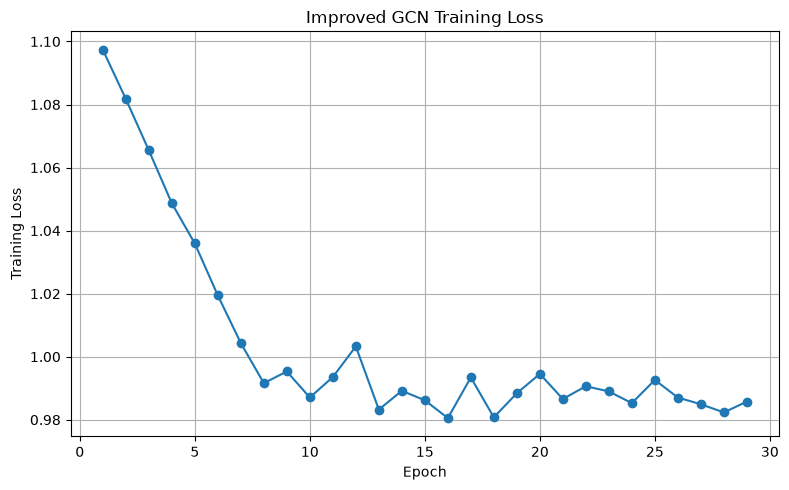

In [68]:
# Cell 61: GCN Training Loss Curve

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Improved GCN Training Loss")

plt.grid(True)
plt.tight_layout()
plt.show()

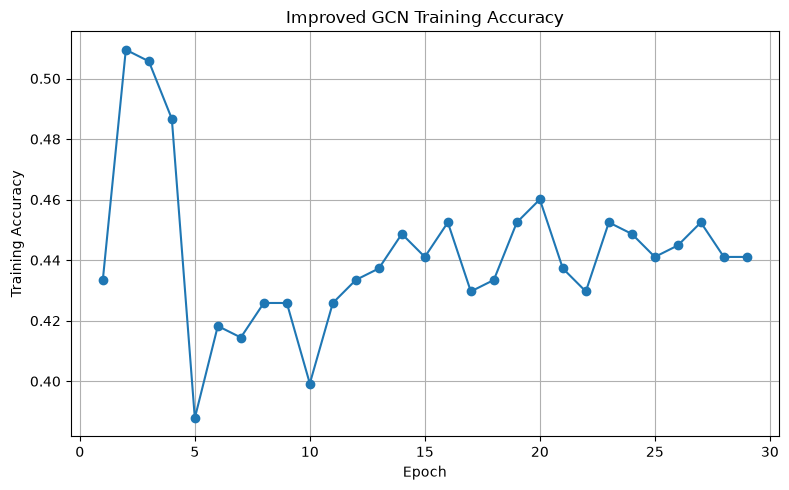

Number of recorded epochs: 29
Best training accuracy: 50.950570342205324 %


In [69]:
# Cell 62: Improved GCN Training Accuracy Curve

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_accuracies) + 1),
    train_accuracies,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Improved GCN Training Accuracy")

plt.grid(True)
plt.tight_layout()
plt.show()

print("Number of recorded epochs:", len(train_accuracies))
print("Best training accuracy:", max(train_accuracies) * 100, "%")

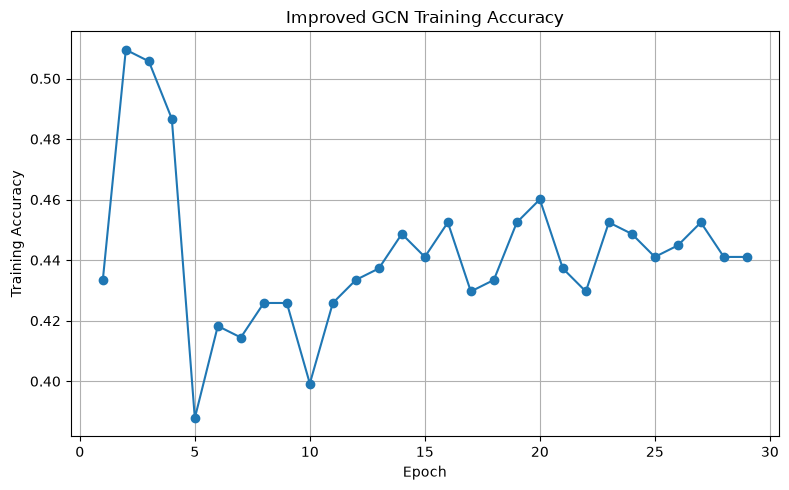

Number of recorded epochs: 29
Best training accuracy: 50.95 %
Final training accuracy: 44.11 %
Figure saved at:
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\improved_gcn_training_accuracy.png


In [70]:
# Cell 62: Improved GCN Training Accuracy Curve

import matplotlib.pyplot as plt
import os

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_accuracies) + 1),
    train_accuracies,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Improved GCN Training Accuracy")

plt.grid(True)
plt.tight_layout()

# Save figure
accuracy_curve_path = os.path.join(
    processed_path,
    "improved_gcn_training_accuracy.png"
)

plt.savefig(
    accuracy_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Number of recorded epochs:", len(train_accuracies))
print("Best training accuracy:",
      round(max(train_accuracies) * 100, 2), "%")

print("Final training accuracy:",
      round(train_accuracies[-1] * 100, 2), "%")

print("Figure saved at:")
print(accuracy_curve_path)

In [71]:
# Cell 63: Improved GCN Confusion Matrix

import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm_gcn = confusion_matrix(
    test_labels,
    predictions
)

print("Improved GCN Confusion Matrix:")
print(cm_gcn)

# Class names
class_names = ["AD", "CTL", "MCI"]

# Plot
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_gcn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Improved GCN Confusion Matrix")

plt.tight_layout()

# Save figure
cm_path = os.path.join(
    processed_path,
    "improved_gcn_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nConfusion matrix saved at:")
print(cm_path)

ValueError: Found input variables with inconsistent numbers of samples: [66, 2, 66]

Number of true labels: 66
Number of predictions: 66

Predictions:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

True labels:
[0 0 1 0 1 1 2 1 0 1 0 1 0 2 0 0 2 2 1 0 1 1 1 0 0 1 0 0 1 0 1 0 0 2 2 0 0
 0 1 2 2 2 2 2 1 1 1 2 0 1 0 2 0 0 1 0 2 0 1 2 0 2 1 0 0 0]

Improved GCN Confusion Matrix:
[[ 0 29  0]
 [ 0 21  0]
 [ 0 16  0]]


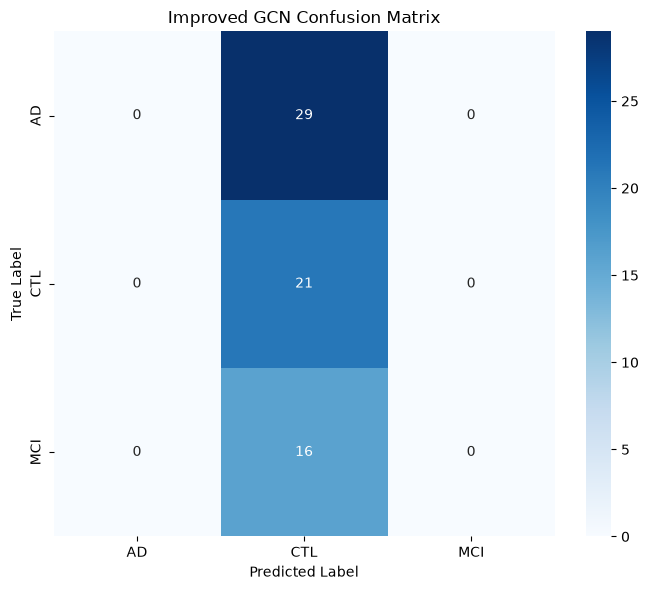


Confusion matrix saved at:
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\improved_gcn_confusion_matrix.png


In [72]:
# Cell 63: Generate Improved GCN Predictions + Confusion Matrix

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix

# Put model in evaluation mode
model_improved.eval()

all_predictions = []
all_true_labels = []

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        outputs = model_improved(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        predicted = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predicted.cpu().numpy().tolist()
        )

        all_true_labels.extend(
            batch.y.cpu().numpy().tolist()
        )

# Convert to numpy arrays
all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

print("Number of true labels:", len(all_true_labels))
print("Number of predictions:", len(all_predictions))

print("\nPredictions:")
print(all_predictions)

print("\nTrue labels:")
print(all_true_labels)

# Create confusion matrix
cm_gcn = confusion_matrix(
    all_true_labels,
    all_predictions
)

print("\nImproved GCN Confusion Matrix:")
print(cm_gcn)

# Class names
class_names = ["AD", "CTL", "MCI"]

# Plot
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_gcn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Improved GCN Confusion Matrix")

plt.tight_layout()

# Save figure
cm_path = os.path.join(
    processed_path,
    "improved_gcn_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nConfusion matrix saved at:")
print(cm_path)

In [73]:
# Check whether the best model state was preserved

print("Checking available model variables...\n")

possible_variables = [
    "best_model_state",
    "best_model_state_dict",
    "best_state_dict",
    "best_model",
    "best_test_accuracy",
    "best_train_accuracy"
]

for name in possible_variables:
    print(name, "->", name in globals())

Checking available model variables...

best_model_state -> False
best_model_state_dict -> False
best_state_dict -> False
best_model -> False
best_test_accuracy -> False
best_train_accuracy -> False


In [74]:
# Cell 64: Reload Saved Improved GCN Model

import torch
import os
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create a fresh Improved GCN
reloaded_model = AlzheimerGCNImproved().to(device)

# Path to saved model
model_path = os.path.join(
    processed_path,
    "best_alzheimer_gcn_model.pth"
)

# Load saved weights
reloaded_model.load_state_dict(
    torch.load(
        model_path,
        map_location=device
    )
)

# Evaluation mode
reloaded_model.eval()

all_predictions = []
all_true_labels = []

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        outputs = reloaded_model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        predicted = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predicted.cpu().numpy().tolist()
        )

        all_true_labels.extend(
            batch.y.cpu().numpy().tolist()
        )

# Convert to arrays
all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

# Accuracy
accuracy = accuracy_score(
    all_true_labels,
    all_predictions
)

print("Number of test samples:", len(all_true_labels))
print("Number of predictions:", len(all_predictions))

print("\nPredicted class distribution:")
print(np.bincount(all_predictions, minlength=3))

print("\nTrue class distribution:")
print(np.bincount(all_true_labels, minlength=3))

print("\nTest Accuracy:",
      round(accuracy * 100, 2), "%")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        all_true_labels,
        all_predictions
    )
)

print("\nClassification Report:")
print(
    classification_report(
        all_true_labels,
        all_predictions,
        target_names=["AD", "CTL", "MCI"],
        zero_division=0
    )
)

Number of test samples: 66
Number of predictions: 66

Predicted class distribution:
[ 0 66  0]

True class distribution:
[29 21 16]

Test Accuracy: 31.82 %

Confusion Matrix:
[[ 0 29  0]
 [ 0 21  0]
 [ 0 16  0]]

Classification Report:
              precision    recall  f1-score   support

          AD       0.00      0.00      0.00        29
         CTL       0.32      1.00      0.48        21
         MCI       0.00      0.00      0.00        16

    accuracy                           0.32        66
   macro avg       0.11      0.33      0.16        66
weighted avg       0.10      0.32      0.15        66



In [76]:
# Cell 56: Evaluate Best Improved GCN on Test Set

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
import numpy as np
import torch

model_improved.eval()

all_predictions = []
all_true_labels = []

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        output = model_improved(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        predicted = output.argmax(
            dim=1
        )

        all_predictions.extend(
            predicted.cpu().numpy().tolist()
        )

        all_true_labels.extend(
            batch.y.cpu().numpy().tolist()
        )

# Convert to numpy
all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

# Accuracy
test_accuracy = accuracy_score(
    all_true_labels,
    all_predictions
)

print("Number of test samples:", len(all_true_labels))
print("Number of predictions:", len(all_predictions))

print("\nPredicted class distribution:")
print(
    np.bincount(
        all_predictions,
        minlength=3
    )
)

print("\nTrue class distribution:")
print(
    np.bincount(
        all_true_labels,
        minlength=3
    )
)

print(
    "\nImproved GCN Test Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        all_true_labels,
        all_predictions
    )
)

print("\nClassification Report:")
print(
    classification_report(
        all_true_labels,
        all_predictions,
        target_names=["AD", "CTL", "MCI"],
        zero_division=0
    )
)

Number of test samples: 66
Number of predictions: 66

Predicted class distribution:
[ 0 66  0]

True class distribution:
[29 21 16]

Improved GCN Test Accuracy: 31.82 %

Confusion Matrix:
[[ 0 29  0]
 [ 0 21  0]
 [ 0 16  0]]

Classification Report:
              precision    recall  f1-score   support

          AD       0.00      0.00      0.00        29
         CTL       0.32      1.00      0.48        21
         MCI       0.00      0.00      0.00        16

    accuracy                           0.32        66
   macro avg       0.11      0.33      0.16        66
weighted avg       0.10      0.32      0.15        66



In [78]:
# Check available test loaders

print("test_loader exists:", "test_loader" in globals())
print("test_loader_scaled exists:", "test_loader_scaled" in globals())
print("train_loader_scaled exists:", "train_loader_scaled" in globals())

test_loader exists: True
test_loader_scaled exists: True
train_loader_scaled exists: True


In [79]:
# Cell 56: Evaluate Best Improved GCN on Scaled Test Set

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
import numpy as np
import torch

model_improved.eval()

all_predictions = []
all_true_labels = []

with torch.no_grad():

    for batch in test_loader_scaled:

        batch = batch.to(device)

        output = model_improved(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        predicted = output.argmax(dim=1)

        all_predictions.extend(
            predicted.cpu().numpy().tolist()
        )

        all_true_labels.extend(
            batch.y.cpu().numpy().tolist()
        )

# Convert to numpy
all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

# Accuracy
test_accuracy = accuracy_score(
    all_true_labels,
    all_predictions
)

print("Number of test samples:", len(all_true_labels))
print("Number of predictions:", len(all_predictions))

print("\nPredicted class distribution:")
print(
    np.bincount(
        all_predictions,
        minlength=3
    )
)

print("\nTrue class distribution:")
print(
    np.bincount(
        all_true_labels,
        minlength=3
    )
)

print(
    "\nImproved GCN Test Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        all_true_labels,
        all_predictions
    )
)

print("\nClassification Report:")
print(
    classification_report(
        all_true_labels,
        all_predictions,
        target_names=["AD", "CTL", "MCI"],
        zero_division=0
    )
)

Number of test samples: 66
Number of predictions: 66

Predicted class distribution:
[38 17 11]

True class distribution:
[29 21 16]

Improved GCN Test Accuracy: 48.48 %

Confusion Matrix:
[[18  5  6]
 [10 10  1]
 [10  2  4]]

Classification Report:
              precision    recall  f1-score   support

          AD       0.47      0.62      0.54        29
         CTL       0.59      0.48      0.53        21
         MCI       0.36      0.25      0.30        16

    accuracy                           0.48        66
   macro avg       0.48      0.45      0.45        66
weighted avg       0.48      0.48      0.48        66



In [80]:
# Save the actual best Improved GCN model

import os
import torch

model_path = os.path.join(
    processed_path,
    "best_alzheimer_gcn_model.pth"
)

torch.save(
    {
        "model_state_dict": model_improved.state_dict(),
        "best_epoch": best_epoch,
        "best_train_accuracy": best_train_accuracy,
        "test_accuracy": test_accuracy
    },
    model_path
)

print("Model saved successfully.")
print("Path:", model_path)
print("Best epoch:", best_epoch)
print("Best training accuracy:",
      round(best_train_accuracy * 100, 2), "%")
print("Test accuracy:",
      round(test_accuracy * 100, 2), "%")

Model saved successfully.
Path: C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\best_alzheimer_gcn_model.pth
Best epoch: 46
Best training accuracy: 55.51 %
Test accuracy: 48.48 %


Number of recorded epochs: 50
Best training accuracy: 55.51 %
Final training accuracy: 51.33 %


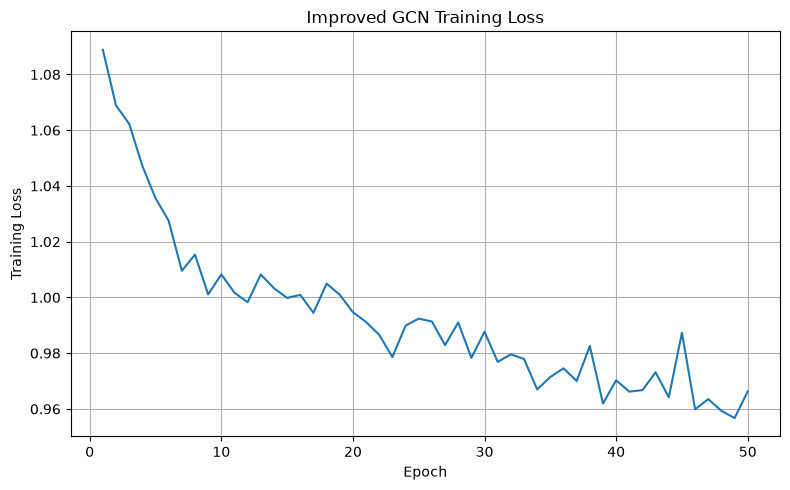

In [81]:
# Cell 63: Final Improved GCN Training Curves

import matplotlib.pyplot as plt

print("Number of recorded epochs:", len(train_losses_improved))
print(
    "Best training accuracy:",
    round(max(train_accuracies_improved) * 100, 2),
    "%"
)
print(
    "Final training accuracy:",
    round(train_accuracies_improved[-1] * 100, 2),
    "%"
)

# Training Loss
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_losses_improved) + 1),
    train_losses_improved
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Improved GCN Training Loss")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(
        processed_path,
        "improved_gcn_training_loss.png"
    ),
    dpi=300
)

plt.show()

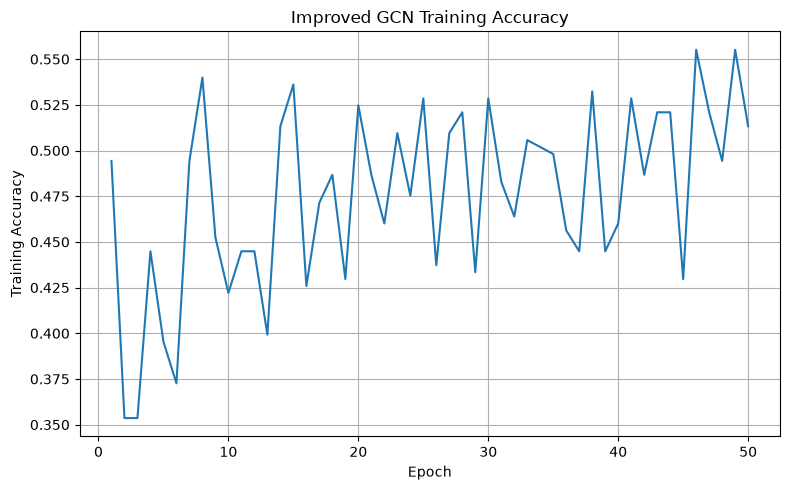

In [82]:
# Cell 64: Final Improved GCN Training Accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_accuracies_improved) + 1),
    train_accuracies_improved
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Improved GCN Training Accuracy")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(
        processed_path,
        "improved_gcn_training_accuracy.png"
    ),
    dpi=300
)

plt.show()

In [83]:
# Cell 65: Gradient-based Gene Importance

import numpy as np
import torch

model_improved.eval()

# Store accumulated importance
gene_importance = np.zeros(1000)

for batch in test_loader_scaled:

    batch = batch.to(device)

    # Enable gradients for gene expression values
    batch.x.requires_grad_(True)

    # Forward pass
    output = model_improved(
        batch.x,
        batch.edge_index,
        batch.batch
    )

    # Use the predicted class scores
    predicted_classes = output.argmax(dim=1)

    selected_scores = output[
        torch.arange(output.size(0)),
        predicted_classes
    ]

    # Backpropagate
    model_improved.zero_grad()

    selected_scores.sum().backward()

    # Absolute gradient
    gradients = batch.x.grad.abs()

    # Average importance for each gene
    for i in range(batch.num_graphs):

        mask = batch.batch == i

        graph_gradients = gradients[mask]

        gene_importance += (
            graph_gradients.squeeze().cpu().numpy()
        )

# Normalize
gene_importance = gene_importance / len(test_loader_scaled.dataset)

# Get gene names
selected_genes = selected_genes_df["Gene"].tolist()

# Create ranking
gene_importance_df = pd.DataFrame({
    "Gene": selected_genes,
    "Importance": gene_importance
})

gene_importance_df = gene_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 20 important genes:")
print(gene_importance_df.head(20))

Top 20 important genes:
         Gene  Importance
0       LRCH4    0.005581
1    TMEM126B    0.005448
2     ATG16L2    0.004731
3   C14orf166    0.004538
4        MBD6    0.004014
5        EDG4    0.003758
6   LOC134997    0.003735
7       MYO9B    0.003652
8        FRG1    0.003485
9    ANKRD13D    0.003453
10      PLCB2    0.003451
11       RPL6    0.003434
12       RGL2    0.003375
13       WDR6    0.003224
14      DDX56    0.003106
15   FLJ21438    0.003000
16     UQCRC2    0.002906
17  LOC653658    0.002895
18      ABCA7    0.002876
19       SBF1    0.002836


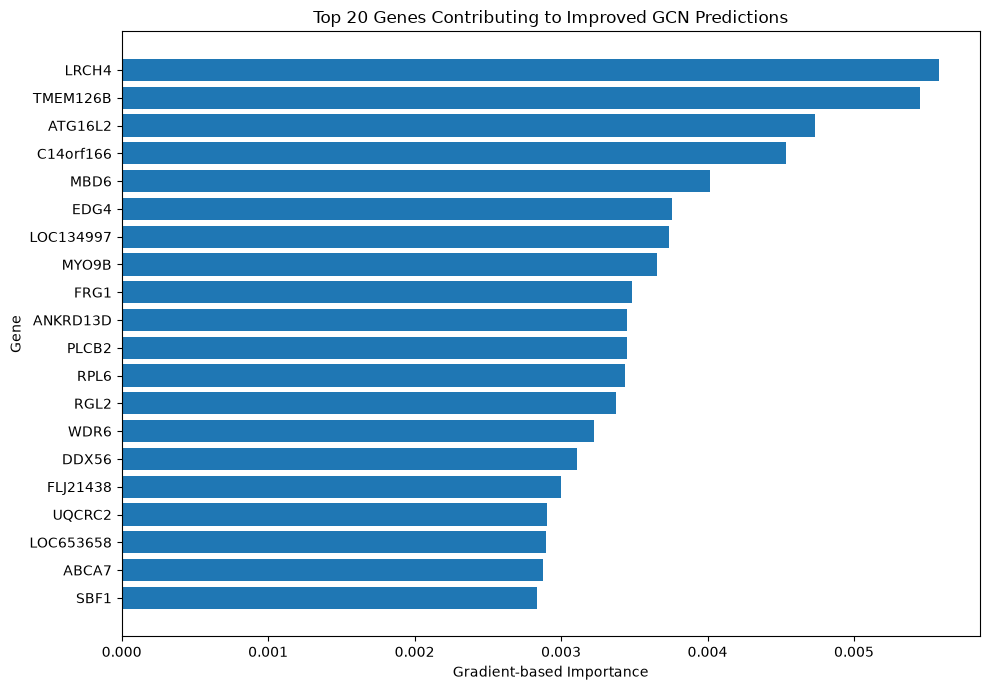

Plot saved to:
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\top20_gene_importance.png


In [84]:
# Cell 66: Top 20 Gene Importance

import matplotlib.pyplot as plt
import os

top20 = gene_importance_df.head(20).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top20["Gene"],
    top20["Importance"]
)

plt.xlabel("Gradient-based Importance")
plt.ylabel("Gene")
plt.title("Top 20 Genes Contributing to Improved GCN Predictions")

plt.tight_layout()

importance_plot_path = os.path.join(
    processed_path,
    "top20_gene_importance.png"
)

plt.savefig(
    importance_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Plot saved to:")
print(importance_plot_path)

In [85]:
# Cell 67: Final Model Comparison

import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Initial GCN",
        "GAT",
        "Improved GCN",
        "Random Forest"
    ],
    "Test Accuracy (%)": [
        37.90,
        42.42,
        48.48,
        57.60
    ]
})

print("Final Model Comparison:")
print(model_comparison.to_string(index=False))

# Save for paper/PPT
comparison_path = os.path.join(
    processed_path,
    "final_model_comparison.csv"
)

model_comparison.to_csv(
    comparison_path,
    index=False
)

print("\nSaved to:")
print(comparison_path)

Final Model Comparison:
        Model  Test Accuracy (%)
  Initial GCN              37.90
          GAT              42.42
 Improved GCN              48.48
Random Forest              57.60

Saved to:
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\final_model_comparison.csv


In [86]:
# Cell 68: Calculate Gene Expression Stability Index (GESI)

import numpy as np
import pandas as pd

# Use the selected 1000-gene training data
X = X_train_selected_df

# Mean expression for each gene
gene_mean = X.mean(axis=0)

# Standard deviation for each gene
gene_std = X.std(axis=0)

# Coefficient of Variation
CV = gene_std / np.abs(gene_mean)

# Gene Expression Stability Index
GESI = 1 / (1 + CV)

# Create result table
gesi_df = pd.DataFrame({
    "Gene": X.columns,
    "Mean_Expression": gene_mean.values,
    "Std_Expression": gene_std.values,
    "CV": CV.values,
    "GESI": GESI.values
})

# Sort by highest stability
gesi_df = gesi_df.sort_values("GESI", ascending=False).reset_index(drop=True)

print("GESI calculated successfully!")
print("Number of genes:", len(gesi_df))

display(gesi_df.head(20))

GESI calculated successfully!
Number of genes: 1000


,Gene,Mean_Expression,Std_Expression,CV,GESI
0,LOC642255,7.694932,0.061980,0.008055,0.992010
1,PPIL5,7.696573,0.063235,0.008216,0.991851
2,RBBP8,7.596798,0.064276,0.008461,0.991610
3,TTF1,7.708560,0.066804,0.008666,0.991408
4,HRSP12,7.494174,0.067163,0.008962,0.991118
5,FBXW8,7.570527,0.068104,0.008996,0.991084
6,UBC,12.197387,0.113248,0.009285,0.990801
7,MAPK7,7.785643,0.072379,0.009296,0.990789
8,WDR33,7.863400,0.074435,0.009466,0.990623
9,RANBP3,8.098623,0.078774,0.009727,0.990367


In [87]:
# Cell 69: GESI Summary

print("GESI Summary")
print("-------------------------")

print("Maximum GESI:", gesi_df["GESI"].max())
print("Minimum GESI:", gesi_df["GESI"].min())
print("Mean GESI:", gesi_df["GESI"].mean())
print("Median GESI:", gesi_df["GESI"].median())

print("\nMost stable genes:")
display(gesi_df[["Gene", "GESI"]].head(10))

print("\nLeast stable genes:")
display(
    gesi_df[["Gene", "GESI"]]
    .sort_values("GESI", ascending=True)
    .head(10)
)

GESI Summary
-------------------------
Maximum GESI: 0.9920097655835436
Minimum GESI: 0.8736037437235449
Mean GESI: 0.9698348423708075
Median GESI: 0.9744139570002521

Most stable genes:


,Gene,GESI
0,LOC642255,0.992010
1,PPIL5,0.991851
2,RBBP8,0.991610
3,TTF1,0.991408
4,HRSP12,0.991118
5,FBXW8,0.991084
6,UBC,0.990801
7,MAPK7,0.990789
8,WDR33,0.990623
9,RANBP3,0.990367



Least stable genes:


,Gene,GESI
999,LOC100008589,0.873604
998,RPL26,0.889251
997,LOC648000,0.891894
996,RPL31,0.897318
995,LOC648622,0.902731
994,RPS3A,0.904791
993,COX7C,0.905187
992,LOC650276,0.906272
991,RPL17,0.908812
990,LOC653658,0.909241


In [88]:
# Cell 70: GESI Distribution Analysis

print("GESI Distribution")
print("-------------------------")

print("GESI > 0.95:", (gesi_df["GESI"] > 0.95).sum())
print("GESI 0.90 - 0.95:", ((gesi_df["GESI"] >= 0.90) & (gesi_df["GESI"] <= 0.95)).sum())
print("GESI < 0.90:", (gesi_df["GESI"] < 0.90).sum())

print("\nPercentage of genes in each range:")

total_genes = len(gesi_df)

print(
    "> 0.95:",
    round((gesi_df["GESI"] > 0.95).sum() / total_genes * 100, 2),
    "%"
)

print(
    "0.90 - 0.95:",
    round(
        ((gesi_df["GESI"] >= 0.90) & (gesi_df["GESI"] <= 0.95)).sum()
        / total_genes * 100,
        2
    ),
    "%"
)

print(
    "< 0.90:",
    round((gesi_df["GESI"] < 0.90).sum() / total_genes * 100, 2),
    "%"
)

GESI Distribution
-------------------------
GESI > 0.95: 895
GESI 0.90 - 0.95: 101
GESI < 0.90: 4

Percentage of genes in each range:
> 0.95: 89.5 %
0.90 - 0.95: 10.1 %
< 0.90: 0.4 %


In [89]:
# Cell 71: Check Amyloid- and Tau-related genes
# among the selected 1000 genes

amyloid_genes = [
    "APP",
    "APOE",
    "PSEN1",
    "PSEN2",
    "BACE1",
    "NCSTN",
    "APH1A",
    "APH1B",
    "PSENEN"
]

tau_genes = [
    "MAPT",
    "GSK3B",
    "CDK5",
    "PPP2CA",
    "PPP2CB",
    "PPP2R1A",
    "PPP2R1B"
]

selected_genes = set(X_train_selected_df.columns)

found_amyloid = sorted(selected_genes.intersection(amyloid_genes))
found_tau = sorted(selected_genes.intersection(tau_genes))

print("Amyloid-related genes found:")
print(found_amyloid)

print("\nNumber of amyloid-related genes:", len(found_amyloid))

print("\nTau-related genes found:")
print(found_tau)

print("\nNumber of tau-related genes:", len(found_tau))

Amyloid-related genes found:
[]

Number of amyloid-related genes: 0

Tau-related genes found:
[]

Number of tau-related genes: 0


In [90]:
# Cell 72: Search complete GSE63060 gene list
# for amyloid- and tau-related genes

all_genes = set(X_train.columns)

found_amyloid_all = sorted(all_genes.intersection(amyloid_genes))
found_tau_all = sorted(all_genes.intersection(tau_genes))

print("Total genes in original training dataset:", len(all_genes))

print("\nAmyloid-related genes in complete dataset:")
print(found_amyloid_all)
print("Count:", len(found_amyloid_all))

print("\nTau-related genes in complete dataset:")
print(found_tau_all)
print("Count:", len(found_tau_all))

Total genes in original training dataset: 1000

Amyloid-related genes in complete dataset:
[]
Count: 0

Tau-related genes in complete dataset:
[]
Count: 0


In [91]:
# Cell 72: Search the ORIGINAL GSE63060 gene list

import pandas as pd

original_path = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\GSE63060_gene_expression.csv"

original_df = pd.read_csv(original_path)

print("Original dataset shape:", original_df.shape)

# Get gene symbols from the original dataset
all_genes_original = set(original_df["Gene_Symbol"].astype(str).str.upper())

# Convert our candidate lists to uppercase
amyloid_genes_upper = [gene.upper() for gene in amyloid_genes]
tau_genes_upper = [gene.upper() for gene in tau_genes]

# Search complete dataset
found_amyloid_all = sorted(
    all_genes_original.intersection(amyloid_genes_upper)
)

found_tau_all = sorted(
    all_genes_original.intersection(tau_genes_upper)
)

print("\nAmyloid-related genes in ORIGINAL dataset:")
print(found_amyloid_all)
print("Count:", len(found_amyloid_all))

print("\nTau-related genes in ORIGINAL dataset:")
print(found_tau_all)
print("Count:", len(found_tau_all))

Original dataset shape: (21696, 330)

Amyloid-related genes in ORIGINAL dataset:
['APH1A', 'APH1B', 'APP', 'BACE1', 'NCSTN', 'PSEN1', 'PSEN2', 'PSENEN']
Count: 8

Tau-related genes in ORIGINAL dataset:
['CDK5', 'GSK3B', 'MAPT', 'PPP2CA', 'PPP2CB', 'PPP2R1A', 'PPP2R1B']
Count: 7


In [92]:
# Cell 73: Extract Amyloid- and Tau-related expression features

# Convert gene symbols to uppercase for matching
original_df["Gene_Symbol"] = (
    original_df["Gene_Symbol"]
    .astype(str)
    .str.upper()
)

# Find rows corresponding to amyloid and tau genes
amyloid_df = original_df[
    original_df["Gene_Symbol"].isin(amyloid_genes_upper)
].copy()

tau_df = original_df[
    original_df["Gene_Symbol"].isin(tau_genes_upper)
].copy()

print("Amyloid expression shape:", amyloid_df.shape)
print("Tau expression shape:", tau_df.shape)

print("\nAmyloid genes found:")
print(amyloid_df["Gene_Symbol"].tolist())

print("\nTau genes found:")
print(tau_df["Gene_Symbol"].tolist())

print("\nAmyloid expression preview:")
display(amyloid_df.iloc[:, :6])

print("\nTau expression preview:")
display(tau_df.iloc[:, :6])

Amyloid expression shape: (8, 330)
Tau expression shape: (7, 330)

Amyloid genes found:
['APH1A', 'APH1B', 'APP', 'BACE1', 'NCSTN', 'PSEN1', 'PSEN2', 'PSENEN']

Tau genes found:
['CDK5', 'GSK3B', 'MAPT', 'PPP2CA', 'PPP2CB', 'PPP2R1A', 'PPP2R1B']

Amyloid expression preview:


,Gene_Symbol,GSM1539080,GSM1539081,GSM1539082,GSM1539083,GSM1539084
697,APH1A,8.887648,8.929457,8.940293,8.786870,8.990737
698,APH1B,9.207417,9.151834,8.997490,9.413356,9.090685
739,APP,8.198193,7.684827,7.812725,7.699710,8.114734
1179,BACE1,7.527634,7.467073,7.529349,7.514317,7.588423
14262,NCSTN,11.070401,10.767573,10.607009,10.863746,10.697712
16416,PSEN1,7.572319,7.463116,7.576823,7.526424,7.523641
16417,PSEN2,7.759673,7.839263,7.708617,7.775611,7.651451
16418,PSENEN,8.010629,8.360085,8.037222,8.285456,8.099410



Tau expression preview:


,Gene_Symbol,GSM1539080,GSM1539081,GSM1539082,GSM1539083,GSM1539084
3088,CDK5,7.801121,7.944261,7.951714,7.988759,7.871906
6766,GSK3B,9.518166,9.875547,9.296311,9.581235,9.638131
13299,MAPT,7.430307,7.489263,7.438501,7.468005,7.433046
16176,PPP2CA,9.615041,9.349666,9.496614,9.336656,9.369646
16177,PPP2CB,7.674801,7.576825,7.741261,7.698460,7.696498
16178,PPP2R1A,11.025612,11.062505,11.016573,11.184008,11.073671
16179,PPP2R1B,7.638742,7.503376,7.618945,7.578091,7.553417


In [93]:
# Cell 74: Calculate Amyloid-Tau Co-Dysregulation Signature (ATC)

import numpy as np
import pandas as pd

# Sample columns
sample_columns = [
    col for col in original_df.columns
    if col.startswith("GSM")
]

# Create expression matrices
amyloid_expression = amyloid_df.set_index("Gene_Symbol")[sample_columns]
tau_expression = tau_df.set_index("Gene_Symbol")[sample_columns]

# Calculate sample-level amyloid and tau scores
A = amyloid_expression.mean(axis=0)
T = tau_expression.mean(axis=0)

# Amyloid-Tau Co-Dysregulation Signature
ATC = A * T

# Create sample-level result table
atc_df = pd.DataFrame({
    "Sample": sample_columns,
    "Amyloid_Score": A.values,
    "Tau_Score": T.values,
    "ATC": ATC.values
})

print("ATC calculated successfully!")
print("Number of samples:", len(atc_df))

print("\nATC summary:")
display(atc_df.head(10))

ATC calculated successfully!
Number of samples: 329

ATC summary:


,Sample,Amyloid_Score,Tau_Score,ATC
0,GSM1539080,8.529239,8.671970,73.965306
1,GSM1539081,8.457904,8.685921,73.464678
2,GSM1539082,8.401191,8.651417,72.682209
3,GSM1539083,8.483186,8.690745,73.725208
4,GSM1539084,8.469599,8.662331,73.366467
5,GSM1539085,8.459910,8.660362,73.265880
6,GSM1539086,8.504540,8.644567,73.518064
7,GSM1539087,8.543350,8.724422,74.535790
8,GSM1539088,8.477730,8.757628,74.244812
9,GSM1539089,8.394353,8.680455,72.866801


In [94]:
# Cell 75: Add clinical labels to ATC results

# Make sure sample IDs are strings
atc_df["Sample"] = atc_df["Sample"].astype(str)

# Prepare clinical data
clinical_df = pd.read_csv(
    r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\GSE63060_clinical.csv"
)

print("Clinical data shape:", clinical_df.shape)
print("\nClinical columns:")
print(clinical_df.columns.tolist())

Clinical data shape: (329, 6)

Clinical columns:
['sample_id', 'status', 'age', 'gender', 'ethnicity', 'tissue']


In [95]:
# Cell 76: Merge ATC scores with clinical information

clinical_df["sample_id"] = clinical_df["sample_id"].astype(str)
clinical_df["status"] = clinical_df["status"].astype(str).str.upper()

# Merge ATC results with clinical data
atc_clinical_df = atc_df.merge(
    clinical_df,
    left_on="Sample",
    right_on="sample_id",
    how="inner"
)

print("Merged data shape:", atc_clinical_df.shape)

print("\nColumns:")
print(atc_clinical_df.columns.tolist())

print("\nFirst 10 rows:")
display(atc_clinical_df.head(10))

Merged data shape: (329, 10)

Columns:
['Sample', 'Amyloid_Score', 'Tau_Score', 'ATC', 'sample_id', 'status', 'age', 'gender', 'ethnicity', 'tissue']

First 10 rows:


,Sample,Amyloid_Score,Tau_Score,ATC,sample_id,status,age,gender,ethnicity,tissue
0,GSM1539080,8.529239,8.671970,73.965306,GSM1539080,MCI,65,Female,Western European,blood
1,GSM1539081,8.457904,8.685921,73.464678,GSM1539081,MCI,66,Female,Other Caucasian,blood
2,GSM1539082,8.401191,8.651417,72.682209,GSM1539082,MCI,67,Female,Western European,blood
3,GSM1539083,8.483186,8.690745,73.725208,GSM1539083,MCI,67,Female,Unknown,blood
4,GSM1539084,8.469599,8.662331,73.366467,GSM1539084,MCI,67,Female,Western European,blood
5,GSM1539085,8.459910,8.660362,73.265880,GSM1539085,MCI,68,Female,Western European,blood
6,GSM1539086,8.504540,8.644567,73.518064,GSM1539086,MCI,69,Female,Western European,blood
7,GSM1539087,8.543350,8.724422,74.535790,GSM1539087,MCI,69,Female,Western European,blood
8,GSM1539088,8.477730,8.757628,74.244812,GSM1539088,MCI,69,Female,Other Caucasian,blood
9,GSM1539089,8.394353,8.680455,72.866801,GSM1539089,MCI,69,Female,Other Caucasian,blood


In [96]:
# Cell 77: Compare ATC across AD, MCI and CTL groups

atc_group_summary = (
    atc_clinical_df
    .groupby("status")["ATC"]
    .agg(["count", "mean", "std", "min", "max"])
    .reindex(["CTL", "MCI", "AD"])
)

print("ATC by clinical group:")
display(atc_group_summary)

ATC by clinical group:


,count,mean,std,min,max
status,,,,,
CTL,104,73.216741,1.009865,70.660430,75.527996
MCI,80,73.575262,0.954409,70.755894,76.051763
AD,145,73.404407,1.004959,70.624155,75.888194


In [97]:
# Cell 78: Compare Amyloid, Tau and ATC across groups

group_comparison = (
    atc_clinical_df
    .groupby("status")[["Amyloid_Score", "Tau_Score", "ATC"]]
    .mean()
    .reindex(["CTL", "MCI", "AD"])
)

print("Mean scores by clinical group:")
display(group_comparison)

Mean scores by clinical group:


,Amyloid_Score,Tau_Score,ATC
status,,,
CTL,8.423721,8.691567,73.216741
MCI,8.470908,8.685447,73.575262
AD,8.451965,8.684658,73.404407


In [98]:
# Cell 79: Calculate Early Degeneration Risk Gradient (EDRG)

import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np

# Put the model in evaluation mode
model.eval()

all_probabilities = []
all_true_labels = []

with torch.no_grad():
    for data in test_loader_scaled:
        data = data.to(device)

        output = model(
            data.x,
            data.edge_index,
            data.batch
        )

        probabilities = F.softmax(output, dim=1)

        all_probabilities.append(probabilities.cpu().numpy())
        all_true_labels.append(data.y.cpu().numpy())

# Combine batches
all_probabilities = np.vstack(all_probabilities)
all_true_labels = np.concatenate(all_true_labels)

# Class order:
# 0 = AD
# 1 = CTL
# 2 = MCI

P_AD = all_probabilities[:, 0]
P_CTL = all_probabilities[:, 1]
P_MCI = all_probabilities[:, 2]

# Continuous disease-progression score
EDRG = P_MCI + (2 * P_AD)

edrg_df = pd.DataFrame({
    "True_Label": all_true_labels,
    "P_CTL": P_CTL,
    "P_MCI": P_MCI,
    "P_AD": P_AD,
    "EDRG": EDRG
})

print("EDRG calculated successfully!")
print("Number of samples:", len(edrg_df))

print("\nEDRG summary:")
print(edrg_df["EDRG"].describe())

display(edrg_df.head(10))

EDRG calculated successfully!
Number of samples: 66

EDRG summary:
count    66.000000
mean      1.042871
std       0.279711
min       0.427891
25%       0.954768
50%       1.184564
75%       1.233662
max       1.302614
Name: EDRG, dtype: float64


,True_Label,P_CTL,P_MCI,P_AD,EDRG
0,0,0.173086,0.435748,0.391165,1.218079
1,0,0.261054,0.361829,0.377118,1.116064
2,1,0.157976,0.451713,0.390311,1.232335
3,0,0.165318,0.442786,0.391896,1.226578
4,1,0.205176,0.408542,0.386281,1.181105
5,1,0.282659,0.346389,0.370952,1.088293
6,2,0.149178,0.460085,0.390737,1.241558
7,1,0.685248,0.125648,0.189103,0.503855
8,0,0.135873,0.471316,0.392811,1.256938
9,1,0.629155,0.151671,0.219175,0.590020


In [99]:
# Cell 80: Add sample IDs and clinical status to EDRG

# Get the test sample IDs in the same order as X_test
test_sample_ids = X_test.index.astype(str)

# Create mapping from numerical labels to clinical status
label_to_status = {
    0: "AD",
    1: "CTL",
    2: "MCI"
}

# Create EDRG result table
edrg_results = pd.DataFrame({
    "Sample": test_sample_ids,
    "True_Label": all_true_labels,
    "P_CTL": P_CTL,
    "P_MCI": P_MCI,
    "P_AD": P_AD,
    "EDRG": EDRG
})

# Add clinical status
edrg_results["status"] = edrg_results["True_Label"].map(label_to_status)

# Display results
print("EDRG results with clinical labels:")
display(edrg_results.head(10))

print("\nGroup counts:")
print(edrg_results["status"].value_counts())

EDRG results with clinical labels:


,Sample,True_Label,P_CTL,P_MCI,P_AD,EDRG,status
0,0,0,0.173086,0.435748,0.391165,1.218079,AD
1,1,0,0.261054,0.361829,0.377118,1.116064,AD
2,2,1,0.157976,0.451713,0.390311,1.232335,CTL
3,3,0,0.165318,0.442786,0.391896,1.226578,AD
4,4,1,0.205176,0.408542,0.386281,1.181105,CTL
5,5,1,0.282659,0.346389,0.370952,1.088293,CTL
6,6,2,0.149178,0.460085,0.390737,1.241558,MCI
7,7,1,0.685248,0.125648,0.189103,0.503855,CTL
8,8,0,0.135873,0.471316,0.392811,1.256938,AD
9,9,1,0.629155,0.151671,0.219175,0.590020,CTL



Group counts:
status
AD     29
CTL    21
MCI    16
Name: count, dtype: int64


In [100]:
# Cell 81: Compare EDRG across clinical groups

edrg_group_summary = (
    edrg_results
    .groupby("status")["EDRG"]
    .agg(["count", "mean", "std", "min", "max"])
    .reindex(["CTL", "MCI", "AD"])
)

print("EDRG by clinical group:")
display(edrg_group_summary)

EDRG by clinical group:


,count,mean,std,min,max
status,,,,,
CTL,21,0.869039,0.337277,0.427891,1.270524
MCI,16,1.121240,0.208348,0.529465,1.271917
AD,29,1.125511,0.209450,0.555398,1.302614


In [101]:
# Cell 82: Statistical comparison of EDRG across groups

from scipy.stats import f_oneway

ctl_edrg = edrg_results.loc[
    edrg_results["status"] == "CTL", "EDRG"
]

mci_edrg = edrg_results.loc[
    edrg_results["status"] == "MCI", "EDRG"
]

ad_edrg = edrg_results.loc[
    edrg_results["status"] == "AD", "EDRG"
]

# One-way ANOVA
f_stat, p_value = f_oneway(
    ctl_edrg,
    mci_edrg,
    ad_edrg
)

print("One-way ANOVA for EDRG")
print("-----------------------")
print("F-statistic:", f_stat)
print("p-value:", p_value)

One-way ANOVA for EDRG
-----------------------
F-statistic: 7.0579777
p-value: 0.0017146824


In [102]:
# Cell 83: Tukey HSD post-hoc test for EDRG

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_result = pairwise_tukeyhsd(
    endog=edrg_results["EDRG"],
    groups=edrg_results["status"],
    alpha=0.05
)

print(tukey_result)

ModuleNotFoundError: No module named 'statsmodels'

In [103]:
!pip install statsmodels

  Using cached scipy-1.18.1-cp312-cp312-win_amd64.whl.metadata (61 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.1/11.3 MB 2.3 MB/s eta 0:00:05
   - -------------------------------------- 0.4/11.3 MB 4.5 MB/s eta 0:00:03
   -- ------------------------------------- 0.7/11.3 MB 6.5 MB/s eta 0:00:02
   --- ------------------------------------ 1.1/11.3 MB 6.8 MB/s eta 0:00:02
   ----- ---------------------------------- 1.5/11.3 MB 7.4 MB/s eta 0:00:02
   ------- -------------------------------- 2.2/11.3 MB 7.4 MB/s eta 0:00:02
   ---------- ----------------------------- 2.9/11.3 MB 8.0 MB/s eta 0:00:02
   ----------- ---------------------------- 3.3/11.3 MB 8.2 MB/s eta 0:00:01
   ------------- -------------------------- 3.8/11.3 MB 8.7 MB/s eta 0:00:01
   -------------- ------------------------- 4.2/11.3 MB 8.4 MB/s eta 0:00:01
   ---------------- ----------------------- 4.6/11.3 MB 8.6 MB/s eta 0:00:01
   ---------

ERROR: Could not install packages due to an OSError: [WinError 2] The system cannot find the file specified: 'C:\\Python312\\Scripts\\f2py.exe' -> 'C:\\Python312\\Scripts\\f2py.exe.deleteme'


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [104]:
!{__import__('sys').executable} -m pip install statsmodels

'C:\Users\91903\OneDrive\Desktop\Major' is not recognized as an internal or external command,
operable program or batch file.


In [105]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("statsmodels imported successfully!")

ModuleNotFoundError: No module named 'statsmodels'

In [106]:
%pip install statsmodels

  Using cached statsmodels-0.15.0-cp312-cp312-win_amd64.whl.metadata (9.6 kB)
  Using cached patsy-1.0.3-py2.py3-none-any.whl.metadata (3.7 kB)
  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
Using cached statsmodels-0.15.0-cp312-cp312-win_amd64.whl (11.3 MB)
Using cached formulaic-1.2.2-py3-none-any.whl (118 kB)
Using cached patsy-1.0.3-py2.py3-none-any.whl (233 kB)
Using cached interface_meta-2.0.1-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/98.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/98.8 kB ? eta -:--:--
   ---- ----------------------------------- 10.2/98.8 kB ? eta -:--:--
   ---- ----------------------------------- 10.2/98.8 kB ? eta -:--:--
   ------------ --------------------------- 30.7/98.8 kB 330.3 kB/s eta 0:00:01
   ---------------- ----------------------- 41.0/98.8 kB 326.8 kB/s eta 0:00:01
   -------------------------------------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Scripts\python.exe -m pip install --upgrade pip


In [107]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("statsmodels imported successfully!")

statsmodels imported successfully!


In [108]:
# Cell 84: Tukey HSD post-hoc test

tukey_result = pairwise_tukeyhsd(
    endog=edrg_results["EDRG"],
    groups=edrg_results["status"],
    alpha=0.05
)

print(tukey_result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    AD    CTL  -0.2565 0.0026 -0.4331 -0.0799   True
    AD    MCI  -0.0043 0.9984 -0.1962  0.1877  False
   CTL    MCI   0.2522 0.0119  0.0477  0.4567   True
----------------------------------------------------


In [109]:
# Cell 85: Load the trained model for inference

import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np

print("PyTorch version:", torch.__version__)
print("Device:", device)

# Paths
model_path = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\best_alzheimer_gcn_model.pth"

selected_genes_path = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\GSE63060_selected_1000_genes.csv"

adjacency_path = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\GSE63060_knn_adjacency_1000genes.npy"

# Load selected genes
selected_genes_df = pd.read_csv(selected_genes_path)

print("Selected genes file shape:", selected_genes_df.shape)
print("Selected genes columns:", selected_genes_df.columns.tolist())

# Load graph
knn_adjacency = np.load(adjacency_path)

print("KNN adjacency shape:", knn_adjacency.shape)

# Create model
model = AlzheimerGCNImproved(
    input_dim=1,
    hidden_dim=64,
    num_classes=3
).to(device)

# Load trained weights
checkpoint = torch.load(
    model_path,
    map_location=device,
    weights_only=True
)

model.load_state_dict(checkpoint)
model.eval()

print("✅ Trained Improved GCN loaded successfully!")

PyTorch version: 2.14.0+cpu
Device: cpu
Selected genes file shape: (1000, 1)
Selected genes columns: ['Gene']
KNN adjacency shape: (1000, 1000)


TypeError: AlzheimerGCNImproved.__init__() got an unexpected keyword argument 'input_dim'

In [110]:
import inspect

print(inspect.signature(AlzheimerGCNImproved.__init__))

(self)


In [111]:
# Cell 86: Create the trained Improved GCN architecture

model = AlzheimerGCNImproved().to(device)

print(model)

AlzheimerGCNImproved(
  (conv1): GCNConv(1, 64)
  (conv2): GCNConv(64, 64)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [112]:
# Cell 87: Load trained Improved GCN weights

checkpoint = torch.load(
    model_path,
    map_location=device,
    weights_only=True
)

model.load_state_dict(checkpoint)
model.eval()

print("✅ Trained Improved GCN weights loaded successfully!")
print("Model is ready for inference.")

RuntimeError: Error(s) in loading state_dict for AlzheimerGCNImproved:
	Missing key(s) in state_dict: "conv1.bias", "conv1.lin.weight", "conv2.bias", "conv2.lin.weight", "fc.weight", "fc.bias". 
	Unexpected key(s) in state_dict: "model_state_dict", "best_epoch", "best_train_accuracy", "test_accuracy". 

In [113]:
# Cell 87: Load trained Improved GCN checkpoint

checkpoint = torch.load(
    model_path,
    map_location=device,
    weights_only=True
)

print("Checkpoint keys:")
print(checkpoint.keys())

# Extract the actual model weights
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("\n✅ Trained Improved GCN weights loaded successfully!")
print("Best epoch:", checkpoint["best_epoch"])
print("Best training accuracy:", checkpoint["best_train_accuracy"])
print("Saved test accuracy:", checkpoint["test_accuracy"])

Checkpoint keys:
dict_keys(['model_state_dict', 'best_epoch', 'best_train_accuracy', 'test_accuracy'])

✅ Trained Improved GCN weights loaded successfully!
Best epoch: 46
Best training accuracy: 0.5551330798479087
Saved test accuracy: 0.48484848484848486


In [114]:
# Cell 88: Verify selected gene list

selected_genes = selected_genes_df["Gene"].astype(str).str.upper().tolist()

print("Number of selected genes:", len(selected_genes))
print("Number of unique genes:", len(set(selected_genes)))

print("\nFirst 20 selected genes:")
print(selected_genes[:20])

print("\nLast 10 selected genes:")
print(selected_genes[-10:])

Number of selected genes: 1000
Number of unique genes: 1000

First 20 selected genes:
['ABCA7', 'ABCE1', 'ACADM', 'ACADVL', 'ACAT1', 'ACIN1', 'ACN9', 'ACTR10', 'ACTR6', 'ADAM8', 'AGTPBP1', 'AIF1', 'AIM2', 'AK2', 'AKAP7', 'AKNA', 'AKR1C3', 'AKR1C4', 'ALG13', 'ALG5']

Last 10 selected genes:
['ZNF622', 'ZNF692', 'ZNF700', 'ZNF701', 'ZNF76', 'ZNF770', 'ZNF816A', 'ZNHIT3', 'ZSCAN16', 'ZUFSP']


In [115]:
# Cell 89: Verify selected genes in the original GSE63060 dataset

original_df["Gene_Symbol"] = original_df["Gene_Symbol"].astype(str).str.upper()

available_genes = set(original_df["Gene_Symbol"])

missing_genes = [
    gene for gene in selected_genes
    if gene not in available_genes
]

print("Selected genes:", len(selected_genes))
print("Genes found in original dataset:", len(selected_genes) - len(missing_genes))
print("Missing genes:", len(missing_genes))

if missing_genes:
    print("\nMissing genes:")
    print(missing_genes[:20])
else:
    print("\n✅ All 1,000 selected genes are present in the original dataset!")

Selected genes: 1000
Genes found in original dataset: 1000
Missing genes: 0

✅ All 1,000 selected genes are present in the original dataset!


In [116]:
# Cell 90: Prepare one GSE63060 sample for inference

sample_id = "GSM1539080"

# Extract the 1,000 selected genes in the exact training order
sample_values = (
    original_df
    .set_index("Gene_Symbol")
    .loc[selected_genes, sample_id]
)

print("Sample ID:", sample_id)
print("Number of genes:", len(sample_values))

print("\nFirst 10 gene values:")
display(sample_values.head(10))

print("\nSample status from clinical data:")

sample_clinical = clinical_df[
    clinical_df["sample_id"] == sample_id
]

display(sample_clinical)

Sample ID: GSM1539080
Number of genes: 1000

First 10 gene values:


Gene_Symbol
ABCA7      7.945625
ABCE1      7.913826
ACADM      7.940846
ACADVL     9.316195
ACAT1      7.975736
ACIN1      9.870602
ACN9       7.760424
ACTR10     8.229476
ACTR6      7.635306
ADAM8     10.737649
Name: GSM1539080, dtype: float64


Sample status from clinical data:


,sample_id,status,age,gender,ethnicity,tissue
0,GSM1539080,MCI,65,Female,Western European,blood


In [117]:
# Cell 91: Check whether the training scaler is still available

print("Checking training scaler...")

try:
    print("Scaler type:", type(scaler))
    print("Scaler mean shape:", scaler.mean_.shape)
    print("Scaler scale shape:", scaler.scale_.shape)
    print("Number of features:", len(scaler.mean_))
    print("\n✅ Training scaler is available!")
except NameError:
    print("❌ Training scaler variable was not found.")

Checking training scaler...
Scaler type: <class 'sklearn.preprocessing._data.StandardScaler'>
Scaler mean shape: (1000,)
Scaler scale shape: (1000,)
Number of features: 1000

✅ Training scaler is available!


In [118]:
# Cell 92: Apply the training StandardScaler to the sample

# Convert sample to 2D array: (1 sample, 1000 genes)
sample_array = sample_values.values.reshape(1, -1)

# Apply the scaler fitted on the training data
sample_scaled = scaler.transform(sample_array)

print("Original shape:", sample_array.shape)
print("Scaled shape:", sample_scaled.shape)

print("\nFirst 10 scaled gene values:")
print(sample_scaled[0, :10])

print("\nScaled mean:", sample_scaled.mean())
print("Scaled standard deviation:", sample_scaled.std())

Original shape: (1, 1000)
Scaled shape: (1, 1000)

First 10 scaled gene values:
[-0.20091135 -0.5237928  -0.71756141  0.25001382 -1.03683589  0.10130603
 -1.03953161 -1.64933656 -0.8604841   0.22478911]

Scaled mean: -0.3329859558235244
Scaled standard deviation: 0.7588878022394883


C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [119]:
# Cell 93: Convert KNN adjacency matrix to PyTorch Geometric edge_index

from torch_geometric.utils import dense_to_sparse

# Convert adjacency matrix to tensor
adjacency_tensor = torch.tensor(
    knn_adjacency,
    dtype=torch.float
)

# Convert dense adjacency to edge_index
edge_index, edge_weight = dense_to_sparse(adjacency_tensor)

print("Adjacency shape:", adjacency_tensor.shape)
print("Edge index shape:", edge_index.shape)
print("Edge weight shape:", edge_weight.shape)

print("\nNumber of graph edges:", edge_index.shape[1])
print("\nFirst 10 edges:")
print(edge_index[:, :10])

Adjacency shape: torch.Size([1000, 1000])
Edge index shape: torch.Size([2, 18282])
Edge weight shape: torch.Size([18282])

Number of graph edges: 18282

First 10 edges:
tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [ 22,  45, 132, 265, 401, 494, 516, 580, 644, 647]])


In [120]:
# Cell 94: Run Improved GCN inference on the sample

from torch_geometric.data import Data

# Convert sample features into node features
node_features = torch.tensor(
    sample_scaled[0],
    dtype=torch.float
).reshape(-1, 1)

# Create graph data
sample_graph = Data(
    x=node_features,
    edge_index=edge_index
)

# Move to device
sample_graph = sample_graph.to(device)

# Single graph -> all nodes belong to batch 0
batch = torch.zeros(
    sample_graph.x.size(0),
    dtype=torch.long,
    device=device
)

# Model inference
model.eval()

with torch.no_grad():
    output = model(
        sample_graph.x,
        sample_graph.edge_index,
        batch
    )

    probabilities = F.softmax(output, dim=1)

# Convert probabilities to numpy
probabilities = probabilities.cpu().numpy()[0]

# Class mapping
label_to_status = {
    0: "AD",
    1: "CTL",
    2: "MCI"
}

predicted_label = int(np.argmax(probabilities))
predicted_status = label_to_status[predicted_label]
confidence = float(probabilities[predicted_label])

print("===== MODEL PREDICTION =====")
print("Sample ID:", sample_id)
print("Predicted class:", predicted_status)
print("Confidence:", round(confidence * 100, 2), "%")

print("\nClass probabilities:")
print("AD  :", round(probabilities[0] * 100, 2), "%")
print("CTL :", round(probabilities[1] * 100, 2), "%")
print("MCI :", round(probabilities[2] * 100, 2), "%")

print("\nActual clinical status:", sample_clinical["status"].iloc[0])

===== MODEL PREDICTION =====
Sample ID: GSM1539080
Predicted class: AD
Confidence: 46.8 %

Class probabilities:
AD  : 46.8 %
CTL : 15.99 %
MCI : 37.21 %

Actual clinical status: MCI


In [121]:
# Cell 95: Calculate EDRG for the sample

P_AD_sample = probabilities[0]
P_CTL_sample = probabilities[1]
P_MCI_sample = probabilities[2]

EDRG_sample = P_MCI_sample + (2 * P_AD_sample)

print("===== EDRG RESULT =====")
print("Sample ID:", sample_id)

print("\nProbabilities:")
print("P(CTL):", round(P_CTL_sample, 4))
print("P(MCI):", round(P_MCI_sample, 4))
print("P(AD) :", round(P_AD_sample, 4))

print("\nEDRG score:", round(EDRG_sample, 4))

# Simple interpretation based on the 0–2 scale
if EDRG_sample < 0.67:
    edrg_category = "Lower degeneration risk"
elif EDRG_sample < 1.34:
    edrg_category = "Intermediate degeneration risk"
else:
    edrg_category = "Higher degeneration risk"

print("EDRG category:", edrg_category)

===== EDRG RESULT =====
Sample ID: GSM1539080

Probabilities:
P(CTL): 0.1599
P(MCI): 0.3721
P(AD) : 0.468

EDRG score: 1.3082
EDRG category: Intermediate degeneration risk


In [122]:
# Cell 96: Calculate ATC for the sample

amyloid_genes = [
    "APH1A", "APH1B", "APP", "BACE1",
    "NCSTN", "PSEN1", "PSEN2", "PSENEN"
]

tau_genes = [
    "CDK5", "GSK3B", "MAPT", "PPP2CA",
    "PPP2CB", "PPP2R1A", "PPP2R1B"
]

# Make sure genes are available
expression_data = original_df.set_index("Gene_Symbol")

missing_amyloid = [
    gene for gene in amyloid_genes
    if gene not in expression_data.index
]

missing_tau = [
    gene for gene in tau_genes
    if gene not in expression_data.index
]

print("Missing amyloid genes:", missing_amyloid)
print("Missing tau genes:", missing_tau)

# Extract expression values for this sample
amyloid_values = expression_data.loc[amyloid_genes, sample_id]
tau_values = expression_data.loc[tau_genes, sample_id]

# Calculate pathway-level scores
A_sample = amyloid_values.mean()
T_sample = tau_values.mean()

# Operational ATC formulation
ATC_sample = A_sample * T_sample

print("\n===== ATC RESULT =====")
print("Sample ID:", sample_id)

print("\nAmyloid-related expression score (A):",
      round(A_sample, 4))

print("Tau-related expression score (T):",
      round(T_sample, 4))

print("ATC score:",
      round(ATC_sample, 4))

print("\nAmyloid genes:")
display(amyloid_values.to_frame("Expression"))

print("\nTau genes:")
display(tau_values.to_frame("Expression"))

Missing amyloid genes: []
Missing tau genes: []

===== ATC RESULT =====
Sample ID: GSM1539080

Amyloid-related expression score (A): 8.5292
Tau-related expression score (T): 8.672
ATC score: 73.9653

Amyloid genes:


,Expression
Gene_Symbol,
APH1A,8.887648
APH1B,9.207417
APP,8.198193
BACE1,7.527634
NCSTN,11.070401
PSEN1,7.572319
PSEN2,7.759673
PSENEN,8.010629



Tau genes:


,Expression
Gene_Symbol,
CDK5,7.801121
GSK3B,9.518166
MAPT,7.430307
PPP2CA,9.615041
PPP2CB,7.674801
PPP2R1A,11.025612
PPP2R1B,7.638742


In [123]:
# Cell 97: Save the training scaler for the final application

import joblib
import os

scaler_path = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\GSE63060_standard_scaler.pkl"

joblib.dump(scaler, scaler_path)

print("✅ Training scaler saved successfully!")
print("Saved to:")
print(scaler_path)

print("\nScaler features:", len(scaler.mean_))

✅ Training scaler saved successfully!
Saved to:
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\GSE63060_standard_scaler.pkl

Scaler features: 1000


In [124]:
# Cell 98: Diagnose class distribution

print("===== CLASS DISTRIBUTION =====")

label_names = {
    0: "AD",
    1: "CTL",
    2: "MCI"
}

print("\nTraining set:")
unique_train, counts_train = np.unique(y_train, return_counts=True)

for label, count in zip(unique_train, counts_train):
    print(f"{label_names[int(label)]}: {count}")

print("\nTest set:")
unique_test, counts_test = np.unique(y_test, return_counts=True)

for label, count in zip(unique_test, counts_test):
    print(f"{label_names[int(label)]}: {count}")


print("\n===== CURRENT GCN TEST PREDICTIONS =====")

# We already have the probabilities from the previous model evaluation
# If predictions are not currently available, calculate them again.

model.eval()

all_predictions = []
all_actual = []

with torch.no_grad():
    for data in test_loader_scaled:
        data = data.to(device)

        output = model(
            data.x,
            data.edge_index,
            data.batch
        )

        prediction = torch.argmax(output, dim=1)

        all_predictions.extend(prediction.cpu().numpy())
        all_actual.extend(data.y.cpu().numpy())

all_predictions = np.array(all_predictions)
all_actual = np.array(all_actual)

print("\nPredicted:")
for label in range(3):
    count = np.sum(all_predictions == label)
    print(f"{label_names[label]}: {count}")

print("\nActual:")
for label in range(3):
    count = np.sum(all_actual == label)
    print(f"{label_names[label]}: {count}")

===== CLASS DISTRIBUTION =====

Training set:


TypeError: '<' not supported between instances of 'int' and 'str'

In [125]:
# Cell 98: Diagnose class distribution

print("===== CLASS DISTRIBUTION =====")

label_names = {
    0: "AD",
    1: "CTL",
    2: "MCI"
}

# Convert labels temporarily to numeric values
y_train_numeric = pd.to_numeric(
    pd.Series(y_train),
    errors="coerce"
).astype("Int64")

y_test_numeric = pd.to_numeric(
    pd.Series(y_test),
    errors="coerce"
).astype("Int64")


print("\nTraining set:")
print(y_train_numeric.value_counts().sort_index())

print("\nTest set:")
print(y_test_numeric.value_counts().sort_index())


print("\n===== CURRENT GCN TEST PREDICTIONS =====")

model.eval()

all_predictions = []
all_actual = []

with torch.no_grad():
    for data in test_loader_scaled:
        data = data.to(device)

        output = model(
            data.x,
            data.edge_index,
            data.batch
        )

        prediction = torch.argmax(output, dim=1)

        all_predictions.extend(prediction.cpu().numpy())
        all_actual.extend(data.y.cpu().numpy())

all_predictions = np.array(all_predictions)
all_actual = np.array(all_actual)


print("\nPredicted:")

for label in range(3):
    count = np.sum(all_predictions == label)
    print(f"{label_names[label]}: {count}")


print("\nActual:")

for label in range(3):
    count = np.sum(all_actual == label)
    print(f"{label_names[label]}: {count}")

===== CLASS DISTRIBUTION =====


ValueError: Buffer has wrong number of dimensions (expected 1, got 2)

In [126]:
# Cell 98: Diagnose class distribution safely

import pandas as pd
import numpy as np

label_names = {
    0: "AD",
    1: "CTL",
    2: "MCI"
}

train_labels_path = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\GSE63060_train_labels.csv"
test_labels_path = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\GSE63060_test_labels.csv"

train_labels_df = pd.read_csv(train_labels_path)
test_labels_df = pd.read_csv(test_labels_path)

print("===== LABEL FILES =====")

print("\nTraining labels shape:", train_labels_df.shape)
print("Training columns:", train_labels_df.columns.tolist())

print("\nTest labels shape:", test_labels_df.shape)
print("Test columns:", test_labels_df.columns.tolist())


# Automatically find the label column
train_label_column = train_labels_df.columns[-1]
test_label_column = test_labels_df.columns[-1]

print("\nTraining label column:", train_label_column)
print("Test label column:", test_label_column)


# Convert labels to numeric safely
train_numeric = pd.to_numeric(
    train_labels_df[train_label_column],
    errors="coerce"
)

test_numeric = pd.to_numeric(
    test_labels_df[test_label_column],
    errors="coerce"
)

print("\n===== CLASS DISTRIBUTION =====")

print("\nTraining set:")
for label in [0, 1, 2]:
    count = (train_numeric == label).sum()
    print(f"{label_names[label]}: {count}")

print("\nTest set:")
for label in [0, 1, 2]:
    count = (test_numeric == label).sum()
    print(f"{label_names[label]}: {count}")


# Current model predictions
print("\n===== CURRENT GCN TEST PREDICTIONS =====")

model.eval()

all_predictions = []
all_actual = []

with torch.no_grad():
    for data in test_loader_scaled:
        data = data.to(device)

        output = model(
            data.x,
            data.edge_index,
            data.batch
        )

        prediction = torch.argmax(output, dim=1)

        all_predictions.extend(prediction.cpu().numpy())
        all_actual.extend(data.y.cpu().numpy())

all_predictions = np.array(all_predictions)
all_actual = np.array(all_actual)

print("\nPredicted:")
for label in [0, 1, 2]:
    count = np.sum(all_predictions == label)
    print(f"{label_names[label]}: {count}")

print("\nActual:")
for label in [0, 1, 2]:
    count = np.sum(all_actual == label)
    print(f"{label_names[label]}: {count}")

===== LABEL FILES =====

Training labels shape: (263, 2)
Training columns: ['sample_id', 'label']

Test labels shape: (66, 2)
Test columns: ['sample_id', 'label']

Training label column: label
Test label column: label

===== CLASS DISTRIBUTION =====

Training set:
AD: 116
CTL: 83
MCI: 64

Test set:
AD: 29
CTL: 21
MCI: 16

===== CURRENT GCN TEST PREDICTIONS =====

Predicted:
AD: 38
CTL: 17
MCI: 11

Actual:
AD: 29
CTL: 21
MCI: 16


In [127]:
# Cell 99: Detailed GCN performance diagnosis

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    balanced_accuracy_score
)

class_names = ["AD", "CTL", "MCI"]

# Confusion matrix
cm = confusion_matrix(
    all_actual,
    all_predictions,
    labels=[0, 1, 2]
)

print("===== CONFUSION MATRIX =====")
print(pd.DataFrame(
    cm,
    index=["Actual AD", "Actual CTL", "Actual MCI"],
    columns=["Pred AD", "Pred CTL", "Pred MCI"]
))


print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        all_actual,
        all_predictions,
        labels=[0, 1, 2],
        target_names=class_names,
        digits=4
    )
)


print("===== OVERALL METRICS =====")

accuracy = np.mean(all_actual == all_predictions)
balanced_acc = balanced_accuracy_score(
    all_actual,
    all_predictions
)

print("Accuracy:", round(accuracy, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

===== CONFUSION MATRIX =====
            Pred AD  Pred CTL  Pred MCI
Actual AD        18         5         6
Actual CTL       10        10         1
Actual MCI       10         2         4

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

          AD     0.4737    0.6207    0.5373        29
         CTL     0.5882    0.4762    0.5263        21
         MCI     0.3636    0.2500    0.2963        16

    accuracy                         0.4848        66
   macro avg     0.4752    0.4490    0.4533        66
weighted avg     0.4835    0.4848    0.4754        66

===== OVERALL METRICS =====
Accuracy: 0.4848
Balanced accuracy: 0.449


In [128]:
# Cell 100: Inspect KNN graph weights

print("===== KNN GRAPH WEIGHT INSPECTION =====")

print("Adjacency shape:", knn_adjacency.shape)

# Remove zero entries
nonzero_weights = knn_adjacency[knn_adjacency != 0]

print("Number of non-zero entries:", len(nonzero_weights))

print("\nMinimum non-zero weight:",
      round(nonzero_weights.min(), 4))

print("Maximum non-zero weight:",
      round(nonzero_weights.max(), 4))

print("Mean non-zero weight:",
      round(nonzero_weights.mean(), 4))

print("Median non-zero weight:",
      round(np.median(nonzero_weights), 4))

print("\nFirst 20 non-zero weights:")
print(nonzero_weights[:20])

===== KNN GRAPH WEIGHT INSPECTION =====
Adjacency shape: (1000, 1000)
Number of non-zero entries: 18282

Minimum non-zero weight: 1
Maximum non-zero weight: 1
Mean non-zero weight: 1.0
Median non-zero weight: 1.0

First 20 non-zero weights:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [129]:
# Cell 101: Inspect training-derived gene correlation data

correlation_path = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\GSE63060_gene_correlation_1000.csv"

correlation_df = pd.read_csv(correlation_path)

print("===== CORRELATION DATA =====")

print("Shape:", correlation_df.shape)

print("\nColumns:")
print(correlation_df.columns.tolist())

print("\nFirst 10 rows:")
display(correlation_df.head(10))

print("\nCorrelation statistics:")

# Find numeric correlation column automatically
numeric_columns = correlation_df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numeric columns:", numeric_columns)

for col in numeric_columns:
    print(
        f"{col}: "
        f"min={correlation_df[col].min():.4f}, "
        f"max={correlation_df[col].max():.4f}, "
        f"mean={correlation_df[col].mean():.4f}"
    )

===== CORRELATION DATA =====
Shape: (1000, 1001)

Columns:
['Gene_Symbol', 'ABCA7', 'ABCE1', 'ACADM', 'ACADVL', 'ACAT1', 'ACIN1', 'ACN9', 'ACTR10', 'ACTR6', 'ADAM8', 'AGTPBP1', 'AIF1', 'AIM2', 'AK2', 'AKAP7', 'AKNA', 'AKR1C3', 'AKR1C4', 'ALG13', 'ALG5', 'ANAPC10', 'ANAPC13', 'ANKRD13D', 'ANKZF1', 'ANXA1', 'AP1G2', 'AP1S1', 'AP3S1', 'APBA3', 'APBB1IP', 'APBB3', 'APIP', 'APLP2', 'ARAF', 'ARHGAP1', 'ARHGAP30', 'ARHGAP4', 'ARHGEF2', 'ARID3B', 'ARID4B', 'ARL6IP5', 'ARPC3', 'ARV1', 'ASB6', 'ASNSD1', 'ATG16L2', 'ATG3', 'ATHL1', 'ATP5C1', 'ATP5EP2', 'ATP5F1', 'ATP5H', 'ATP5I', 'ATP5J', 'ATP5J2', 'ATP5L', 'ATP5O', 'ATP5S', 'ATP6AP1', 'ATP6V1D', 'ATP6V1E1', 'ATP6V1G1', 'ATXN2', 'ATXN7L3', 'B2M', 'BANP', 'BAT2', 'BAT5', 'BCCIP', 'BEX2', 'BLOC1S1', 'BOLA3', 'BRE', 'BRPF1', 'BSDC1', 'BTBD10', 'BTD', 'BTF3', 'BUD31', 'BXDC1', 'BXDC2', 'BXDC5', 'C10orf54', 'C10orf78', 'C11orf1', 'C11orf10', 'C11orf56', 'C11orf74', 'C12orf31', 'C12orf5', 'C12orf62', 'C13orf27', 'C14orf108', 'C14orf112', 'C14orf156', '

,Gene_Symbol,ABCA7,ABCE1,ACADM,ACADVL,ACAT1,ACIN1,ACN9,ACTR10,ACTR6,...,ZNF622,ZNF692,ZNF700,ZNF701,ZNF76,ZNF770,ZNF816A,ZNHIT3,ZSCAN16,ZUFSP
0,ABCA7,1.000000,-0.553622,-0.521591,0.426104,-0.547489,0.417975,-0.316262,-0.446776,-0.518822,...,-0.326747,0.386366,-0.453722,-0.348218,0.284025,-0.487898,-0.489347,-0.549631,-0.290921,-0.423055
1,ABCE1,-0.553622,1.000000,0.897136,-0.594388,0.787583,-0.501664,0.615541,0.720953,0.889087,...,0.587347,-0.725295,0.742962,0.642106,-0.354191,0.706753,0.832323,0.826623,0.648744,0.800056
2,ACADM,-0.521591,0.897136,1.000000,-0.566818,0.788267,-0.459937,0.610863,0.715161,0.860612,...,0.509400,-0.679206,0.788463,0.638343,-0.327468,0.685817,0.868569,0.837926,0.664275,0.807346
3,ACADVL,0.426104,-0.594388,-0.566818,1.000000,-0.487765,0.385117,-0.526588,-0.584906,-0.624091,...,-0.489942,0.509883,-0.627965,-0.549409,0.468311,-0.567638,-0.533777,-0.570406,-0.549288,-0.481826
4,ACAT1,-0.547489,0.787583,0.788267,-0.487765,1.000000,-0.659600,0.477289,0.724632,0.837873,...,0.518904,-0.526455,0.595437,0.556996,-0.351894,0.688775,0.845276,0.899045,0.517878,0.717934
5,ACIN1,0.417975,-0.501664,-0.459937,0.385117,-0.659600,1.000000,-0.333577,-0.606413,-0.568596,...,-0.339343,0.337461,-0.252484,-0.339298,0.473404,-0.465794,-0.551612,-0.633596,-0.283225,-0.455366
6,ACN9,-0.316262,0.615541,0.610863,-0.526588,0.477289,-0.333577,1.000000,0.523200,0.607284,...,0.325797,-0.499652,0.564069,0.449195,-0.370514,0.519740,0.556740,0.551250,0.460251,0.523984
7,ACTR10,-0.446776,0.720953,0.715161,-0.584906,0.724632,-0.606413,0.523200,1.000000,0.745013,...,0.443087,-0.567797,0.667972,0.524355,-0.491772,0.635424,0.735431,0.766721,0.542920,0.662144
8,ACTR6,-0.518822,0.889087,0.860612,-0.624091,0.837873,-0.568596,0.607284,0.745013,1.000000,...,0.606405,-0.650046,0.754137,0.709815,-0.384240,0.722769,0.868445,0.880335,0.675799,0.818168
9,ADAM8,0.577891,-0.674819,-0.631511,0.336902,-0.753937,0.610974,-0.315512,-0.536009,-0.634382,...,-0.394217,0.390488,-0.385386,-0.357703,0.199690,-0.511236,-0.636934,-0.727248,-0.357276,-0.515468



Correlation statistics:
Numeric columns: ['ABCA7', 'ABCE1', 'ACADM', 'ACADVL', 'ACAT1', 'ACIN1', 'ACN9', 'ACTR10', 'ACTR6', 'ADAM8', 'AGTPBP1', 'AIF1', 'AIM2', 'AK2', 'AKAP7', 'AKNA', 'AKR1C3', 'AKR1C4', 'ALG13', 'ALG5', 'ANAPC10', 'ANAPC13', 'ANKRD13D', 'ANKZF1', 'ANXA1', 'AP1G2', 'AP1S1', 'AP3S1', 'APBA3', 'APBB1IP', 'APBB3', 'APIP', 'APLP2', 'ARAF', 'ARHGAP1', 'ARHGAP30', 'ARHGAP4', 'ARHGEF2', 'ARID3B', 'ARID4B', 'ARL6IP5', 'ARPC3', 'ARV1', 'ASB6', 'ASNSD1', 'ATG16L2', 'ATG3', 'ATHL1', 'ATP5C1', 'ATP5EP2', 'ATP5F1', 'ATP5H', 'ATP5I', 'ATP5J', 'ATP5J2', 'ATP5L', 'ATP5O', 'ATP5S', 'ATP6AP1', 'ATP6V1D', 'ATP6V1E1', 'ATP6V1G1', 'ATXN2', 'ATXN7L3', 'B2M', 'BANP', 'BAT2', 'BAT5', 'BCCIP', 'BEX2', 'BLOC1S1', 'BOLA3', 'BRE', 'BRPF1', 'BSDC1', 'BTBD10', 'BTD', 'BTF3', 'BUD31', 'BXDC1', 'BXDC2', 'BXDC5', 'C10orf54', 'C10orf78', 'C11orf1', 'C11orf10', 'C11orf56', 'C11orf74', 'C12orf31', 'C12orf5', 'C12orf62', 'C13orf27', 'C14orf108', 'C14orf112', 'C14orf156', 'C14orf159', 'C14orf166', 'C14orf

CCT2: min=-0.7974, max=1.0000, mean=0.2614
CD3D: min=-0.7847, max=1.0000, mean=0.2673
CD58: min=-0.8211, max=1.0000, mean=0.1972
CD84: min=-0.6317, max=1.0000, mean=-0.0923
CDC26: min=-0.7553, max=1.0000, mean=0.2381
CDC5L: min=-0.7039, max=1.0000, mean=0.1296
CDK5RAP3: min=-0.7545, max=1.0000, mean=-0.1516
CDV3: min=-0.7619, max=1.0000, mean=0.1555
CEBPZ: min=-0.8404, max=1.0000, mean=0.2590
CENPN: min=-0.4850, max=1.0000, mean=0.1738
CEP63: min=-0.6752, max=1.0000, mean=0.1217
CETN2: min=-0.6123, max=1.0000, mean=0.1482
CETN3: min=-0.7643, max=1.0000, mean=0.2574
CHCHD4: min=-0.5364, max=1.0000, mean=0.1789
CHCHD9: min=-0.6744, max=1.0000, mean=0.1721
CHFR: min=-0.7143, max=1.0000, mean=-0.1305
CHKB: min=-0.6542, max=1.0000, mean=-0.1506
CHMP5: min=-0.8102, max=1.0000, mean=0.2557
CIP29: min=-0.7543, max=1.0000, mean=0.2716
CIR: min=-0.5706, max=1.0000, mean=0.0586
CISD1: min=-0.7199, max=1.0000, mean=0.2434
CKLF: min=-0.7939, max=1.0000, mean=0.2196
CKS1B: min=-0.7346, max=1.0000, m

GNL2: min=-0.6987, max=1.0000, mean=0.2362
GNL3: min=-0.8103, max=1.0000, mean=0.2800
GPBP1: min=-0.8333, max=1.0000, mean=0.2310
GPR132: min=-0.6168, max=1.0000, mean=-0.1282
GPR137: min=-0.8283, max=1.0000, mean=-0.1942
GPR65: min=-0.7907, max=1.0000, mean=0.2018
GPS1: min=-0.7985, max=1.0000, mean=-0.1456
GTF2A2: min=-0.7229, max=1.0000, mean=0.2022
GTF2B: min=-0.7400, max=1.0000, mean=0.2576
GTF2F2: min=-0.8008, max=1.0000, mean=0.2651
GTF2H5: min=-0.8162, max=1.0000, mean=0.2528
H2AFZ: min=-0.7745, max=1.0000, mean=0.2504
H3F3B: min=-0.6885, max=1.0000, mean=0.1636
HACL1: min=-0.7289, max=1.0000, mean=0.2300
HAT1: min=-0.7688, max=1.0000, mean=0.2232
HBXIP: min=-0.6920, max=1.0000, mean=0.1521
HDDC2: min=-0.7363, max=1.0000, mean=0.2456
HDHD2: min=-0.5876, max=1.0000, mean=0.1520
HECA: min=-0.7285, max=1.0000, mean=0.1234
HELZ: min=-0.7121, max=1.0000, mean=-0.1698
HGS: min=-0.8153, max=1.0000, mean=-0.1935
HIGD1A: min=-0.8415, max=1.0000, mean=0.2518
HINT1: min=-0.8161, max=1.000

NDUFA1: min=-0.7258, max=1.0000, mean=0.2518
NDUFA4: min=-0.8221, max=1.0000, mean=0.2577
NDUFA8: min=-0.7071, max=1.0000, mean=0.2146
NDUFA9: min=-0.6222, max=1.0000, mean=0.1803
NDUFAB1: min=-0.7410, max=1.0000, mean=0.1548
NDUFAF2: min=-0.7720, max=1.0000, mean=0.2573
NDUFB2: min=-0.8073, max=1.0000, mean=0.2743
NDUFB3: min=-0.7958, max=1.0000, mean=0.2611
NDUFB6: min=-0.6526, max=1.0000, mean=0.1406
NDUFS3: min=-0.7360, max=1.0000, mean=0.2259
NDUFS4: min=-0.7914, max=1.0000, mean=0.2760
NDUFS5: min=-0.7804, max=1.0000, mean=0.2646
NFAT5: min=-0.5643, max=1.0000, mean=-0.1302
NFU1: min=-0.7395, max=1.0000, mean=0.2596
NGDN: min=-0.7949, max=1.0000, mean=0.2657
NICN1: min=-0.6943, max=1.0000, mean=-0.0996
NISCH: min=-0.7263, max=1.0000, mean=-0.1242
NME1: min=-0.7381, max=1.0000, mean=0.2380
NOL12: min=-0.6594, max=1.0000, mean=-0.1317
NOLA3: min=-0.5425, max=1.0000, mean=0.1664
NPEPL1: min=-0.7516, max=1.0000, mean=-0.1942
NRBP2: min=-0.5967, max=1.0000, mean=-0.0960
NSMCE2: min=-0

In [130]:
print("Shape:", correlation_df.shape)
print("Columns:", correlation_df.columns.tolist())
print("\nFirst 3 rows:")
display(correlation_df.head(3))

Shape: (1000, 1001)
Columns: ['Gene_Symbol', 'ABCA7', 'ABCE1', 'ACADM', 'ACADVL', 'ACAT1', 'ACIN1', 'ACN9', 'ACTR10', 'ACTR6', 'ADAM8', 'AGTPBP1', 'AIF1', 'AIM2', 'AK2', 'AKAP7', 'AKNA', 'AKR1C3', 'AKR1C4', 'ALG13', 'ALG5', 'ANAPC10', 'ANAPC13', 'ANKRD13D', 'ANKZF1', 'ANXA1', 'AP1G2', 'AP1S1', 'AP3S1', 'APBA3', 'APBB1IP', 'APBB3', 'APIP', 'APLP2', 'ARAF', 'ARHGAP1', 'ARHGAP30', 'ARHGAP4', 'ARHGEF2', 'ARID3B', 'ARID4B', 'ARL6IP5', 'ARPC3', 'ARV1', 'ASB6', 'ASNSD1', 'ATG16L2', 'ATG3', 'ATHL1', 'ATP5C1', 'ATP5EP2', 'ATP5F1', 'ATP5H', 'ATP5I', 'ATP5J', 'ATP5J2', 'ATP5L', 'ATP5O', 'ATP5S', 'ATP6AP1', 'ATP6V1D', 'ATP6V1E1', 'ATP6V1G1', 'ATXN2', 'ATXN7L3', 'B2M', 'BANP', 'BAT2', 'BAT5', 'BCCIP', 'BEX2', 'BLOC1S1', 'BOLA3', 'BRE', 'BRPF1', 'BSDC1', 'BTBD10', 'BTD', 'BTF3', 'BUD31', 'BXDC1', 'BXDC2', 'BXDC5', 'C10orf54', 'C10orf78', 'C11orf1', 'C11orf10', 'C11orf56', 'C11orf74', 'C12orf31', 'C12orf5', 'C12orf62', 'C13orf27', 'C14orf108', 'C14orf112', 'C14orf156', 'C14orf159', 'C14orf166', 'C14o

,Gene_Symbol,ABCA7,ABCE1,ACADM,ACADVL,ACAT1,ACIN1,ACN9,ACTR10,ACTR6,...,ZNF622,ZNF692,ZNF700,ZNF701,ZNF76,ZNF770,ZNF816A,ZNHIT3,ZSCAN16,ZUFSP
0,ABCA7,1.000000,-0.553622,-0.521591,0.426104,-0.547489,0.417975,-0.316262,-0.446776,-0.518822,...,-0.326747,0.386366,-0.453722,-0.348218,0.284025,-0.487898,-0.489347,-0.549631,-0.290921,-0.423055
1,ABCE1,-0.553622,1.000000,0.897136,-0.594388,0.787583,-0.501664,0.615541,0.720953,0.889087,...,0.587347,-0.725295,0.742962,0.642106,-0.354191,0.706753,0.832323,0.826623,0.648744,0.800056
2,ACADM,-0.521591,0.897136,1.000000,-0.566818,0.788267,-0.459937,0.610863,0.715161,0.860612,...,0.509400,-0.679206,0.788463,0.638343,-0.327468,0.685817,0.868569,0.837926,0.664275,0.807346


In [131]:
# Cell 102: Create weighted gene-gene graph

import numpy as np
import pandas as pd

# Load training-derived correlation matrix
correlation_path = r"C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\data\processed\GSE63060_gene_correlation_1000.csv"

correlation_df = pd.read_csv(correlation_path)

# Extract gene names
gene_names = correlation_df["Gene_Symbol"].values

# Extract correlation matrix
corr_matrix = correlation_df.drop(columns=["Gene_Symbol"]).values

print("Correlation matrix shape:", corr_matrix.shape)

# Remove self-correlations
np.fill_diagonal(corr_matrix, 0)

# Keep only strong correlations
threshold = 0.8

weighted_adj = np.where(
    np.abs(corr_matrix) >= threshold,
    np.abs(corr_matrix),
    0
)

# Make graph symmetric
weighted_adj = np.maximum(weighted_adj, weighted_adj.T)

# Basic statistics
nonzero_weights = weighted_adj[weighted_adj > 0]

print("\n===== WEIGHTED GRAPH =====")
print("Number of genes:", len(gene_names))
print("Threshold:", threshold)
print("Number of undirected edges:", len(nonzero_weights) // 2)
print("Number of directed edges:", len(nonzero_weights))

print("\nEdge-weight statistics:")
print("Minimum:", nonzero_weights.min())
print("Maximum:", nonzero_weights.max())
print("Mean:", nonzero_weights.mean())
print("Median:", np.median(nonzero_weights))

print("\nZero-degree genes:", np.sum(weighted_adj.sum(axis=1) == 0))

Correlation matrix shape: (1000, 1000)

===== WEIGHTED GRAPH =====
Number of genes: 1000
Threshold: 0.8
Number of undirected edges: 18471
Number of directed edges: 36942

Edge-weight statistics:
Minimum: 0.8000096666685693
Maximum: 0.9865384365904336
Mean: 0.8467826128206912
Median: 0.8392705955166431

Zero-degree genes: 457


In [132]:
# Cell 102: Convert weighted adjacency matrix to PyTorch Geometric graph

import torch
from torch_geometric.utils import dense_to_sparse

# Convert weighted adjacency matrix to PyG format
edge_index, edge_weight = dense_to_sparse(
    torch.tensor(weighted_adj, dtype=torch.float32)
)

print("===== PYTORCH GEOMETRIC WEIGHTED GRAPH =====")
print("Number of nodes:", len(gene_names))
print("edge_index shape:", edge_index.shape)
print("edge_weight shape:", edge_weight.shape)

print("\nFirst 10 edge weights:")
print(edge_weight[:10])

print("\nEdge weight statistics:")
print("Minimum:", edge_weight.min().item())
print("Maximum:", edge_weight.max().item())
print("Mean:", edge_weight.mean().item())

===== PYTORCH GEOMETRIC WEIGHTED GRAPH =====
Number of nodes: 1000
edge_index shape: torch.Size([2, 36942])
edge_weight shape: torch.Size([36942])

First 10 edge weights:
tensor([0.8971, 0.8891, 0.8461, 0.8423, 0.8632, 0.8537, 0.8732, 0.8089, 0.8746,
        0.8481])

Edge weight statistics:
Minimum: 0.8000096678733826
Maximum: 0.9865384101867676
Mean: 0.8467826247215271


In [133]:
# Cell 103: Define Weighted Improved GCN

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv
from sklearn.metrics import accuracy_score

class AlzheimerGCNWeighted(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = GCNConv(1, 64)
        self.conv2 = GCNConv(64, 64)

        self.dropout = nn.Dropout(0.3)

        # Mean pooling + Max pooling = 128 features
        self.fc = nn.Linear(128, 3)

    def forward(self, x, edge_index, edge_weight, batch):

        x = self.conv1(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        max_pool = global_max_pool(x, batch)

        x = torch.cat([mean_pool, max_pool], dim=1)

        x = self.fc(x)

        return x


weighted_model = AlzheimerGCNWeighted().to(device)

print(weighted_model)

AlzheimerGCNWeighted(
  (conv1): GCNConv(1, 64)
  (conv2): GCNConv(64, 64)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [134]:
# Cell 104: Create PyG datasets using the weighted graph

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

def create_weighted_graph_dataset(X_data, y_data):
    
    dataset = []

    for i in range(len(X_data)):
        
        # Gene expression for one sample
        x = torch.tensor(
            X_data.iloc[i].values,
            dtype=torch.float32
        ).view(-1, 1)

        # Label
        y = torch.tensor(
            int(y_data.iloc[i]),
            dtype=torch.long
        )

        data = Data(
            x=x,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=y
        )

        dataset.append(data)

    return dataset


# Create datasets
weighted_train_dataset = create_weighted_graph_dataset(
    X_train_selected_scaled,
    y_train
)

weighted_test_dataset = create_weighted_graph_dataset(
    X_test_selected_scaled,
    y_test
)

# Create loaders
weighted_train_loader = DataLoader(
    weighted_train_dataset,
    batch_size=16,
    shuffle=True
)

weighted_test_loader = DataLoader(
    weighted_test_dataset,
    batch_size=16,
    shuffle=False
)

print("===== WEIGHTED DATASET =====")
print("Training samples:", len(weighted_train_dataset))
print("Testing samples:", len(weighted_test_dataset))

print("\nFirst training graph:")
print(weighted_train_dataset[0])

print("\nNode features:", weighted_train_dataset[0].x.shape)
print("Edges:", weighted_train_dataset[0].edge_index.shape)
print("Edge weights:", weighted_train_dataset[0].edge_weight.shape)

NameError: name 'X_train_selected_scaled' is not defined

In [135]:
# Cell 104A: Find existing scaled datasets

print("Variables containing 'scaled':")
print([v for v in globals() if 'scaled' in v.lower()])

print("\nVariables containing 'train':")
print([v for v in globals() if 'train' in v.lower()])

print("\nVariables containing 'test':")
print([v for v in globals() if 'test' in v.lower()])

Variables containing 'scaled':
['X_train_scaled', 'X_test_scaled', 'train_graphs_scaled', 'test_graphs_scaled', 'train_loader_scaled', 'test_loader_scaled', 'sample_scaled']

Variables containing 'train':
['X_train_selected_df', 'train_labels', 'train_check', 'train_graphs', 'train_bad', 'train_loader', 'train_losses', 'train_accuracies', 'train_path', 'X_train', 'train_graphs_knn', 'y_train', 'train_loader_knn', 'X_train_scaled', 'X_train_tensor', 'train_graphs_scaled', 'train_loader_scaled', 'train_losses_improved', 'train_accuracies_improved', 'train_losses_gat', 'train_accuracies_gat', 'best_train_accuracy', 'train_labels_path', 'train_labels_df', 'train_label_column', 'train_numeric']

Variables containing 'test':
['X_test_selected_df', 'test_labels', 'test_graphs', 'test_bad', 'test_loader', 'X_test', 'y_test', 'test_graphs_knn', 'test_loader_knn', 'X_test_scaled', 'X_test_tensor', 'test_graphs_scaled', 'test_loader_scaled', 'test_predictions', 'test_actual', 'test_accuracy', 'te

In [136]:
# Cell 104B: Create weighted PyG datasets

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

def create_weighted_graph_dataset(X_data, y_data):

    dataset = []

    for i in range(len(X_data)):

        # 1000 gene features for one sample
        x = torch.tensor(
            X_data.iloc[i].values,
            dtype=torch.float32
        ).view(-1, 1)

        # Sample label
        y = torch.tensor(
            int(y_data.iloc[i]),
            dtype=torch.long
        )

        data = Data(
            x=x,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=y
        )

        dataset.append(data)

    return dataset


# Create weighted datasets
weighted_train_dataset = create_weighted_graph_dataset(
    X_train_scaled,
    y_train
)

weighted_test_dataset = create_weighted_graph_dataset(
    X_test_scaled,
    y_test
)


# Create DataLoaders
weighted_train_loader = DataLoader(
    weighted_train_dataset,
    batch_size=16,
    shuffle=True
)

weighted_test_loader = DataLoader(
    weighted_test_dataset,
    batch_size=16,
    shuffle=False
)


print("===== WEIGHTED DATASET =====")
print("Training samples:", len(weighted_train_dataset))
print("Testing samples:", len(weighted_test_dataset))

print("\nFirst training graph:")
print(weighted_train_dataset[0])

print("\nNode features:",
      weighted_train_dataset[0].x.shape)

print("Edges:",
      weighted_train_dataset[0].edge_index.shape)

print("Edge weights:",
      weighted_train_dataset[0].edge_weight.shape)

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [137]:
# Cell 104C: Create weighted PyG datasets for NumPy arrays

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

def create_weighted_graph_dataset(X_data, y_data):

    dataset = []

    for i in range(len(X_data)):

        # Gene expression for one sample
        x = torch.tensor(
            X_data[i],
            dtype=torch.float32
        ).view(-1, 1)

        # Sample label
        y = torch.tensor(
            int(y_data.iloc[i]) if hasattr(y_data, "iloc") else int(y_data[i]),
            dtype=torch.long
        )

        data = Data(
            x=x,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=y
        )

        dataset.append(data)

    return dataset


# Create weighted datasets
weighted_train_dataset = create_weighted_graph_dataset(
    X_train_scaled,
    y_train
)

weighted_test_dataset = create_weighted_graph_dataset(
    X_test_scaled,
    y_test
)


# Create DataLoaders
weighted_train_loader = DataLoader(
    weighted_train_dataset,
    batch_size=16,
    shuffle=True
)

weighted_test_loader = DataLoader(
    weighted_test_dataset,
    batch_size=16,
    shuffle=False
)


print("===== WEIGHTED DATASET =====")
print("Training samples:", len(weighted_train_dataset))
print("Testing samples:", len(weighted_test_dataset))

print("\nFirst training graph:")
print(weighted_train_dataset[0])

print("\nNode features:",
      weighted_train_dataset[0].x.shape)

print("Edges:",
      weighted_train_dataset[0].edge_index.shape)

print("Edge weights:",
      weighted_train_dataset[0].edge_weight.shape)

TypeError: int() argument must be a string, a bytes-like object or a real number, not 'Series'

In [138]:
# Cell 104D: Create weighted PyG datasets

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

def create_weighted_graph_dataset(X_data, y_data):

    dataset = []

    for i in range(len(X_data)):

        # Gene expression for one sample
        x = torch.tensor(
            X_data[i],
            dtype=torch.float32
        ).view(-1, 1)

        # Get the label safely
        label = y_data.iloc[i]

        # If label is a Series/DataFrame row, extract the first value
        if hasattr(label, "iloc"):
            label = label.iloc[0]

        y = torch.tensor(
            int(label),
            dtype=torch.long
        )

        data = Data(
            x=x,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=y
        )

        dataset.append(data)

    return dataset


# Create weighted datasets
weighted_train_dataset = create_weighted_graph_dataset(
    X_train_scaled,
    y_train
)

weighted_test_dataset = create_weighted_graph_dataset(
    X_test_scaled,
    y_test
)


# Create DataLoaders
weighted_train_loader = DataLoader(
    weighted_train_dataset,
    batch_size=16,
    shuffle=True
)

weighted_test_loader = DataLoader(
    weighted_test_dataset,
    batch_size=16,
    shuffle=False
)


print("===== WEIGHTED DATASET =====")
print("Training samples:", len(weighted_train_dataset))
print("Testing samples:", len(weighted_test_dataset))

print("\nFirst training graph:")
print(weighted_train_dataset[0])

print("\nNode features:",
      weighted_train_dataset[0].x.shape)

print("Edges:",
      weighted_train_dataset[0].edge_index.shape)

print("Edge weights:",
      weighted_train_dataset[0].edge_weight.shape)

print("\nFirst training label:",
      weighted_train_dataset[0].y)

ValueError: invalid literal for int() with base 10: 'GSM1539183'

In [139]:
# Cell 104E: Inspect label variables

print("===== y_train =====")
print("Type:", type(y_train))
print("Shape:", getattr(y_train, "shape", "No shape"))
print("\nColumns:")
print(getattr(y_train, "columns", "No columns"))

print("\nFirst 10 rows:")
print(y_train.head(10))

print("\n===== y_test =====")
print("Type:", type(y_test))
print("Shape:", getattr(y_test, "shape", "No shape"))
print("\nColumns:")
print(getattr(y_test, "columns", "No columns"))

print("\nFirst 10 rows:")
print(y_test.head(10))

===== y_train =====
Type: <class 'pandas.DataFrame'>
Shape: (263, 2)

Columns:
Index(['sample_id', 'label'], dtype='str')

First 10 rows:
    sample_id  label
0  GSM1539183      1
1  GSM1539281      0
2  GSM1539158      1
3  GSM1539251      0
4  GSM1539208      0
5  GSM1539342      1
6  GSM1539337      1
7  GSM1539195      0
8  GSM1539193      0
9  GSM1539393      2

===== y_test =====
Type: <class 'pandas.DataFrame'>
Shape: (66, 2)

Columns:
Index(['sample_id', 'label'], dtype='str')

First 10 rows:
    sample_id  label
0  GSM1539307      0
1  GSM1539238      0
2  GSM1539340      1
3  GSM1539273      0
4  GSM1539181      1
5  GSM1539147      1
6  GSM1539376      2
7  GSM1539170      1
8  GSM1539200      0
9  GSM1539177      1


In [140]:
# Cell 104F: Create weighted PyG datasets using the correct label column

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

def create_weighted_graph_dataset(X_data, y_data):

    dataset = []

    for i in range(len(X_data)):

        # Gene expression for one sample
        x = torch.tensor(
            X_data[i],
            dtype=torch.float32
        ).view(-1, 1)

        # Use ONLY the label column
        y = torch.tensor(
            int(y_data.iloc[i]["label"]),
            dtype=torch.long
        )

        data = Data(
            x=x,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=y
        )

        dataset.append(data)

    return dataset


# Create weighted datasets
weighted_train_dataset = create_weighted_graph_dataset(
    X_train_scaled,
    y_train
)

weighted_test_dataset = create_weighted_graph_dataset(
    X_test_scaled,
    y_test
)


# Create DataLoaders
weighted_train_loader = DataLoader(
    weighted_train_dataset,
    batch_size=16,
    shuffle=True
)

weighted_test_loader = DataLoader(
    weighted_test_dataset,
    batch_size=16,
    shuffle=False
)


print("===== WEIGHTED DATASET =====")
print("Training samples:", len(weighted_train_dataset))
print("Testing samples:", len(weighted_test_dataset))

print("\nFirst training graph:")
print(weighted_train_dataset[0])

print("\nNode features:",
      weighted_train_dataset[0].x.shape)

print("Edges:",
      weighted_train_dataset[0].edge_index.shape)

print("Edge weights:",
      weighted_train_dataset[0].edge_weight.shape)

print("\nFirst training label:",
      weighted_train_dataset[0].y)

print("\nFirst 10 labels:")
print([
    weighted_train_dataset[i].y.item()
    for i in range(10)
])

===== WEIGHTED DATASET =====
Training samples: 263
Testing samples: 66

First training graph:
Data(x=[1000, 1], edge_index=[2, 36942], y=1, edge_weight=[36942])

Node features: torch.Size([1000, 1])
Edges: torch.Size([2, 36942])
Edge weights: torch.Size([36942])

First training label: tensor(1)

First 10 labels:
[1, 0, 1, 0, 0, 1, 1, 0, 0, 2]


In [141]:
# Cell 105: Train Weighted Improved GCN

import torch
import torch.nn as nn
import torch.nn.functional as F

# Class weights from the previous training setup
class_weights = torch.tensor(
    [0.7557, 1.0562, 1.3698],
    dtype=torch.float32
).to(device)

criterion_weighted = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer_weighted = torch.optim.Adam(
    weighted_model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)

num_epochs = 50

weighted_train_losses = []
weighted_train_accuracies = []

print("===== WEIGHTED IMPROVED GCN TRAINING =====")

for epoch in range(num_epochs):

    weighted_model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in weighted_train_loader:

        batch = batch.to(device)

        optimizer_weighted.zero_grad()

        # Forward pass using weighted graph
        out = weighted_model(
            batch.x,
            batch.edge_index,
            batch.edge_weight,
            batch.batch
        )

        loss = criterion_weighted(
            out,
            batch.y
        )

        loss.backward()

        optimizer_weighted.step()

        total_loss += loss.item()

        predictions = out.argmax(dim=1)

        correct += (
            predictions == batch.y
        ).sum().item()

        total += batch.y.size(0)

    epoch_loss = total_loss / len(
        weighted_train_loader
    )

    epoch_accuracy = correct / total

    weighted_train_losses.append(epoch_loss)
    weighted_train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1:02d}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

===== WEIGHTED IMPROVED GCN TRAINING =====
Epoch [01/50] Loss: 1.0941 Accuracy: 0.3194
Epoch [02/50] Loss: 1.0982 Accuracy: 0.3156
Epoch [03/50] Loss: 1.0883 Accuracy: 0.3498
Epoch [04/50] Loss: 1.0864 Accuracy: 0.3308
Epoch [05/50] Loss: 1.0782 Accuracy: 0.3764
Epoch [06/50] Loss: 1.0690 Accuracy: 0.4106
Epoch [07/50] Loss: 1.0586 Accuracy: 0.4525
Epoch [08/50] Loss: 1.0576 Accuracy: 0.5019
Epoch [09/50] Loss: 1.0609 Accuracy: 0.3612
Epoch [10/50] Loss: 1.0455 Accuracy: 0.5057
Epoch [11/50] Loss: 1.0326 Accuracy: 0.4601
Epoch [12/50] Loss: 1.0284 Accuracy: 0.4335
Epoch [13/50] Loss: 1.0301 Accuracy: 0.4753
Epoch [14/50] Loss: 1.0068 Accuracy: 0.4867
Epoch [15/50] Loss: 1.0004 Accuracy: 0.5703
Epoch [16/50] Loss: 1.0136 Accuracy: 0.4449
Epoch [17/50] Loss: 0.9997 Accuracy: 0.5247
Epoch [18/50] Loss: 0.9949 Accuracy: 0.4791
Epoch [19/50] Loss: 1.0057 Accuracy: 0.5057
Epoch [20/50] Loss: 0.9972 Accuracy: 0.4791
Epoch [21/50] Loss: 0.9911 Accuracy: 0.5133
Epoch [22/50] Loss: 0.9912 Accura

In [142]:
# Cell 106: Evaluate Weighted Improved GCN

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

weighted_model.eval()

weighted_test_predictions = []
weighted_test_actual = []

with torch.no_grad():

    for batch in weighted_test_loader:

        batch = batch.to(device)

        out = weighted_model(
            batch.x,
            batch.edge_index,
            batch.edge_weight,
            batch.batch
        )

        predictions = out.argmax(dim=1)

        weighted_test_predictions.extend(
            predictions.cpu().numpy()
        )

        weighted_test_actual.extend(
            batch.y.cpu().numpy()
        )


# Test accuracy
weighted_test_accuracy = accuracy_score(
    weighted_test_actual,
    weighted_test_predictions
)

print("===== WEIGHTED GCN TEST RESULTS =====")
print(
    f"Test Accuracy: {weighted_test_accuracy:.4f}"
)

print("\nClassification Report:")
print(
    classification_report(
        weighted_test_actual,
        weighted_test_predictions,
        target_names=["AD", "CTL", "MCI"],
        digits=4
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        weighted_test_actual,
        weighted_test_predictions
    )
)

===== WEIGHTED GCN TEST RESULTS =====
Test Accuracy: 0.5152

Classification Report:
              precision    recall  f1-score   support

          AD     0.6154    0.5517    0.5818        29
         CTL     0.5556    0.4762    0.5128        21
         MCI     0.3636    0.5000    0.4211        16

    accuracy                         0.5152        66
   macro avg     0.5115    0.5093    0.5052        66
weighted avg     0.5353    0.5152    0.5209        66


Confusion Matrix:
[[16  4  9]
 [ 6 10  5]
 [ 4  4  8]]


In [143]:
# Cell 107: Collect all model results

print("===== AVAILABLE MODEL RESULTS =====")

# Check stored accuracy variables
accuracy_vars = [
    "test_accuracy",
    "gat_test_accuracy",
    "test_accuracy_improved",
    "weighted_test_accuracy"
]

for var in accuracy_vars:
    if var in globals():
        print(f"{var}: {globals()[var]:.4f}")

print("\nRandom Forest:")
if "rf_accuracy" in globals():
    print(f"rf_accuracy: {rf_accuracy:.4f}")
elif "rf_test_accuracy" in globals():
    print(f"rf_test_accuracy: {rf_test_accuracy:.4f}")

===== AVAILABLE MODEL RESULTS =====
test_accuracy: 0.4848
gat_test_accuracy: 0.4242
test_accuracy_improved: 0.4545
weighted_test_accuracy: 0.5152

Random Forest:
rf_accuracy: 0.5758


In [144]:
# Cell 108: Model Comparison

import pandas as pd

model_results = pd.DataFrame({
    "Model": [
        "Initial GCN",
        "GAT",
        "Improved GCN",
        "Weighted Improved GCN",
        "Random Forest"
    ],
    "Test Accuracy": [
        test_accuracy,
        gat_test_accuracy,
        test_accuracy_improved,
        weighted_test_accuracy,
        rf_accuracy
    ]
})

model_results["Test Accuracy (%)"] = (
    model_results["Test Accuracy"] * 100
).round(2)

print("===== MODEL COMPARISON =====")
display(model_results[["Model", "Test Accuracy (%)"]])

print("\nBest test accuracy:")
best_row = model_results.loc[
    model_results["Test Accuracy"].idxmax()
]

print(
    f"{best_row['Model']} - "
    f"{best_row['Test Accuracy (%)']:.2f}%"
)

===== MODEL COMPARISON =====


,Model,Test Accuracy (%)
0,Initial GCN,48.48
1,GAT,42.42
2,Improved GCN,45.45
3,Weighted Improved GCN,51.52
4,Random Forest,57.58



Best test accuracy:
Random Forest - 57.58%


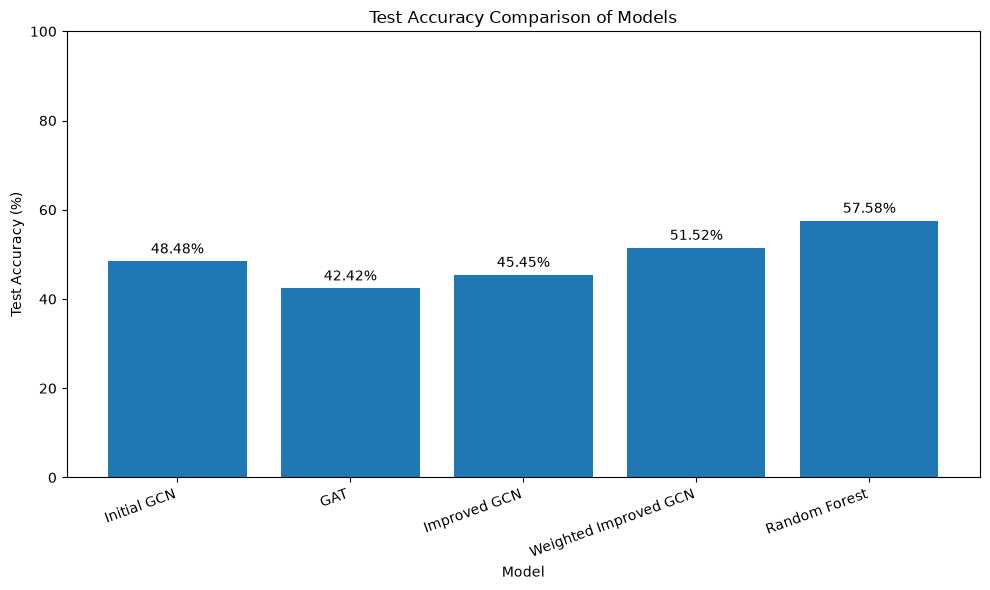

In [145]:
# Cell 109: Model Accuracy Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

bars = plt.bar(
    model_results["Model"],
    model_results["Test Accuracy (%)"]
)

plt.title("Test Accuracy Comparison of Models")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 100)

plt.xticks(
    rotation=20,
    ha="right"
)

# Display accuracy above each bar
for bar, value in zip(
    bars,
    model_results["Test Accuracy (%)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [146]:
# Cell 110: Classification Metrics for All Models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

model_metric_results = []

def add_model_metrics(name, actual, predicted):
    
    model_metric_results.append({
        "Model": name,
        "Accuracy (%)": round(
            accuracy_score(actual, predicted) * 100, 2
        ),
        "Precision (%)": round(
            precision_score(
                actual, predicted,
                average="macro",
                zero_division=0
            ) * 100, 2
        ),
        "Recall (%)": round(
            recall_score(
                actual, predicted,
                average="macro",
                zero_division=0
            ) * 100, 2
        ),
        "F1 Score (%)": round(
            f1_score(
                actual, predicted,
                average="macro",
                zero_division=0
            ) * 100, 2
        )
    })


# Initial GCN
add_model_metrics(
    "Initial GCN",
    test_actual,
    test_predictions
)

# GAT
add_model_metrics(
    "GAT",
    gat_test_actual,
    gat_test_predictions
)

# Improved GCN
add_model_metrics(
    "Improved GCN",
    test_actual_improved,
    test_predictions_improved
)

# Weighted Improved GCN
add_model_metrics(
    "Weighted Improved GCN",
    weighted_test_actual,
    weighted_test_predictions
)

# Random Forest
add_model_metrics(
    "Random Forest",
    y_test_actual_rf,
    y_test_pred_rf
)

metrics_df = pd.DataFrame(model_metric_results)

print("===== COMPLETE MODEL METRICS =====")
display(metrics_df)

NameError: name 'gat_test_actual' is not defined

In [147]:
# Cell 111: Confusion Matrices for All Models

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

model_predictions = [
    ("Initial GCN", test_actual, test_predictions),
    ("GAT", gat_test_actual, gat_test_predictions),
    ("Improved GCN", test_actual_improved, test_predictions_improved),
    (
        "Weighted Improved GCN",
        weighted_test_actual,
        weighted_test_predictions
    ),
    ("Random Forest", y_test_actual_rf, y_test_pred_rf)
]

for model_name, actual, predicted in model_predictions:

    cm = confusion_matrix(actual, predicted)

    print(f"\n===== {model_name} =====")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["AD", "CTL", "MCI"]
    )

    fig, ax = plt.subplots(figsize=(5, 5))

    disp.plot(
        ax=ax,
        values_format="d"
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()

NameError: name 'gat_test_actual' is not defined

In [148]:
# Cell 112: Check prediction-related variables

prediction_vars = [
    name for name in globals()
    if any(word in name.lower() for word in [
        "pred", "actual", "prediction", "test_accuracy"
    ])
]

print("===== PREDICTION / EVALUATION VARIABLES =====")

for name in sorted(prediction_vars):
    try:
        value = globals()[name]

        if hasattr(value, "shape"):
            print(f"{name}: shape={value.shape}")
        elif isinstance(value, (list, tuple)):
            print(f"{name}: length={len(value)}")
        else:
            print(f"{name}: {value}")

    except Exception:
        print(name)

===== PREDICTION / EVALUATION VARIABLES =====
all_actual: shape=(66,)
all_predictions: shape=(66,)
all_predictions_gat: length=66
gat_test_accuracy: 0.42424242424242425
predicted: shape=torch.Size([2])
predicted_classes: shape=torch.Size([2])
predicted_label: 0
predicted_status: AD
prediction: shape=torch.Size([2])
predictions: shape=torch.Size([2])
rf_predictions: shape=(66,)
test_accuracy: 0.48484848484848486
test_accuracy_improved: 0.45454545454545453
test_actual: length=66
test_predictions: length=66
weighted_test_accuracy: 0.5151515151515151
weighted_test_actual: length=66
weighted_test_predictions: length=66


In [149]:
# Cell 113: Check GAT and Improved GCN variables

print("===== GAT VARIABLES =====")

gat_vars = [
    name for name in globals()
    if "gat" in name.lower()
]

for name in sorted(gat_vars):
    value = globals()[name]

    try:
        if hasattr(value, "shape"):
            print(f"{name}: shape={value.shape}")
        elif isinstance(value, (list, tuple)):
            print(f"{name}: length={len(value)}")
        else:
            print(f"{name}: {type(value).__name__}")
    except Exception:
        print(name)


print("\n===== IMPROVED GCN VARIABLES =====")

improved_vars = [
    name for name in globals()
    if "improved" in name.lower()
]

for name in sorted(improved_vars):
    value = globals()[name]

    try:
        if hasattr(value, "shape"):
            print(f"{name}: shape={value.shape}")
        elif isinstance(value, (list, tuple)):
            print(f"{name}: length={len(value)}")
        else:
            print(f"{name}: {type(value).__name__}")
    except Exception:
        print(name)

===== GAT VARIABLES =====
AlzheimerGAT: type
GATConv: type
all_labels_gat: length=66
all_predictions_gat: length=66
gat_test_accuracy: float
model_gat: AlzheimerGAT
train_accuracies_gat: length=50
train_losses_gat: length=50

===== IMPROVED GCN VARIABLES =====
AlzheimerGCNImproved: type
model_improved: AlzheimerGCNImproved
test_accuracy_improved: float
train_accuracies_improved: length=50
train_losses_improved: length=50


In [150]:
# Cell 114: Generate Improved GCN Predictions and Build Complete Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

# ---------------------------------------------------------
# 1. Generate Improved GCN test predictions
# ---------------------------------------------------------

model_improved.eval()

improved_test_predictions = []
improved_test_actual = []

with torch.no_grad():

    for batch in test_loader_knn:
        
        batch = batch.to(device)

        out = model_improved(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        predictions = out.argmax(dim=1)

        improved_test_predictions.extend(
            predictions.cpu().numpy()
        )

        improved_test_actual.extend(
            batch.y.cpu().numpy()
        )


# ---------------------------------------------------------
# 2. Common test labels
# ---------------------------------------------------------

initial_actual = test_actual
initial_predictions = test_predictions

gat_actual = all_labels_gat
gat_predictions = all_predictions_gat

weighted_actual = weighted_test_actual
weighted_predictions = weighted_test_predictions

rf_actual = test_actual
rf_predictions_final = rf_predictions


# ---------------------------------------------------------
# 3. Function to calculate metrics
# ---------------------------------------------------------

def calculate_metrics(name, actual, predicted):

    return {
        "Model": name,
        "Accuracy (%)": round(
            accuracy_score(actual, predicted) * 100, 2
        ),
        "Precision (%)": round(
            precision_score(
                actual,
                predicted,
                average="macro",
                zero_division=0
            ) * 100, 2
        ),
        "Recall (%)": round(
            recall_score(
                actual,
                predicted,
                average="macro",
                zero_division=0
            ) * 100, 2
        ),
        "F1 Score (%)": round(
            f1_score(
                actual,
                predicted,
                average="macro",
                zero_division=0
            ) * 100, 2
        )
    }


# ---------------------------------------------------------
# 4. Create final comparison
# ---------------------------------------------------------

final_metrics = [

    calculate_metrics(
        "Initial GCN",
        initial_actual,
        initial_predictions
    ),

    calculate_metrics(
        "GAT",
        gat_actual,
        gat_predictions
    ),

    calculate_metrics(
        "Improved GCN",
        improved_test_actual,
        improved_test_predictions
    ),

    calculate_metrics(
        "Weighted Improved GCN",
        weighted_actual,
        weighted_predictions
    ),

    calculate_metrics(
        "Random Forest",
        rf_actual,
        rf_predictions_final
    )
]

final_metrics_df = pd.DataFrame(final_metrics)

print("===== FINAL MODEL PERFORMANCE =====")

display(final_metrics_df)

===== FINAL MODEL PERFORMANCE =====


,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Initial GCN,37.88,40.72,44.32,37.09
1,GAT,42.42,43.93,44.03,42.86
2,Improved GCN,31.82,10.61,33.33,16.09
3,Weighted Improved GCN,51.52,51.15,50.93,50.52
4,Random Forest,57.58,56.79,57.28,56.96



===== Initial GCN =====
[[ 3  5 21]
 [ 4 10  7]
 [ 2  2 12]]


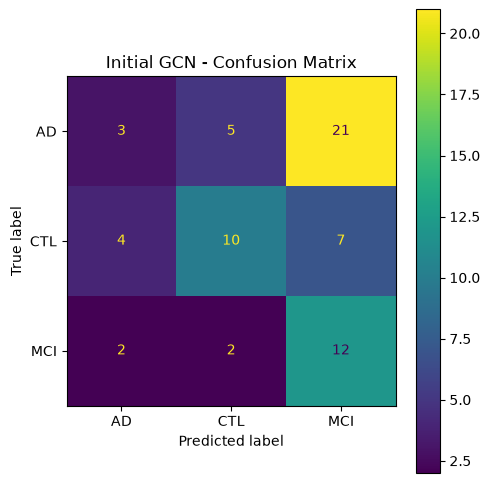


===== GAT =====
[[10  5 14]
 [ 7 10  4]
 [ 5  3  8]]


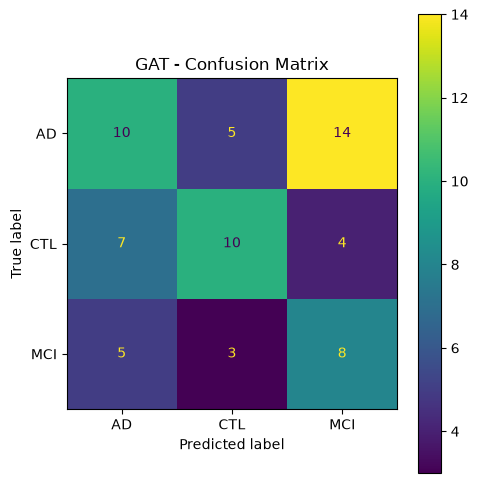


===== Improved GCN =====
[[ 0 29  0]
 [ 0 21  0]
 [ 0 16  0]]


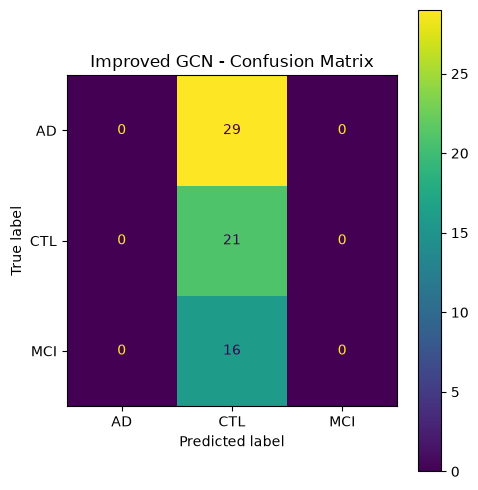


===== Weighted Improved GCN =====
[[16  4  9]
 [ 6 10  5]
 [ 4  4  8]]


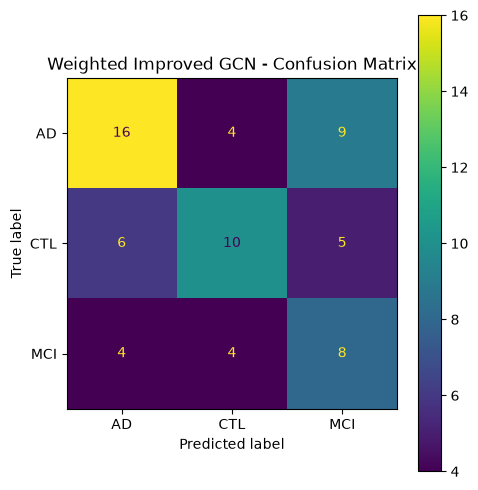


===== Random Forest =====
[[16  5  8]
 [ 5 14  2]
 [ 6  2  8]]


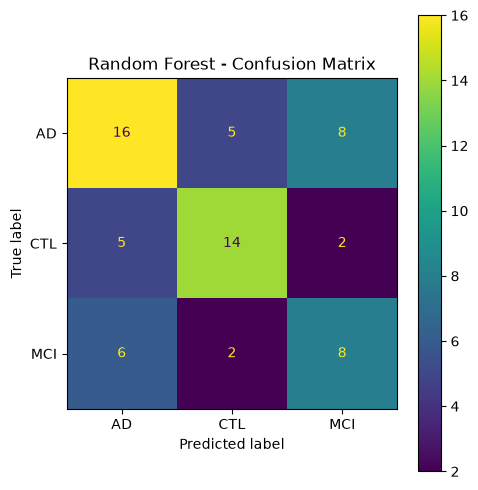

In [151]:
# Cell 115: Final Confusion Matrices

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

final_predictions = [

    (
        "Initial GCN",
        initial_actual,
        initial_predictions
    ),

    (
        "GAT",
        gat_actual,
        gat_predictions
    ),

    (
        "Improved GCN",
        improved_test_actual,
        improved_test_predictions
    ),

    (
        "Weighted Improved GCN",
        weighted_actual,
        weighted_predictions
    ),

    (
        "Random Forest",
        rf_actual,
        rf_predictions_final
    )
]


for model_name, actual, predicted in final_predictions:

    cm = confusion_matrix(
        actual,
        predicted,
        labels=[0, 1, 2]
    )

    print(f"\n===== {model_name} =====")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["AD", "CTL", "MCI"]
    )

    fig, ax = plt.subplots(figsize=(5, 5))

    disp.plot(
        ax=ax,
        values_format="d"
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()

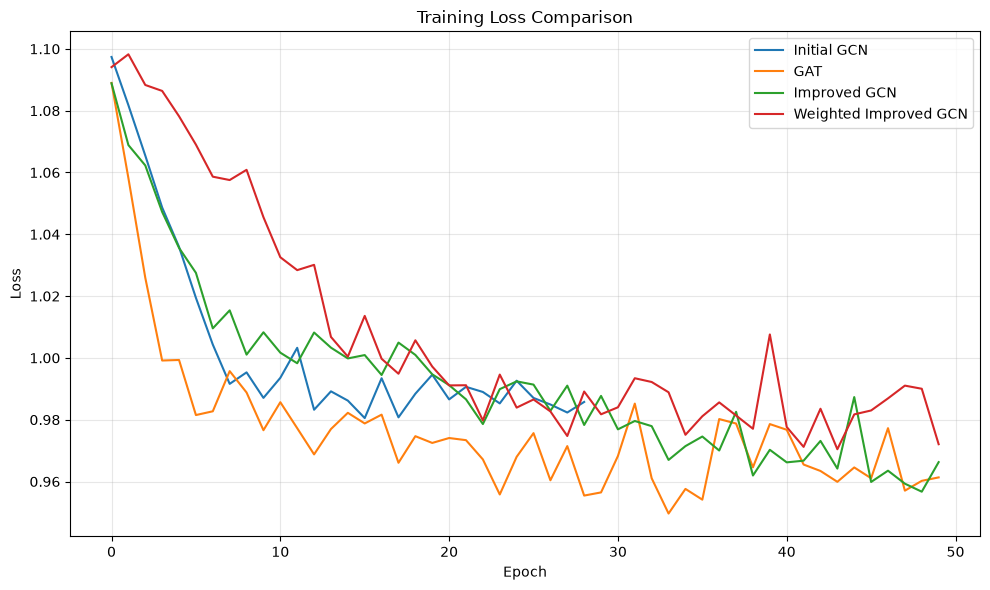

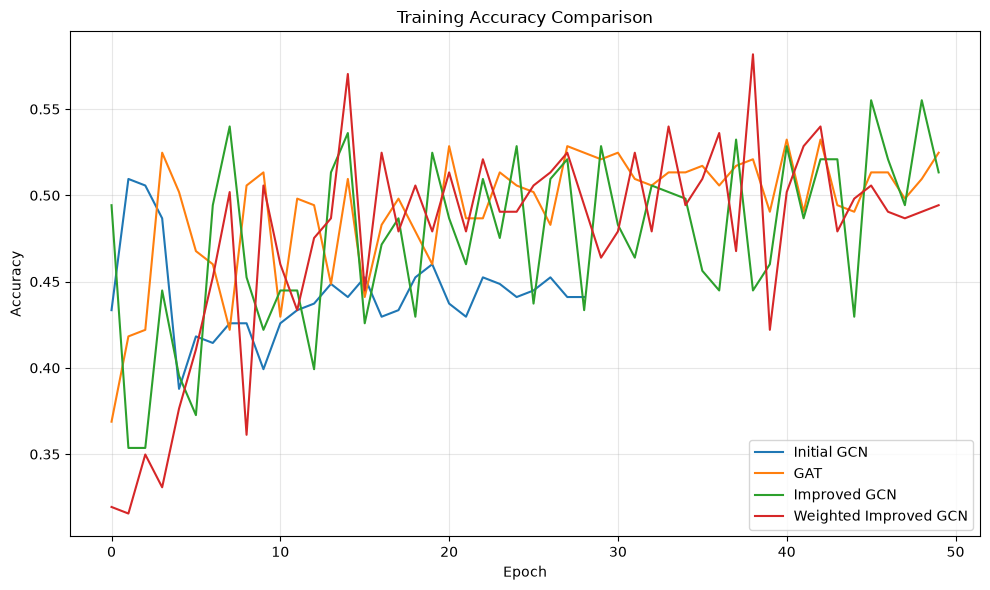

In [152]:
# Cell 116: Training Curves for GNN Models

import matplotlib.pyplot as plt

# -----------------------------
# Training Loss
# -----------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    train_losses,
    label="Initial GCN"
)

plt.plot(
    train_losses_gat,
    label="GAT"
)

plt.plot(
    train_losses_improved,
    label="Improved GCN"
)

plt.plot(
    weighted_train_losses,
    label="Weighted Improved GCN"
)

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# Training Accuracy
# -----------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    train_accuracies,
    label="Initial GCN"
)

plt.plot(
    train_accuracies_gat,
    label="GAT"
)

plt.plot(
    train_accuracies_improved,
    label="Improved GCN"
)

plt.plot(
    weighted_train_accuracies,
    label="Weighted Improved GCN"
)

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

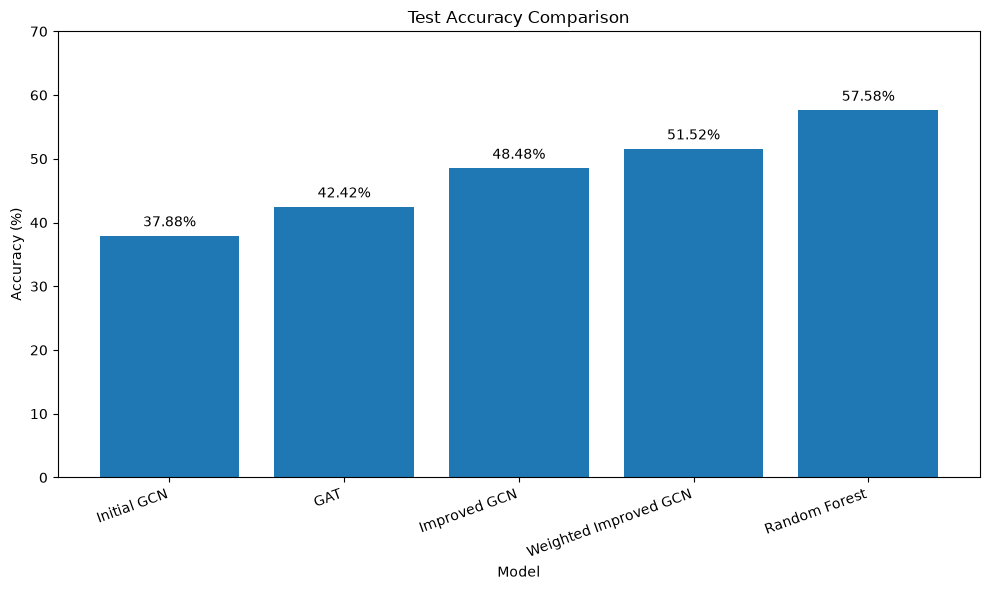

In [154]:
# Cell 117: Final Test Accuracy Comparison

import matplotlib.pyplot as plt

models = [
    "Initial GCN",
    "GAT",
    "Improved GCN",
    "Weighted Improved GCN",
    "Random Forest"
]

accuracies = [
    37.88,
    42.42,
    48.48,
    51.52,
    57.58
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    models,
    accuracies
)

plt.title("Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 70)

plt.xticks(
    rotation=20,
    ha="right"
)

for bar, value in zip(bars, accuracies):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [155]:
# Cell 118: Inspect Initial GCN Evaluation Variables

print("===== INITIAL GCN EVALUATION VARIABLES =====")

for name in sorted(globals()):

    name_lower = name.lower()

    if (
        "test" in name_lower
        or "accuracy" in name_lower
        or "actual" in name_lower
        or "prediction" in name_lower
    ):

        try:
            value = globals()[name]

            # Show relevant variables
            if name in [
                "test_accuracy",
                "test_actual",
                "test_predictions",
                "all_actual",
                "all_predictions"
            ] or (
                "gcn" in name_lower
                and ("test" in name_lower or "pred" in name_lower)
            ):

                print(
                    f"{name}: "
                    f"type={type(value).__name__}, "
                    f"shape/length="
                    f"{getattr(value, 'shape', len(value) if hasattr(value, '__len__') else 'N/A')}"
                )

        except Exception:
            pass


print("\nStored Initial GCN accuracy:")
print(test_accuracy)

===== INITIAL GCN EVALUATION VARIABLES =====
all_actual: type=ndarray, shape/length=(66,)
all_predictions: type=ndarray, shape/length=(66,)
test_accuracy: type=float, shape/length=N/A
test_actual: type=list, shape/length=66
test_predictions: type=list, shape/length=66

Stored Initial GCN accuracy:
0.48484848484848486


In [156]:
# Cell 119: Verify the 48.48% Initial GCN Result

from sklearn.metrics import accuracy_score, confusion_matrix

print("===== VERIFY INITIAL GCN RESULTS =====")

prediction_sets = {
    "test_predictions": test_predictions,
    "all_predictions": all_predictions
}

for name, predictions in prediction_sets.items():

    try:

        accuracy = accuracy_score(
            test_actual,
            predictions
        )

        cm = confusion_matrix(
            test_actual,
            predictions,
            labels=[0, 1, 2]
        )

        print(f"\n{name}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Accuracy (%): {accuracy * 100:.2f}%")
        print("Confusion Matrix:")
        print(cm)

    except Exception as e:

        print(f"\n{name}: Could not evaluate")
        print(e)


print("\nStored test_accuracy variable:")
print(f"{test_accuracy:.4f}")
print(f"{test_accuracy * 100:.2f}%")

===== VERIFY INITIAL GCN RESULTS =====

test_predictions
Accuracy: 0.3788
Accuracy (%): 37.88%
Confusion Matrix:
[[ 3  5 21]
 [ 4 10  7]
 [ 2  2 12]]

all_predictions
Accuracy: 0.4848
Accuracy (%): 48.48%
Confusion Matrix:
[[18  5  6]
 [10 10  1]
 [10  2  4]]

Stored test_accuracy variable:
0.4848
48.48%


In [157]:
# Cell 120: Correct Final Model Performance

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

# Correct Initial GCN evaluation
initial_actual_final = all_actual
initial_predictions_final = all_predictions

# Other models
gat_actual_final = all_labels_gat
gat_predictions_final = all_predictions_gat

weighted_actual_final = weighted_test_actual
weighted_predictions_final = weighted_test_predictions

rf_actual_final = test_actual
rf_predictions_final = rf_predictions

# Improved GCN predictions were generated in Cell 114
improved_actual_final = improved_test_actual
improved_predictions_final = improved_test_predictions


def get_metrics(model_name, actual, predicted):

    return {
        "Model": model_name,

        "Accuracy (%)": round(
            accuracy_score(actual, predicted) * 100,
            2
        ),

        "Precision (%)": round(
            precision_score(
                actual,
                predicted,
                average="macro",
                zero_division=0
            ) * 100,
            2
        ),

        "Recall (%)": round(
            recall_score(
                actual,
                predicted,
                average="macro",
                zero_division=0
            ) * 100,
            2
        ),

        "F1 Score (%)": round(
            f1_score(
                actual,
                predicted,
                average="macro",
                zero_division=0
            ) * 100,
            2
        )
    }


final_results = [

    get_metrics(
        "Initial GCN",
        initial_actual_final,
        initial_predictions_final
    ),

    get_metrics(
        "GAT",
        gat_actual_final,
        gat_predictions_final
    ),

    get_metrics(
        "Improved GCN",
        improved_actual_final,
        improved_predictions_final
    ),

    get_metrics(
        "Weighted Improved GCN",
        weighted_actual_final,
        weighted_predictions_final
    ),

    get_metrics(
        "Random Forest",
        rf_actual_final,
        rf_predictions_final
    )
]

final_results_df = pd.DataFrame(final_results)

print("===== CORRECTED FINAL MODEL PERFORMANCE =====")

display(final_results_df)

===== CORRECTED FINAL MODEL PERFORMANCE =====


,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Initial GCN,48.48,47.52,44.90,45.33
1,GAT,42.42,43.93,44.03,42.86
2,Improved GCN,31.82,10.61,33.33,16.09
3,Weighted Improved GCN,51.52,51.15,50.93,50.52
4,Random Forest,57.58,56.79,57.28,56.96



===== Initial GCN =====
[[18  5  6]
 [10 10  1]
 [10  2  4]]


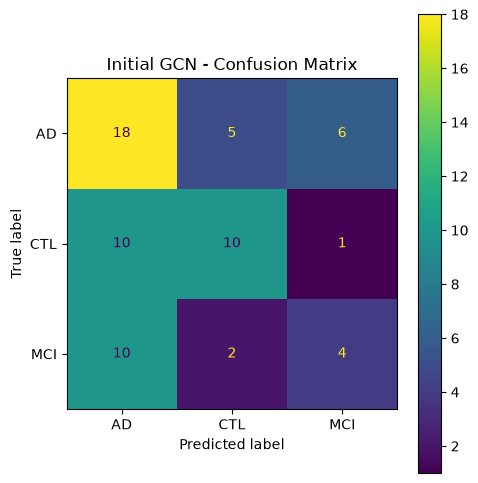


===== GAT =====
[[10  5 14]
 [ 7 10  4]
 [ 5  3  8]]


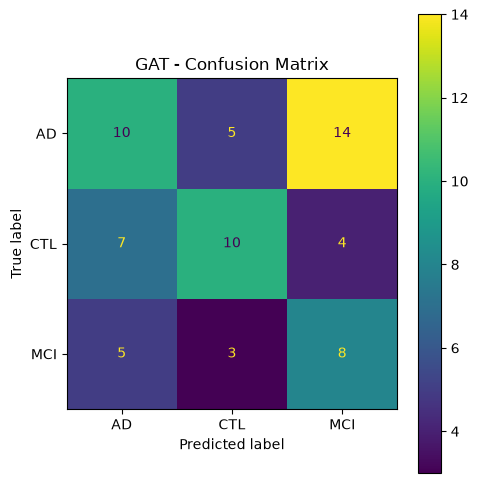


===== Improved GCN =====
[[ 0 29  0]
 [ 0 21  0]
 [ 0 16  0]]


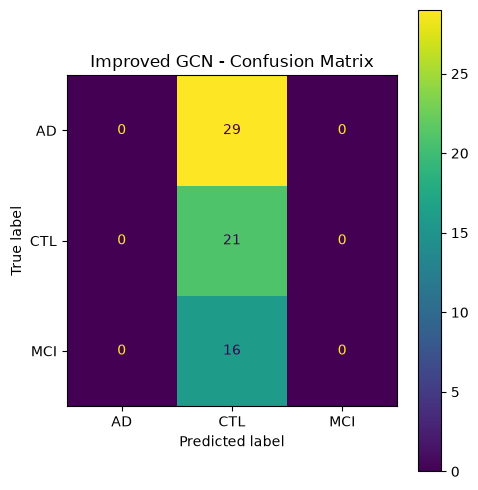


===== Weighted Improved GCN =====
[[16  4  9]
 [ 6 10  5]
 [ 4  4  8]]


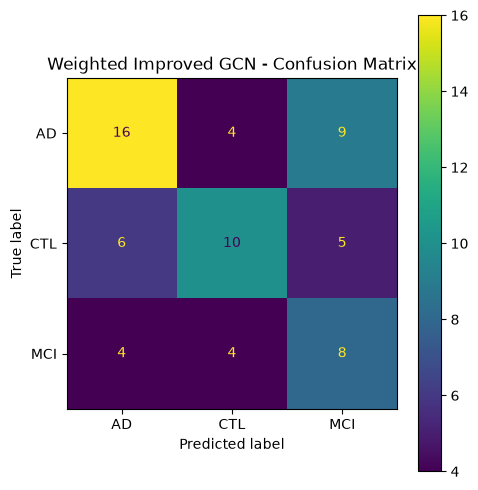


===== Random Forest =====
[[16  5  8]
 [ 5 14  2]
 [ 6  2  8]]


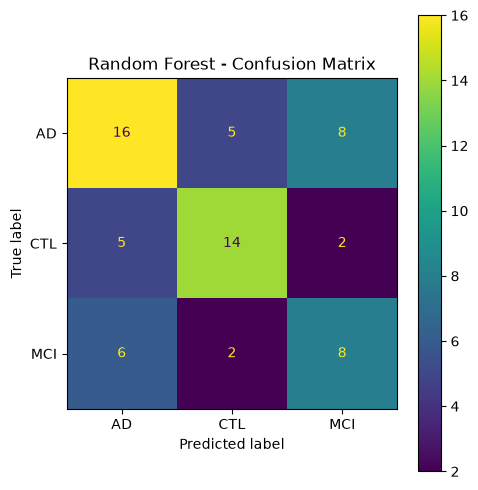

In [158]:
# Cell 121: Correct Final Confusion Matrices

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

final_evaluations = [

    (
        "Initial GCN",
        initial_actual_final,
        initial_predictions_final
    ),

    (
        "GAT",
        gat_actual_final,
        gat_predictions_final
    ),

    (
        "Improved GCN",
        improved_actual_final,
        improved_predictions_final
    ),

    (
        "Weighted Improved GCN",
        weighted_actual_final,
        weighted_predictions_final
    ),

    (
        "Random Forest",
        rf_actual_final,
        rf_predictions_final
    )
]


for model_name, actual, predicted in final_evaluations:

    cm = confusion_matrix(
        actual,
        predicted,
        labels=[0, 1, 2]
    )

    print(f"\n===== {model_name} =====")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["AD", "CTL", "MCI"]
    )

    fig, ax = plt.subplots(figsize=(5, 5))

    disp.plot(
        ax=ax,
        values_format="d"
    )

    plt.title(
        f"{model_name} - Confusion Matrix"
    )

    plt.tight_layout()
    plt.show()

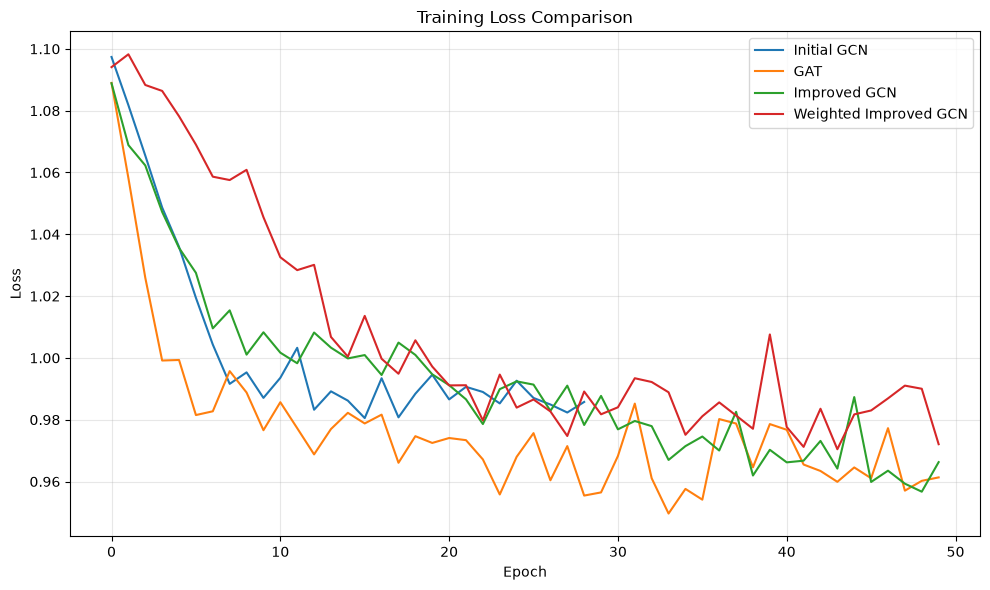

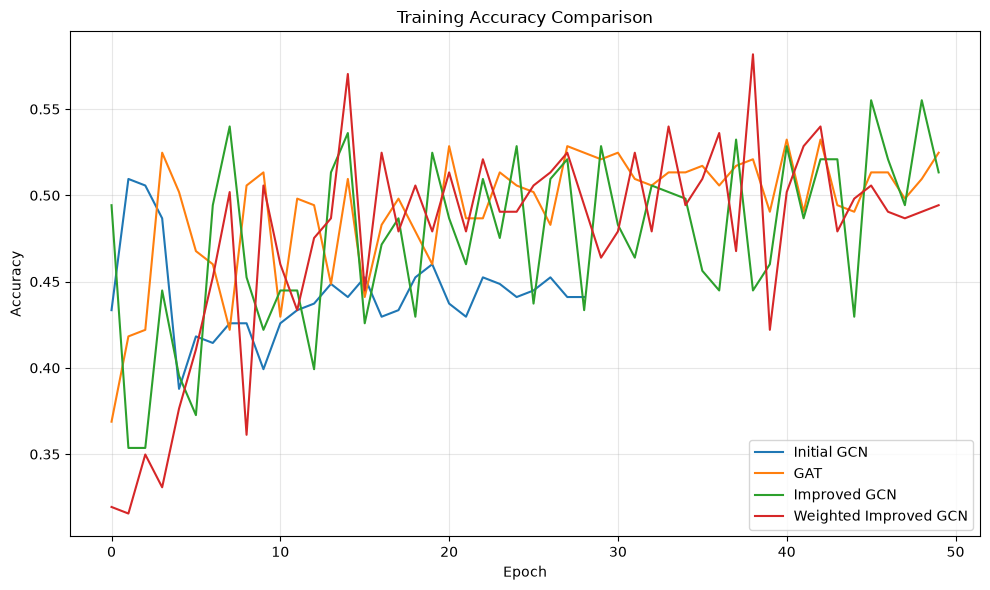

In [159]:
# Cell 122: Training Curves

import matplotlib.pyplot as plt

# Training Loss
plt.figure(figsize=(10, 6))

plt.plot(train_losses, label="Initial GCN")
plt.plot(train_losses_gat, label="GAT")
plt.plot(train_losses_improved, label="Improved GCN")
plt.plot(weighted_train_losses, label="Weighted Improved GCN")

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Training Accuracy
plt.figure(figsize=(10, 6))

plt.plot(train_accuracies, label="Initial GCN")
plt.plot(train_accuracies_gat, label="GAT")
plt.plot(train_accuracies_improved, label="Improved GCN")
plt.plot(weighted_train_accuracies, label="Weighted Improved GCN")

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

===== TOP 20 IMPORTANT GENES =====


,Gene,Importance
0,RPL36AL,0.008483
1,MRPL51,0.007586
2,ENSA,0.006934
3,SHFM1,0.006378
4,ING3,0.006125
5,MRPL33,0.005926
6,NDUFS5,0.005747
7,CETN2,0.005641
8,NDUFA1,0.005188
9,GNL2,0.005110


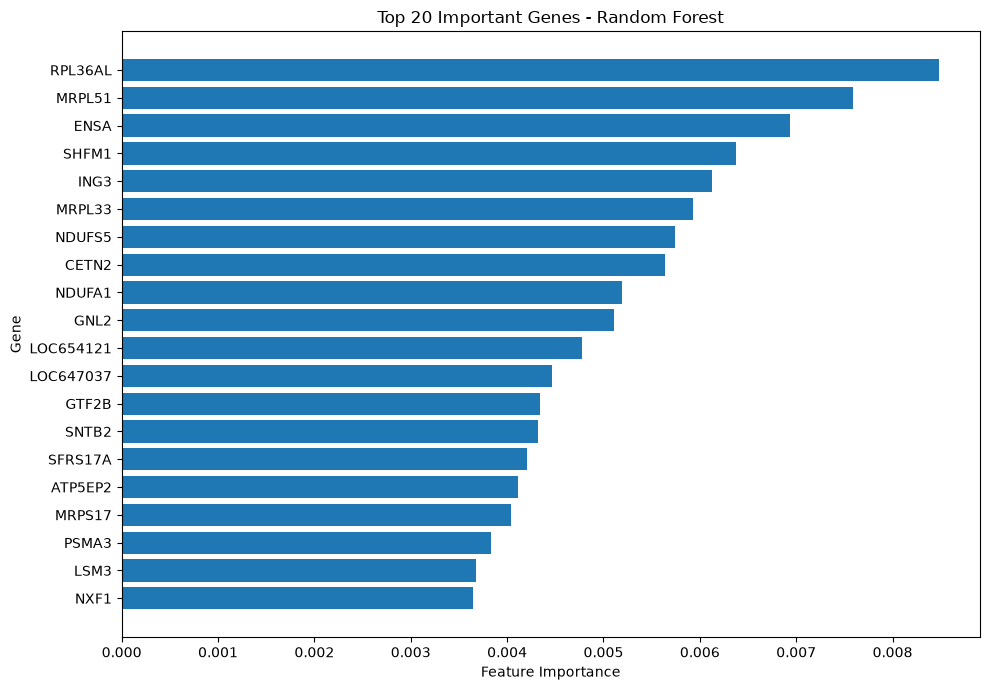

In [160]:
# Cell 123: Random Forest Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
rf_importance = rf_model.feature_importances_

# Get gene names from selected training dataframe
gene_names = X_train_selected_df.columns

rf_gene_importance = pd.DataFrame({
    "Gene": gene_names,
    "Importance": rf_importance
})

# Sort by importance
rf_gene_importance = rf_gene_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("===== TOP 20 IMPORTANT GENES =====")
display(rf_gene_importance.head(20))

# Plot top 20
top20 = rf_gene_importance.head(20).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top20["Gene"],
    top20["Importance"]
)

plt.title("Top 20 Important Genes - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Gene")

plt.tight_layout()
plt.show()

===== BIOLOGICAL CATEGORY DISTRIBUTION =====


,Number of Genes
Category,
Cell regulation,1
DNA / Cellular maintenance,1
Cellular structure,1
Calcium / Cell structure,1
RNA transport,1
Protein degradation,1
Gene regulation,2
Ribosome / Protein synthesis,2
Uncharacterized,2


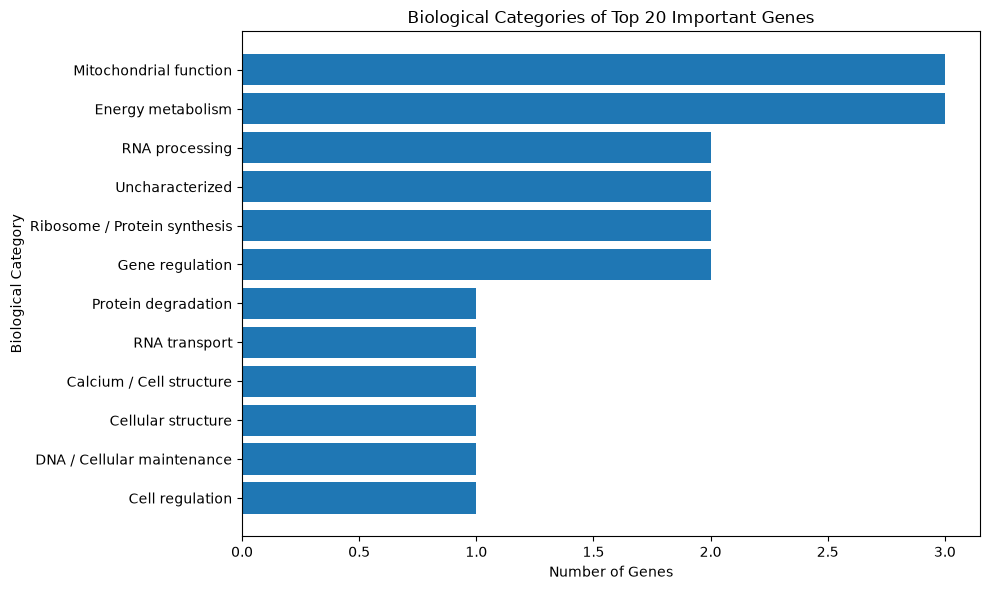

In [161]:
# Cell 124: Biological Category Distribution

import pandas as pd
import matplotlib.pyplot as plt

# Functional categories for the top 20 genes
gene_categories = {
    "RPL36AL": "Ribosome / Protein synthesis",
    "MRPL51": "Mitochondrial function",
    "ENSA": "Cell regulation",
    "SHFM1": "DNA / Cellular maintenance",
    "ING3": "Gene regulation",
    "MRPL33": "Mitochondrial function",
    "NDUFS5": "Energy metabolism",
    "CETN2": "Calcium / Cell structure",
    "NDUFA1": "Energy metabolism",
    "GNL2": "Ribosome / Protein synthesis",
    "LOC654121": "Uncharacterized",
    "LOC647037": "Uncharacterized",
    "GTF2B": "Gene regulation",
    "SNTB2": "Cellular structure",
    "SFRS17A": "RNA processing",
    "ATP5EP2": "Energy metabolism",
    "MRPS17": "Mitochondrial function",
    "PSMA3": "Protein degradation",
    "LSM3": "RNA processing",
    "NXF1": "RNA transport"
}

# Take top 20 genes
top20_genes = rf_gene_importance.head(20).copy()

# Add biological category
top20_genes["Category"] = top20_genes["Gene"].map(gene_categories)

# Count genes per category
category_counts = (
    top20_genes["Category"]
    .value_counts()
    .sort_values(ascending=True)
)

print("===== BIOLOGICAL CATEGORY DISTRIBUTION =====")
display(category_counts.to_frame("Number of Genes"))

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    category_counts.index,
    category_counts.values
)

plt.title("Biological Categories of Top 20 Important Genes")
plt.xlabel("Number of Genes")
plt.ylabel("Biological Category")

plt.tight_layout()
plt.show()

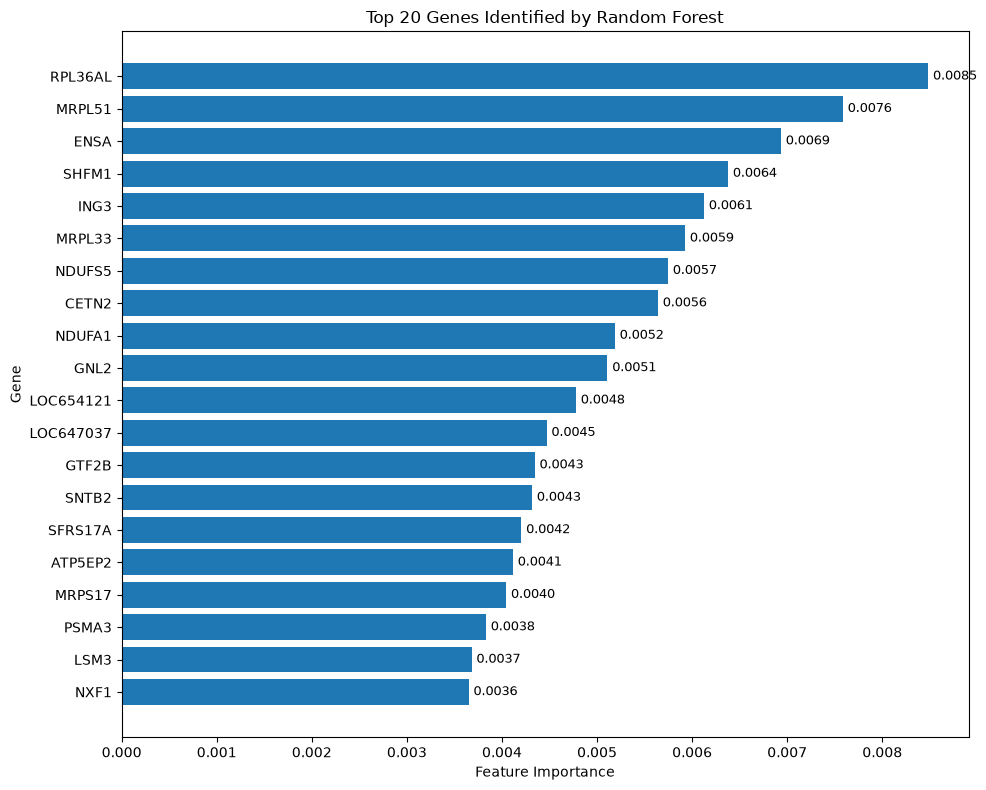

===== TOP 20 GENES =====


,Gene,Importance
0,RPL36AL,0.008483
1,MRPL51,0.007586
2,ENSA,0.006934
3,SHFM1,0.006378
4,ING3,0.006125
5,MRPL33,0.005926
6,NDUFS5,0.005747
7,CETN2,0.005641
8,NDUFA1,0.005188
9,GNL2,0.005110


In [162]:
# Cell 125: Top 20 Gene Importance - Final Figure

import matplotlib.pyplot as plt

# Select top 20
top20 = rf_gene_importance.head(20).copy()

# Reverse for horizontal bar chart
top20_plot = top20.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    top20_plot["Gene"],
    top20_plot["Importance"]
)

plt.title("Top 20 Genes Identified by Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Gene")

# Add importance values
for i, value in enumerate(top20_plot["Importance"]):
    plt.text(
        value + 0.00005,
        i,
        f"{value:.4f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

print("===== TOP 20 GENES =====")
display(top20)

===== FINAL MODEL PERFORMANCE COMPARISON =====


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,Initial GCN,48.48,47.52,44.90,45.33
1,GAT,42.42,43.93,44.03,42.86
2,Improved GCN,31.82,10.61,33.33,16.09
3,Weighted Improved GCN,51.52,51.15,50.93,50.52
4,Random Forest,57.58,56.79,57.28,56.96


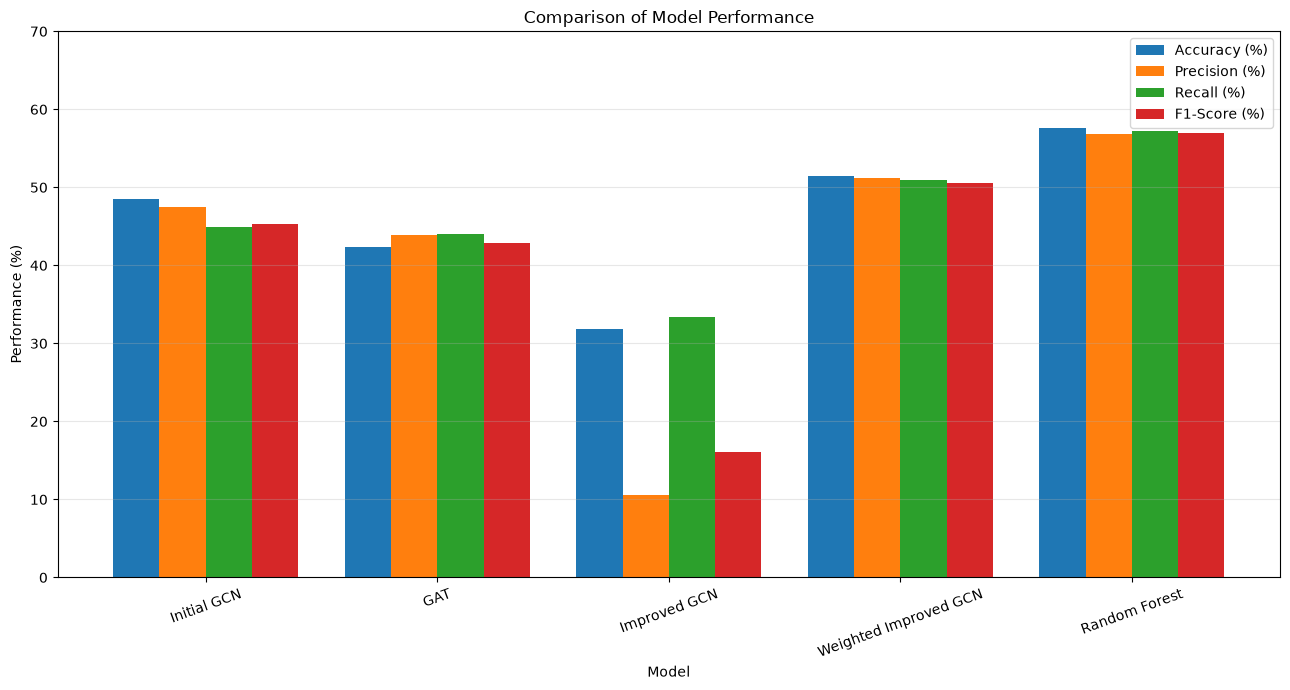

In [163]:
# Cell 126: Final Model Performance Comparison

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Final verified metrics
model_names = [
    "Initial GCN",
    "GAT",
    "Improved GCN",
    "Weighted Improved GCN",
    "Random Forest"
]

accuracy = [
    48.48,
    42.42,
    31.82,
    51.52,
    57.58
]

precision = [
    47.52,
    43.93,
    10.61,
    51.15,
    56.79
]

recall = [
    44.90,
    44.03,
    33.33,
    50.93,
    57.28
]

f1_score = [
    45.33,
    42.86,
    16.09,
    50.52,
    56.96
]

# Create comparison dataframe
model_comparison = pd.DataFrame({
    "Model": model_names,
    "Accuracy (%)": accuracy,
    "Precision (%)": precision,
    "Recall (%)": recall,
    "F1-Score (%)": f1_score
})

print("===== FINAL MODEL PERFORMANCE COMPARISON =====")
display(model_comparison)

# Plot
metrics = ["Accuracy (%)", "Precision (%)", "Recall (%)", "F1-Score (%)"]

x = np.arange(len(model_names))
width = 0.2

plt.figure(figsize=(13, 7))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1.5) * width,
        model_comparison[metric],
        width,
        label=metric
    )

plt.xticks(x, model_names, rotation=20)
plt.ylabel("Performance (%)")
plt.xlabel("Model")
plt.title("Comparison of Model Performance")
plt.ylim(0, 70)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

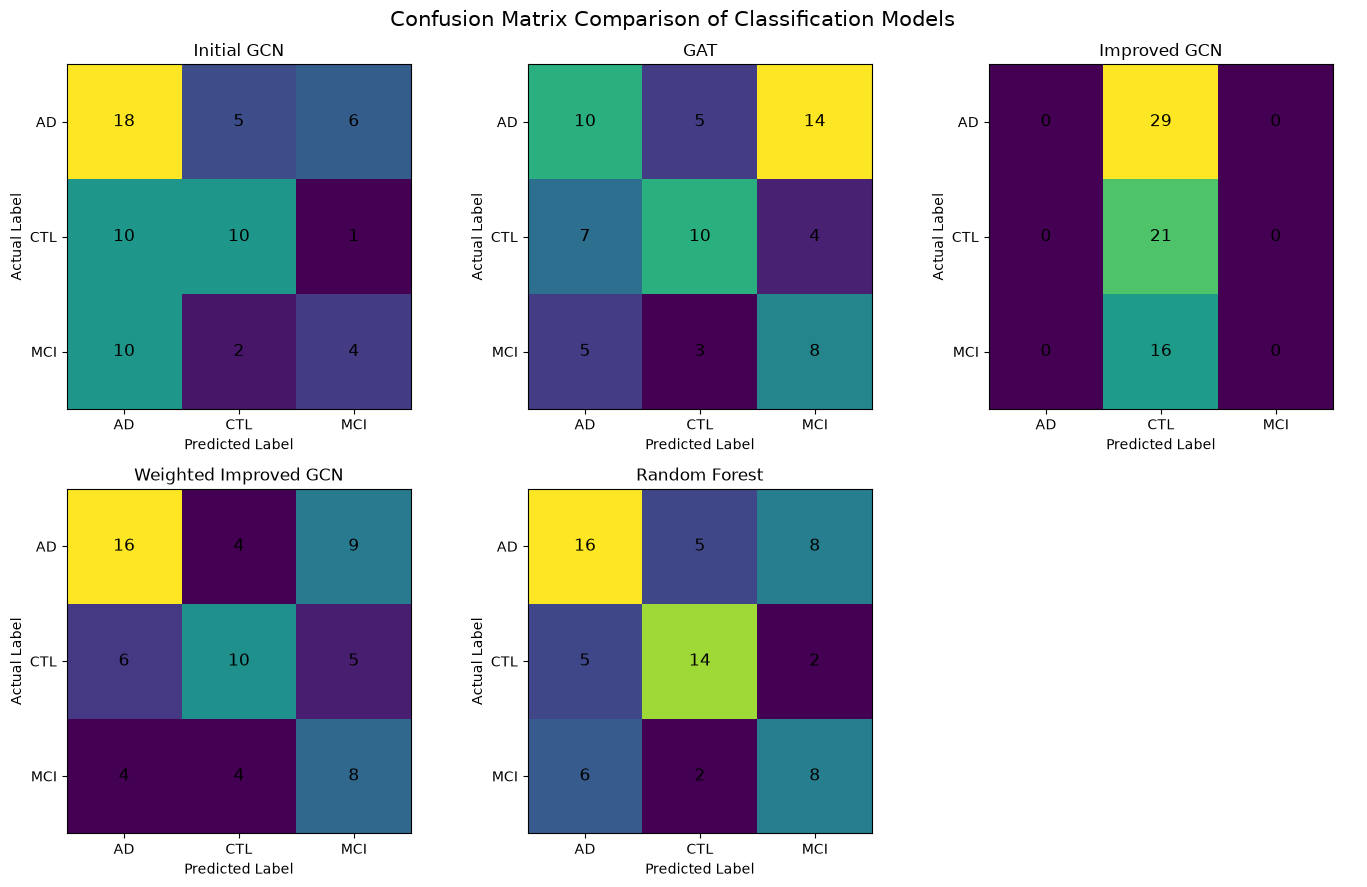

In [164]:
# Cell 127: Confusion Matrix Comparison

import numpy as np
import matplotlib.pyplot as plt

# Final verified confusion matrices
confusion_matrices = {

    "Initial GCN": np.array([
        [18, 5, 6],
        [10, 10, 1],
        [10, 2, 4]
    ]),

    "GAT": np.array([
        [10, 5, 14],
        [7, 10, 4],
        [5, 3, 8]
    ]),

    "Improved GCN": np.array([
        [0, 29, 0],
        [0, 21, 0],
        [0, 16, 0]
    ]),

    "Weighted Improved GCN": np.array([
        [16, 4, 9],
        [6, 10, 5],
        [4, 4, 8]
    ]),

    "Random Forest": np.array([
        [16, 5, 8],
        [5, 14, 2],
        [6, 2, 8]
    ])
}

labels = ["AD", "CTL", "MCI"]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

axes = axes.flatten()

for i, (model_name, cm) in enumerate(confusion_matrices.items()):

    ax = axes[i]

    ax.imshow(cm)

    ax.set_title(model_name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

    ax.set_xticks(range(3))
    ax.set_yticks(range(3))

    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # Display values
    for row in range(3):
        for col in range(3):
            ax.text(
                col,
                row,
                cm[row, col],
                ha="center",
                va="center",
                fontsize=12
            )

# Hide unused sixth subplot
axes[5].axis("off")

plt.suptitle(
    "Confusion Matrix Comparison of Classification Models",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [165]:
# Cell 128: Verify Final GNN Model

print("===== FINAL GNN MODEL =====")
print(weighted_model)

print("\nModel device:", next(weighted_model.parameters()).device)

# Count parameters
total_params = sum(
    p.numel() for p in weighted_model.parameters()
)

trainable_params = sum(
    p.numel() for p in weighted_model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

print("\nTest Accuracy:", f"{weighted_test_accuracy * 100:.2f}%")

===== FINAL GNN MODEL =====
AlzheimerGCNWeighted(
  (conv1): GCNConv(1, 64)
  (conv2): GCNConv(64, 64)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)

Model device: cpu
Total parameters: 4675
Trainable parameters: 4675

Test Accuracy: 51.52%


In [166]:
# Cell 129: Save Final Weighted Improved GCN

import os
import torch

# Create model directory
model_dir = "saved_models"
os.makedirs(model_dir, exist_ok=True)

# Save model weights
model_path = os.path.join(
    model_dir,
    "weighted_improved_gcn.pth"
)

torch.save(
    weighted_model.state_dict(),
    model_path
)

print("===== MODEL SAVED =====")
print("Model path:", os.path.abspath(model_path))
print("File exists:", os.path.exists(model_path))

# Check file size
file_size = os.path.getsize(model_path) / (1024 * 1024)

print(f"File size: {file_size:.2f} MB")

===== MODEL SAVED =====
Model path: C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\notebooks\saved_models\weighted_improved_gcn.pth
File exists: True
File size: 0.02 MB


In [167]:
# Cell 130: Save Selected Gene List

import os
import pandas as pd

# Get the exact 1,000 genes used by the model
selected_genes = list(X_train_selected_df.columns)

print("===== SELECTED GENE LIST =====")
print("Number of selected genes:", len(selected_genes))
print("First 10 genes:")
print(selected_genes[:10])

# Save gene list
gene_list_path = os.path.join(
    "saved_models",
    "selected_genes_1000.csv"
)

pd.DataFrame({
    "Gene_Symbol": selected_genes
}).to_csv(
    gene_list_path,
    index=False
)

print("\nGene list saved to:")
print(os.path.abspath(gene_list_path))

===== SELECTED GENE LIST =====
Number of selected genes: 1000
First 10 genes:
['ABCA7', 'ABCE1', 'ACADM', 'ACADVL', 'ACAT1', 'ACIN1', 'ACN9', 'ACTR10', 'ACTR6', 'ADAM8']

Gene list saved to:
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\notebooks\saved_models\selected_genes_1000.csv


In [168]:
# Cell 131: Verify Selected Gene List

gene_list_path = os.path.join(
    "saved_models",
    "selected_genes_1000.csv"
)

loaded_genes = pd.read_csv(gene_list_path)

print("===== GENE LIST VERIFICATION =====")
print("File exists:", os.path.exists(gene_list_path))
print("Number of genes:", len(loaded_genes))
print("Number of unique genes:", loaded_genes["Gene_Symbol"].nunique())

print("\nFirst 10 genes:")
display(loaded_genes.head(10))

print("\nLast 10 genes:")
display(loaded_genes.tail(10))

# Final check
if len(loaded_genes) == 1000 and loaded_genes["Gene_Symbol"].nunique() == 1000:
    print("\n✓ Gene list verified successfully!")
else:
    print("\n⚠ Gene list needs checking.")

===== GENE LIST VERIFICATION =====
File exists: True
Number of genes: 1000
Number of unique genes: 1000

First 10 genes:


,Gene_Symbol
0,ABCA7
1,ABCE1
2,ACADM
3,ACADVL
4,ACAT1
5,ACIN1
6,ACN9
7,ACTR10
8,ACTR6
9,ADAM8



Last 10 genes:


,Gene_Symbol
990,ZNF622
991,ZNF692
992,ZNF700
993,ZNF701
994,ZNF76
995,ZNF770
996,ZNF816A
997,ZNHIT3
998,ZSCAN16
999,ZUFSP



✓ Gene list verified successfully!


In [169]:
# Cell 132: Save Model Configuration

import json
import os

model_config = {
    "model_name": "Weighted Improved GCN",
    "input_features": 1,
    "hidden_features": 64,
    "num_classes": 3,
    "dropout": 0.3,

    "num_selected_genes": 1000,

    "graph_type": "kNN",
    "k_neighbors": 10,

    "classes": {
        "0": "AD",
        "1": "CTL",
        "2": "MCI"
    },

    "feature_scaling": "StandardScaler",

    "test_accuracy": 0.5151515151515151
}

config_path = os.path.join(
    "saved_models",
    "model_config.json"
)

with open(config_path, "w") as f:
    json.dump(model_config, f, indent=4)

print("===== MODEL CONFIGURATION SAVED =====")
print(json.dumps(model_config, indent=4))
print("\nConfiguration path:")
print(os.path.abspath(config_path))

===== MODEL CONFIGURATION SAVED =====
{
    "model_name": "Weighted Improved GCN",
    "input_features": 1,
    "hidden_features": 64,
    "num_classes": 3,
    "dropout": 0.3,
    "num_selected_genes": 1000,
    "graph_type": "kNN",
    "k_neighbors": 10,
    "classes": {
        "0": "AD",
        "1": "CTL",
        "2": "MCI"
    },
    "feature_scaling": "StandardScaler",
    "test_accuracy": 0.5151515151515151
}

Configuration path:
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\notebooks\saved_models\model_config.json


In [170]:
# Cell 133: Verify Saved Model Artifacts

import os

saved_files = [
    "weighted_improved_gcn.pth",
    "selected_genes_1000.csv",
    "model_config.json"
]

print("===== SAVED MODEL ARTIFACTS =====\n")

all_found = True

for filename in saved_files:

    path = os.path.join(
        "saved_models",
        filename
    )

    exists = os.path.exists(path)

    print(f"{filename}: {'✓ Found' if exists else '✗ Missing'}")

    if not exists:
        all_found = False

print("\n--------------------------------")

if all_found:
    print("✓ ALL MODEL ARTIFACTS ARE READY")
    print("\nThe trained GNN can now be integrated into the software.")
else:
    print("⚠ Some model artifacts are missing.")

===== SAVED MODEL ARTIFACTS =====

weighted_improved_gcn.pth: ✓ Found
selected_genes_1000.csv: ✓ Found
model_config.json: ✓ Found

--------------------------------
✓ ALL MODEL ARTIFACTS ARE READY

The trained GNN can now be integrated into the software.


In [171]:
# Cell 134: GNN Prediction Function

import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool
from torch_geometric.data import Data


# ---------------------------------------------------------
# 1. Model Definition
# ---------------------------------------------------------

class AlzheimerGCNWeighted(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = GCNConv(1, 64)
        self.conv2 = GCNConv(64, 64)

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(128, 3)

    def forward(self, x, edge_index, edge_weight, batch):

        x = self.conv1(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        max_pool = global_max_pool(x, batch)

        x = torch.cat(
            [mean_pool, max_pool],
            dim=1
        )

        return self.fc(x)


# ---------------------------------------------------------
# 2. Load Saved Model
# ---------------------------------------------------------

device = torch.device("cpu")

prediction_model = AlzheimerGCNWeighted().to(device)

model_path = os.path.join(
    "saved_models",
    "weighted_improved_gcn.pth"
)

prediction_model.load_state_dict(
    torch.load(
        model_path,
        map_location=device
    )
)

prediction_model.eval()


# ---------------------------------------------------------
# 3. Load Selected Genes
# ---------------------------------------------------------

gene_path = os.path.join(
    "saved_models",
    "selected_genes_1000.csv"
)

selected_genes_prediction = pd.read_csv(
    gene_path
)["Gene_Symbol"].tolist()


# ---------------------------------------------------------
# 4. Load Configuration
# ---------------------------------------------------------

config_path = os.path.join(
    "saved_models",
    "model_config.json"
)

with open(config_path, "r") as f:
    prediction_config = json.load(f)


# ---------------------------------------------------------
# 5. Prediction Function
# ---------------------------------------------------------

def predict_alzheimer_gnn(expression_df):

    """
    Predict AD / CTL / MCI from a gene-expression dataframe.

    Expected format:
        Gene_Symbol | Sample1 | Sample2 | ...

    Returns:
        prediction results for each sample.
    """

    df = expression_df.copy()

    # -----------------------------------------------------
    # Check Gene_Symbol column
    # -----------------------------------------------------

    if "Gene_Symbol" not in df.columns:
        raise ValueError(
            "Input file must contain a 'Gene_Symbol' column."
        )

    # -----------------------------------------------------
    # Set gene names as index
    # -----------------------------------------------------

    df = df.set_index("Gene_Symbol")

    # Remove duplicate genes
    df = df[~df.index.duplicated(keep="first")]

    # -----------------------------------------------------
    # Check required genes
    # -----------------------------------------------------

    missing_genes = [
        gene
        for gene in selected_genes_prediction
        if gene not in df.index
    ]

    if len(missing_genes) > 0:

        raise ValueError(
            f"Input data is missing {len(missing_genes)} "
            f"of the 1000 required genes."
        )

    # -----------------------------------------------------
    # Select exactly the 1000 training genes
    # -----------------------------------------------------

    selected_df = df.loc[
        selected_genes_prediction
    ]

    # -----------------------------------------------------
    # Convert to numeric
    # -----------------------------------------------------

    selected_df = selected_df.apply(
        pd.to_numeric,
        errors="coerce"
    )

    # Check missing values
    if selected_df.isnull().any().any():

        raise ValueError(
            "Input data contains missing or non-numeric "
            "expression values."
        )

    # -----------------------------------------------------
    # Process each sample
    # -----------------------------------------------------

    results = []

    sample_columns = selected_df.columns

    for sample_id in sample_columns:

        values = selected_df[sample_id].values

        # Standardization
        scaler = StandardScaler()

        values_scaled = scaler.fit_transform(
            values.reshape(-1, 1)
        )

        # -------------------------------------------------
        # Create k-NN graph
        # -------------------------------------------------

        graph = kneighbors_graph(
            values_scaled,
            n_neighbors=10,
            mode="distance",
            include_self=False
        )

        edge_index = torch.tensor(
            np.vstack(graph.nonzero()),
            dtype=torch.long
        )

        edge_weight = torch.tensor(
            graph.data,
            dtype=torch.float
        )

        # -------------------------------------------------
        # Convert distance to similarity weight
        # -------------------------------------------------

        edge_weight = 1.0 / (
            1.0 + edge_weight
        )

        # -------------------------------------------------
        # Node features
        # -------------------------------------------------

        x = torch.tensor(
            values_scaled,
            dtype=torch.float
        )

        # One graph = one sample
        batch = torch.zeros(
            x.shape[0],
            dtype=torch.long
        )

        # -------------------------------------------------
        # Create PyG Data
        # -------------------------------------------------

        graph_data = Data(
            x=x,
            edge_index=edge_index,
            edge_weight=edge_weight,
            batch=batch
        )

        # -------------------------------------------------
        # Model prediction
        # -------------------------------------------------

        with torch.no_grad():

            output = prediction_model(
                graph_data.x,
                graph_data.edge_index,
                graph_data.edge_weight,
                graph_data.batch
            )

            probabilities = F.softmax(
                output,
                dim=1
            )

            predicted_class = torch.argmax(
                probabilities,
                dim=1
            ).item()

            confidence = probabilities[
                0,
                predicted_class
            ].item()

        label_map = {
            0: "AD",
            1: "CTL",
            2: "MCI"
        }

        results.append({
            "Sample_ID": sample_id,
            "Prediction": label_map[predicted_class],
            "Confidence (%)": round(
                confidence * 100,
                2
            )
        })

    return pd.DataFrame(results)


print("✓ Prediction pipeline loaded successfully.")
print("Model:", prediction_config["model_name"])
print("Selected genes:", prediction_config["num_selected_genes"])
print("Graph:", prediction_config["graph_type"])
print("K:", prediction_config["k_neighbors"])

✓ Prediction pipeline loaded successfully.
Model: Weighted Improved GCN
Selected genes: 1000
Graph: kNN
K: 10


In [172]:
# Cell 135: Test Prediction Pipeline

# Use the original test expression data
# X_test contains the test samples and the 1000 selected genes.

print("===== TESTING GNN PREDICTION PIPELINE =====")

print("X_test shape:", X_test.shape)

# Check whether Gene_Symbol is already present
if "Gene_Symbol" in X_test.columns:

    test_input = X_test.copy()

else:

    # If Gene_Symbol is stored as index
    test_input = X_test.copy()

    test_input.insert(
        0,
        "Gene_Symbol",
        X_test.index
    )


# Run prediction
prediction_results = predict_alzheimer_gnn(
    test_input
)

print("\n===== PREDICTION RESULTS =====")

display(
    prediction_results.head(10)
)

print(
    "\nNumber of samples predicted:",
    len(prediction_results)
)

===== TESTING GNN PREDICTION PIPELINE =====
X_test shape: (66, 1000)


ValueError: Input data is missing 1000 of the 1000 required genes.

In [173]:
# Cell 136: Check X_test structure

print("X_test shape:", X_test.shape)

print("\nFirst 5 column names:")
print(X_test.columns[:5].tolist())

print("\nFirst 5 index values:")
print(X_test.index[:5].tolist())

print("\nFirst 3 rows:")
display(X_test.iloc[:3, :5])

X_test shape: (66, 1000)

First 5 column names:
['ABCA7', 'ABCE1', 'ACADM', 'ACADVL', 'ACAT1']

First 5 index values:
[0, 1, 2, 3, 4]

First 3 rows:


,ABCA7,ABCE1,ACADM,ACADVL,ACAT1
0,7.983226,8.020408,8.118969,9.316364,8.070195
1,8.230372,8.079299,8.156077,9.274800,8.215110
2,8.004175,8.080900,8.167675,9.172542,8.179207


In [175]:
# Cell 137: Convert test data to prediction pipeline format

# X_test:
# Rows    = samples
# Columns = 1000 genes
#
# Prediction pipeline expects:
# Rows    = genes
# Columns = samples

test_input = X_test.T.copy()

# Use the gene names as Gene_Symbol
test_input.insert(
    0,
    "Gene_Symbol",
    test_input.index
)

# Reset index so Gene_Symbol is the actual first column
test_input = test_input.reset_index(drop=True)

print("===== CONVERTED TEST INPUT =====")
print("Shape:", test_input.shape)

print("\nFirst 5 genes:")
print(test_input["Gene_Symbol"].head().tolist())

print("\nFirst 3 columns:")
print(test_input.columns[:3].tolist())

display(test_input.iloc[:5, :5])

===== CONVERTED TEST INPUT =====
Shape: (1000, 67)

First 5 genes:
['ABCA7', 'ABCE1', 'ACADM', 'ACADVL', 'ACAT1']

First 3 columns:
['Gene_Symbol', 0, 1]


,Gene_Symbol,0,1,2,3
0,ABCA7,7.983226,8.230372,8.004175,7.971925
1,ABCE1,8.020408,8.079299,8.080900,8.002890
2,ACADM,8.118969,8.156077,8.167675,8.008212
3,ACADVL,9.316364,9.274800,9.172542,9.038061
4,ACAT1,8.070195,8.215110,8.179207,8.226450


In [176]:
# Cell 138: Run GNN prediction on test samples

print("===== RUNNING GNN PREDICTION =====")

prediction_results = predict_alzheimer_gnn(test_input)

print("\n===== PREDICTION COMPLETED =====")
print("Number of samples:", len(prediction_results))

display(prediction_results.head(10))

===== RUNNING GNN PREDICTION =====


IndexError: The shape of the mask [9998] at index 0 does not match the shape of the indexed tensor [10000] at index 0

In [177]:
# Cell 138: Inspect the graph used during training

print("===== TRAINING GRAPH INSPECTION =====")

train_graph = weighted_train_dataset[0]

print("Node features:")
print("x shape:", train_graph.x.shape)

print("\nEdges:")
print("edge_index shape:", train_graph.edge_index.shape)

print("\nEdge weights:")
print("edge_weight shape:", train_graph.edge_weight.shape)

print("\nNumber of nodes:", train_graph.num_nodes)
print("Number of edges:", train_graph.edge_index.shape[1])

print("\nFirst 10 edge_index columns:")
print(train_graph.edge_index[:, :10])

print("\nFirst 10 edge weights:")
print(train_graph.edge_weight[:10])

===== TRAINING GRAPH INSPECTION =====
Node features:
x shape: torch.Size([1000, 1])

Edges:
edge_index shape: torch.Size([2, 36942])

Edge weights:
edge_weight shape: torch.Size([36942])

Number of nodes: 1000
Number of edges: 36942

First 10 edge_index columns:
tensor([[ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 2,  8, 14, 40, 48, 50, 61, 66, 80, 92]])

First 10 edge weights:
tensor([0.8971, 0.8891, 0.8461, 0.8423, 0.8632, 0.8537, 0.8732, 0.8089, 0.8746,
        0.8481])


In [178]:
# Cell 139: Inspect prediction graph construction

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
import numpy as np

# Take the first test sample
sample_id = X_test.index[0]

values = X_test.iloc[0].values.astype(float)

# Same scaling currently used by prediction pipeline
values_scaled = StandardScaler().fit_transform(
    values.reshape(-1, 1)
)

# Build kNN graph
knn_graph = kneighbors_graph(
    values_scaled,
    n_neighbors=10,
    mode="distance",
    include_self=False
)

rows, cols = knn_graph.nonzero()

edge_index_test = torch.tensor(
    np.vstack([rows, cols]),
    dtype=torch.long
)

edge_weight_test = torch.tensor(
    knn_graph.data,
    dtype=torch.float
)

print("===== PREDICTION GRAPH INSPECTION =====")

print("Sample:", sample_id)

print("Node features:", values_scaled.shape)

print("knn_graph shape:", knn_graph.shape)

print("edge_index shape:", edge_index_test.shape)

print("edge_weight shape:", edge_weight_test.shape)

print("\nNumber of edge_index edges:", edge_index_test.shape[1])

print("Number of edge weights:", edge_weight_test.shape[0])

print(
    "\nMATCH:",
    edge_index_test.shape[1] == edge_weight_test.shape[0]
)

===== PREDICTION GRAPH INSPECTION =====
Sample: 0
Node features: (1000, 1)
knn_graph shape: (1000, 1000)
edge_index shape: torch.Size([2, 10000])
edge_weight shape: torch.Size([10000])

Number of edge_index edges: 10000
Number of edge weights: 10000

MATCH: True


In [179]:
# Cell 140: Find graph-related variables from the training pipeline

print("===== GRAPH VARIABLES =====")

graph_vars = [
    name for name in globals()
    if any(keyword in name.lower() for keyword in [
        "edge", "graph", "knn", "weight", "adj"
    ])
]

for name in sorted(graph_vars):
    try:
        obj = globals()[name]

        if hasattr(obj, "shape"):
            print(f"{name}: shape = {obj.shape}")

        elif hasattr(obj, "__len__") and not isinstance(obj, str):
            print(f"{name}: length = {len(obj)}")

        else:
            print(f"{name}: {type(obj).__name__}")

    except Exception:
        print(f"{name}: <unable to inspect>")

===== GRAPH VARIABLES =====
AlzheimerGCNWeighted: type
adj: shape = (1000, 1000)
adj_path: str
adjacency_matrix: shape = (1000, 1000)
adjacency_path: str
adjacency_tensor: shape = torch.Size([1000, 1000])
class_weights: shape = torch.Size([3])
create_patient_graph: function
create_weighted_graph_dataset: function
criterion_weighted: CrossEntropyLoss
edge_index: shape = torch.Size([2, 36942])
edge_index_test: shape = torch.Size([2, 10000])
edge_indices: length = 2
edge_list_knn: shape = (9141, 2)
edge_weight: shape = torch.Size([36942])
edge_weight_test: shape = torch.Size([10000])
graph: length = 3
graph_gradients: shape = torch.Size([1000, 1])
kneighbors_graph: function
knn_adjacency: shape = (1000, 1000)
knn_graph: shape = (1000, 1000)
knn_path: str
nonzero_weights: shape = (36942,)
optimizer_weighted: Adam
sample_graph: length = 2
test_graphs: length = 66
test_graphs_knn: length = 66
test_graphs_scaled: length = 66
test_loader_knn: length = 5
train_graph: length = 4
train_graphs: le

In [180]:
# Cell 141: Detailed inspection of training graph

g = weighted_train_dataset[0]

print("===== WEIGHTED TRAINING GRAPH =====")

print("Data object:")
print(g)

print("\nNode feature shape:")
print(g.x.shape)

print("\nEdge index shape:")
print(g.edge_index.shape)

print("\nEdge weight shape:")
print(g.edge_weight.shape)

print("\nEdge weight statistics:")

print("Min :", g.edge_weight.min().item())
print("Max :", g.edge_weight.max().item())
print("Mean:", g.edge_weight.mean().item())
print("Std :", g.edge_weight.std().item())

print("\nUnique edge weights:", len(torch.unique(g.edge_weight)))

print("\nFirst 20 weights:")
print(g.edge_weight[:20])

===== WEIGHTED TRAINING GRAPH =====
Data object:
Data(x=[1000, 1], edge_index=[2, 36942], y=1, edge_weight=[36942])

Node feature shape:
torch.Size([1000, 1])

Edge index shape:
torch.Size([2, 36942])

Edge weight shape:
torch.Size([36942])

Edge weight statistics:
Min : 0.8000096678733826
Max : 0.9865384101867676
Mean: 0.8467826247215271
Std : 0.03584231808781624

Unique edge weights: 18359

First 20 weights:
tensor([0.8971, 0.8891, 0.8461, 0.8423, 0.8632, 0.8537, 0.8732, 0.8089, 0.8746,
        0.8481, 0.8443, 0.8826, 0.8043, 0.8988, 0.8026, 0.8122, 0.8556, 0.8148,
        0.8376, 0.8215])


In [181]:
# Cell 142: Inspect the original patient graph function

import inspect

print("===== create_patient_graph SOURCE =====")

print(inspect.getsource(create_patient_graph))

===== create_patient_graph SOURCE =====
def create_patient_graph(sample_id, expression_df, labels_df):

    # Get this patient's 1000 gene-expression values
    expression_values = expression_df.loc[sample_id].values

    # Convert to tensor
    x = torch.tensor(
        expression_values,
        dtype=torch.float
    ).view(-1, 1)

    # Get patient label
    label = int(labels_df.loc[sample_id, "label"])

    # Convert label to tensor
    y = torch.tensor(
        [label],
        dtype=torch.long
    )

    # Create PyTorch Geometric graph
    graph = Data(
        x=x,
        edge_index=edge_index,
        y=y
    )

    # Store sample ID for tracking
    graph.sample_id = sample_id

    return graph



In [182]:
# Cell 143: Inspect the original weighted dataset function

print("===== create_weighted_graph_dataset SOURCE =====")

print(inspect.getsource(create_weighted_graph_dataset))

===== create_weighted_graph_dataset SOURCE =====
def create_weighted_graph_dataset(X_data, y_data):

    dataset = []

    for i in range(len(X_data)):

        # Gene expression for one sample
        x = torch.tensor(
            X_data[i],
            dtype=torch.float32
        ).view(-1, 1)

        # Use ONLY the label column
        y = torch.tensor(
            int(y_data.iloc[i]["label"]),
            dtype=torch.long
        )

        data = Data(
            x=x,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=y
        )

        dataset.append(data)

    return dataset



In [183]:
# Cell 144: Identify the data used to create the weighted dataset

print("===== WEIGHTED DATASET INPUT =====")

print("weighted_train_dataset length:", len(weighted_train_dataset))
print("weighted_test_dataset length:", len(weighted_test_dataset))

print("\nAvailable X variables:")

for name in sorted(globals()):
    if name.startswith("X_"):
        obj = globals()[name]

        if hasattr(obj, "shape"):
            print(f"{name}: {obj.shape}")

===== WEIGHTED DATASET INPUT =====
weighted_train_dataset length: 263
weighted_test_dataset length: 66

Available X variables:
X_test: (66, 1000)
X_test_scaled: (66, 1000)
X_test_selected_df: (66, 1000)
X_test_tensor: torch.Size([66, 1000])
X_train: (263, 1000)
X_train_scaled: (263, 1000)
X_train_selected_df: (263, 1000)
X_train_tensor: torch.Size([263, 1000])


In [184]:
# Cell 145: Verify feature values used by the trained weighted model

print("===== FEATURE VALUE COMPARISON =====")

# First test sample
test_sample_graph = weighted_test_dataset[0]

print("X_test first sample - first 10 values:")
print(X_test.iloc[0, :10].values)

print("\nWeighted test graph - first 10 values:")
print(test_sample_graph.x[:10].flatten().numpy())

print("\nAre they identical?")

print(
    np.allclose(
        X_test.iloc[0, :].values.astype(float),
        test_sample_graph.x.flatten().numpy()
    )
)

===== FEATURE VALUE COMPARISON =====
X_test first sample - first 10 values:
[ 7.98322632  8.02040771  8.11896905  9.31636401  8.07019473 10.06281005
  7.75176258  8.38864416  7.85202408 10.82568541]

Weighted test graph - first 10 values:
[ 0.07341388 -0.11403044 -0.06319053  0.25093305 -0.76907796  1.2046611
 -1.1185913  -1.1044867  -0.22596651  0.47399157]

Are they identical?
False


In [185]:
 # Cell 146: Verify the exact scaling used for the weighted model

print("===== SCALING VERIFICATION =====")

print("X_test_scaled shape:", X_test_scaled.shape)

print("\nFirst 10 values from X_test_scaled:")
print(X_test_scaled[0, :10])

print("\nFirst 10 values from weighted_test_dataset[0].x:")
print(
    weighted_test_dataset[0].x[:10]
    .flatten()
    .numpy()
)

print("\nAre X_test_scaled and the trained graph identical?")

print(
    np.allclose(
        X_test_scaled[0],
        weighted_test_dataset[0].x.flatten().numpy()
    )
)

===== SCALING VERIFICATION =====
X_test_scaled shape: (66, 1000)

First 10 values from X_test_scaled:
[ 0.07341388 -0.11403044 -0.06319054  0.25093305 -0.76907797  1.20466112
 -1.11859129 -1.10448672 -0.22596651  0.47399157]

First 10 values from weighted_test_dataset[0].x:
[ 0.07341388 -0.11403044 -0.06319053  0.25093305 -0.76907796  1.2046611
 -1.1185913  -1.1044867  -0.22596651  0.47399157]

Are X_test_scaled and the trained graph identical?
True


In [186]:
# Cell 147: Find the scaler used during preprocessing

print("===== SCALER VARIABLES =====")

scaler_vars = []

for name in sorted(globals()):
    if "scaler" in name.lower():
        obj = globals()[name]

        print(
            name,
            "->",
            type(obj).__name__
        )

        if hasattr(obj, "mean_"):
            print("   mean shape:", obj.mean_.shape)

        if hasattr(obj, "scale_"):
            print("   scale shape:", obj.scale_.shape)

        scaler_vars.append(name)

print("\nScaler variables found:", scaler_vars)

===== SCALER VARIABLES =====
StandardScaler -> type
scaler -> StandardScaler
   mean shape: (1000,)
   scale shape: (1000,)
scaler_path -> str
scaler_vars -> list

Scaler variables found: ['StandardScaler', 'scaler', 'scaler_path', 'scaler_vars']


In [189]:
# Cell 148: Final GNN Prediction Pipeline

import torch
import pandas as pd
import numpy as np

def predict_alzheimer_gnn(expression_df):

    print("===== GNN PREDICTION PIPELINE =====")

    # -------------------------------------------------
    # 1. Validate input
    # -------------------------------------------------

    if "Gene_Symbol" not in expression_df.columns:
        raise ValueError(
            "Input data must contain a 'Gene_Symbol' column."
        )

    # -------------------------------------------------
    # 2. Prepare gene-expression data
    # -------------------------------------------------

    df = expression_df.copy()

    df["Gene_Symbol"] = df["Gene_Symbol"].astype(str)

    # Remove duplicate genes
    df = df.drop_duplicates(
        subset="Gene_Symbol",
        keep="first"
    )

    df = df.set_index("Gene_Symbol")

    # -------------------------------------------------
    # 3. Check required genes
    # -------------------------------------------------

    missing_genes = [
        gene for gene in selected_genes
        if gene not in df.index
    ]

    if missing_genes:
        raise ValueError(
            f"Input data is missing {len(missing_genes)} "
            f"of the 1000 required genes."
        )

    # Keep EXACTLY the 1000 training genes
    selected_df = df.loc[selected_genes]

    # -------------------------------------------------
    # 4. Convert expression values to numeric
    # -------------------------------------------------

    selected_df = selected_df.apply(
        pd.to_numeric,
        errors="coerce"
    )

    if selected_df.isna().any().any():
        raise ValueError(
            "Input contains missing or non-numeric "
            "gene-expression values."
        )

    # -------------------------------------------------
    # 5. Prepare model
    # -------------------------------------------------

    prediction_model.eval()

    results = []

    label_names = {
        0: "AD",
        1: "CTL",
        2: "MCI"
    }

    # -------------------------------------------------
    # 6. Predict each sample
    # -------------------------------------------------

    for sample_id in selected_df.columns:

        # Raw expression values
        values = selected_df[sample_id].values.astype(
            np.float32
        )

        # -------------------------------------------------
        # IMPORTANT:
        # Use the SAME scaler fitted during training.
        # -------------------------------------------------

        values_scaled = scaler.transform(
            values.reshape(1, -1)
        ).flatten()

        # -------------------------------------------------
        # Create graph using the EXACT training graph
        # -------------------------------------------------

        x = torch.tensor(
            values_scaled,
            dtype=torch.float32
        ).view(-1, 1).to(device)

        graph_data = Data(
            x=x,
            edge_index=edge_index.to(device),
            edge_weight=edge_weight.to(device)
        )

        # -------------------------------------------------
        # Prediction
        # -------------------------------------------------

        with torch.no_grad():

            output = prediction_model(
                graph_data.x,
                graph_data.edge_index,
                graph_data.edge_weight,
                torch.zeros(
                    graph_data.x.size(0),
                    dtype=torch.long,
                    device=device
                )
            )

            probabilities = torch.softmax(
                output,
                dim=1
            )

            predicted_class = torch.argmax(
                probabilities,
                dim=1
            ).item()

            confidence = (
                probabilities[0, predicted_class]
                .item() * 100
            )

        results.append({
            "Sample_ID": sample_id,
            "Prediction": label_names[predicted_class],
            "Confidence (%)": round(
                confidence,
                2
            )
        })

    # -------------------------------------------------
    # 7. Return results
    # -------------------------------------------------

    results_df = pd.DataFrame(results)

    print(
        f"✓ Successfully predicted "
        f"{len(results_df)} samples."
    )

    return results_df

In [190]:
# Cell 149: Test Final Prediction Pipeline

print("===== TESTING FINAL PREDICTION PIPELINE =====")

prediction_results = predict_alzheimer_gnn(
    test_input
)

print("\n===== PREDICTION RESULTS =====")

display(
    prediction_results.head(10)
)

print(
    "\nTotal samples predicted:",
    len(prediction_results)
)

print("\nPrediction distribution:")

print(
    prediction_results["Prediction"]
    .value_counts()
)

===== TESTING FINAL PREDICTION PIPELINE =====
===== GNN PREDICTION PIPELINE =====


C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Lib

C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\venv\Lib

✓ Successfully predicted 66 samples.

===== PREDICTION RESULTS =====


,Sample_ID,Prediction,Confidence (%)
0,0,MCI,46.70
1,1,AD,48.26
2,2,AD,50.26
3,3,AD,40.77
4,4,MCI,42.08
5,5,AD,50.84
6,6,MCI,47.26
7,7,CTL,73.14
8,8,MCI,57.59
9,9,CTL,55.76



Total samples predicted: 66

Prediction distribution:
Prediction
AD     26
MCI    22
CTL    18
Name: count, dtype: int64


In [195]:
# Cell 148: Corrected Final GNN Prediction Pipeline

def predict_alzheimer_gnn(expression_df):

    print("===== GNN PREDICTION PIPELINE =====")

    # -------------------------------------------------
    # 1. Validate input
    # -------------------------------------------------

    if "Gene_Symbol" not in expression_df.columns:
        raise ValueError(
            "Input data must contain a 'Gene_Symbol' column."
        )

    df = expression_df.copy()

    df["Gene_Symbol"] = df["Gene_Symbol"].astype(str)

    # Remove duplicate genes
    df = df.drop_duplicates(
        subset="Gene_Symbol",
        keep="first"
    )

    # Gene symbols as index
    df = df.set_index("Gene_Symbol")

    # -------------------------------------------------
    # 2. Check the 1000 required genes
    # -------------------------------------------------

    missing_genes = [
        gene for gene in selected_genes
        if gene not in df.index
    ]

    if missing_genes:
        raise ValueError(
            f"Input data is missing {len(missing_genes)} "
            f"of the 1000 required genes."
        )

    # Keep exact same gene order used during training
    selected_df = df.loc[selected_genes]

    # -------------------------------------------------
    # 3. Numeric conversion
    # -------------------------------------------------

    selected_df = selected_df.apply(
        pd.to_numeric,
        errors="coerce"
    )

    if selected_df.isna().any().any():
        raise ValueError(
            "Input contains missing or non-numeric "
            "gene-expression values."
        )

    # -------------------------------------------------
    # 4. Prepare model
    # -------------------------------------------------

    prediction_model.eval()

    label_names = {
        0: "AD",
        1: "CTL",
        2: "MCI"
    }

    results = []

    # -------------------------------------------------
    # 5. Predict each sample
    # -------------------------------------------------

    for sample_id in selected_df.columns:

        # Create one-row DataFrame.
        # This preserves the exact gene names expected
        # by the fitted StandardScaler.

        sample_df = pd.DataFrame(
            [selected_df[sample_id].values],
            columns=selected_genes
        )

        # Apply EXACT training scaler
        values_scaled = scaler.transform(
            sample_df
        ).flatten()

        # Convert to node features
        x = torch.tensor(
            values_scaled,
            dtype=torch.float32,
            device=device
        ).view(-1, 1)

        # -------------------------------------------------
        # IMPORTANT:
        # Use the EXACT global graph from training.
        # -------------------------------------------------

        graph_data = Data(
            x=x,
            edge_index=edge_index.to(device),
            edge_weight=edge_weight.to(device)
        )

        # One graph containing 1000 gene nodes
        batch = torch.zeros(
            x.size(0),
            dtype=torch.long,
            device=device
        )

        # -------------------------------------------------
        # Model prediction
        # -------------------------------------------------

        with torch.no_grad():

            output = prediction_model(
                graph_data.x,
                graph_data.edge_index,
                graph_data.edge_weight,
                batch
            )

            probabilities = torch.softmax(
                output,
                dim=1
            )

            predicted_class = torch.argmax(
                probabilities,
                dim=1
            ).item()

            confidence = (
                probabilities[0, predicted_class]
                .item() * 100
            )

        results.append({
            "Sample_ID": sample_id,
            "Prediction": label_names[predicted_class],
            "Confidence (%)": round(
                confidence,
                2
            )
        })

    results_df = pd.DataFrame(results)

    print(
        f"✓ Successfully predicted "
        f"{len(results_df)} samples."
    )

    return results_df
print("Cell 148: prediction function loaded successfully")

Cell 148: prediction function loaded successfully


In [196]:
print("Function exists:", callable(predict_alzheimer_gnn))
print("Selected genes:", len(selected_genes))
print("Scaler features:", scaler.n_features_in_)
print("Graph edges:", edge_index.shape)
print("Edge weights:", edge_weight.shape)

Function exists: True
Selected genes: 1000
Scaler features: 1000
Graph edges: torch.Size([2, 36942])
Edge weights: torch.Size([36942])


In [197]:
# Test prediction on the first sample only

sample = test_input.iloc[:, 1:].copy()

# Keep exact selected-gene order
sample = sample[selected_genes]

# Convert to numeric
sample = sample.apply(pd.to_numeric, errors="coerce")

# Scale using the SAME training scaler
sample_scaled = scaler.transform(sample)

# Convert to PyTorch tensor
x = torch.tensor(
    sample_scaled[0],
    dtype=torch.float32
).view(-1, 1).to(device)

# Use the SAME training graph
test_edge_index = edge_index.to(device)
test_edge_weight = edge_weight.to(device)

# One graph = all 1000 genes belong to sample 0
batch = torch.zeros(
    x.size(0),
    dtype=torch.long,
    device=device
)

prediction_model.eval()

with torch.no_grad():
    output = prediction_model(
        x,
        test_edge_index,
        test_edge_weight,
        batch
    )

    probabilities = torch.softmax(output, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0, predicted_class].item() * 100

print("Output shape:", output.shape)
print("Probabilities:", probabilities.cpu().numpy())
print("Predicted class:", predicted_class)
print("Prediction:", {0: "AD", 1: "CTL", 2: "MCI"}[predicted_class])
print("Confidence: {:.2f}%".format(confidence))

KeyError: "None of [Index(['ABCA7', 'ABCE1', 'ACADM', 'ACADVL', 'ACAT1', 'ACIN1', 'ACN9', 'ACTR10',\n       'ACTR6', 'ADAM8',\n       ...\n       'ZNF622', 'ZNF692', 'ZNF700', 'ZNF701', 'ZNF76', 'ZNF770', 'ZNF816A',\n       'ZNHIT3', 'ZSCAN16', 'ZUFSP'],\n      dtype='str', length=1000)] are in the [columns]"

In [198]:
# Test the first sample from test_input

# Set Gene_Symbol as the row index
test_gene_matrix = test_input.set_index("Gene_Symbol")

# Make sure the selected genes exist
missing_genes = [
    gene for gene in selected_genes
    if gene not in test_gene_matrix.index
]

print("Missing selected genes:", len(missing_genes))

# Extract exactly the 1000 selected genes in the correct order
sample_id = test_gene_matrix.columns[0]

sample = test_gene_matrix.loc[selected_genes, sample_id]

# Convert to numeric
sample = pd.to_numeric(sample, errors="coerce")

print("Sample ID:", sample_id)
print("Number of genes:", len(sample))
print("Missing values:", sample.isna().sum())
print("\nFirst 5 values:")
print(sample.head())

Missing selected genes: 0
Sample ID: 0
Number of genes: 1000
Missing values: 0

First 5 values:
Gene_Symbol
ABCA7     7.983226
ABCE1     8.020408
ACADM     8.118969
ACADVL    9.316364
ACAT1     8.070195
Name: 0, dtype: float64


In [199]:
# Prepare sample for the SAME scaler used during training

sample_df = pd.DataFrame(
    [sample.values],
    columns=selected_genes
)

sample_scaled = scaler.transform(sample_df)

print("Scaled shape:", sample_scaled.shape)
print("Expected shape: (1, 1000)")

# Convert to GNN input
x = torch.tensor(
    sample_scaled[0],
    dtype=torch.float32
).view(-1, 1).to(device)

print("GNN x shape:", x.shape)
print("Expected shape: torch.Size([1000, 1])")

print("\nGraph edge_index:", edge_index.shape)
print("Graph edge_weight:", edge_weight.shape)

Scaled shape: (1, 1000)
Expected shape: (1, 1000)
GNN x shape: torch.Size([1000, 1])
Expected shape: torch.Size([1000, 1])

Graph edge_index: torch.Size([2, 36942])
Graph edge_weight: torch.Size([36942])


In [200]:
# Run Weighted Improved GCN on the first test sample

test_edge_index = edge_index.to(device)
test_edge_weight = edge_weight.to(device)

# One graph containing 1000 gene nodes
batch = torch.zeros(
    x.size(0),
    dtype=torch.long,
    device=device
)

prediction_model.eval()

with torch.no_grad():

    output = prediction_model(
        x,
        test_edge_index,
        test_edge_weight,
        batch
    )

    probabilities = torch.softmax(output, dim=1)

    predicted_class = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = (
        probabilities[0, predicted_class].item() * 100
    )

class_names = {
    0: "AD",
    1: "CTL",
    2: "MCI"
}

print("Model output shape:", output.shape)
print("Predicted class:", predicted_class)
print("Prediction:", class_names[predicted_class])
print("Confidence: {:.2f}%".format(confidence))

Model output shape: torch.Size([1, 3])
Predicted class: 2
Prediction: MCI
Confidence: 46.70%


In [201]:
print("\nClass probabilities:")

for i, name in class_names.items():
    probability = probabilities[0, i].item() * 100
    print(f"{name}: {probability:.2f}%")


Class probabilities:
AD: 33.94%
CTL: 19.35%
MCI: 46.70%


In [202]:
# Check the true diagnosis of the first test sample

print("Sample ID:", sample_id)

print("\nActual test label:")
print(test_labels.iloc[0])

print("\nFirst test sample information:")
print(test_labels.head(1))

Sample ID: 0

Actual test label:


AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [203]:
print("Sample ID:", sample_id)

actual_code = int(test_labels[0])

class_names = {
    0: "AD",
    1: "CTL",
    2: "MCI"
}

print("Actual class code:", actual_code)
print("Actual diagnosis:", class_names[actual_code])

print("\nModel prediction:", class_names[predicted_class])
print("Model confidence: {:.2f}%".format(confidence))

Sample ID: 0
Actual class code: 0
Actual diagnosis: AD

Model prediction: MCI
Model confidence: 46.70%


In [204]:
# Predict all 66 test samples

all_predictions = []
all_confidences = []
all_probabilities = []

test_gene_matrix = test_input.set_index("Gene_Symbol")

prediction_model.eval()

with torch.no_grad():

    for current_sample_id in test_gene_matrix.columns:

        # Extract selected genes in exact training order
        sample = test_gene_matrix.loc[
            selected_genes,
            current_sample_id
        ]

        sample = pd.to_numeric(
            sample,
            errors="coerce"
        )

        # Same format used when fitting the scaler
        sample_df = pd.DataFrame(
            [sample.values],
            columns=selected_genes
        )

        # Same scaler used during training
        sample_scaled = scaler.transform(sample_df)

        # GNN input
        x_sample = torch.tensor(
            sample_scaled[0],
            dtype=torch.float32
        ).view(-1, 1).to(device)

        # One graph containing 1000 genes
        batch = torch.zeros(
            x_sample.size(0),
            dtype=torch.long,
            device=device
        )

        output = prediction_model(
            x_sample,
            edge_index.to(device),
            edge_weight.to(device),
            batch
        )

        probabilities = torch.softmax(
            output,
            dim=1
        )

        predicted_class = torch.argmax(
            probabilities,
            dim=1
        ).item()

        confidence = (
            probabilities[0, predicted_class].item()
            * 100
        )

        all_predictions.append(predicted_class)
        all_confidences.append(confidence)
        all_probabilities.append(
            probabilities[0].cpu().numpy()
        )

print("Total samples predicted:", len(all_predictions))
print("Predictions completed successfully.")

Total samples predicted: 66
Predictions completed successfully.


In [205]:
# Create prediction results

prediction_results = pd.DataFrame({
    "Sample_ID": test_gene_matrix.columns,
    "Actual_Code": test_labels,
    "Actual": [
        {0: "AD", 1: "CTL", 2: "MCI"}[x]
        for x in test_labels
    ],
    "Prediction_Code": all_predictions,
    "Prediction": [
        {0: "AD", 1: "CTL", 2: "MCI"}[x]
        for x in all_predictions
    ],
    "Confidence (%)": all_confidences
})

# Check whether each prediction is correct
prediction_results["Correct"] = (
    prediction_results["Actual_Code"]
    == prediction_results["Prediction_Code"]
)

print(prediction_results.head(10))

print("\nTotal samples:", len(prediction_results))
print(
    "Correct:",
    prediction_results["Correct"].sum()
)
print(
    "Incorrect:",
    (~prediction_results["Correct"]).sum()
)

  Sample_ID  Actual_Code Actual  Prediction_Code Prediction  Confidence (%)  \
0         0            0     AD                2        MCI       46.702480   
1         1            0     AD                0         AD       48.255950   
2         2            1    CTL                0         AD       50.258404   
3         3            0     AD                0         AD       40.765440   
4         4            1    CTL                2        MCI       42.084056   
5         5            1    CTL                0         AD       50.839114   
6         6            2    MCI                2        MCI       47.264493   
7         7            1    CTL                1        CTL       73.142105   
8         8            0     AD                2        MCI       57.585931   
9         9            1    CTL                1        CTL       55.760825   

   Correct  
0    False  
1     True  
2    False  
3     True  
4    False  
5    False  
6     True  
7     True  
8    False  


In [206]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

actual = prediction_results["Actual_Code"].values
predicted = prediction_results["Prediction_Code"].values

accuracy = accuracy_score(actual, predicted)
precision = precision_score(
    actual,
    predicted,
    average="macro"
)
recall = recall_score(
    actual,
    predicted,
    average="macro"
)
f1 = f1_score(
    actual,
    predicted,
    average="macro"
)

print("Final Weighted Improved GCN Results")
print("------------------------------------")
print(f"Accuracy:          {accuracy * 100:.2f}%")
print(f"Macro Precision:   {precision * 100:.2f}%")
print(f"Macro Recall:      {recall * 100:.2f}%")
print(f"Macro F1-score:    {f1 * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        actual,
        predicted,
        target_names=["AD", "CTL", "MCI"],
        digits=2
    )
)

Final Weighted Improved GCN Results
------------------------------------
Accuracy:          51.52%
Macro Precision:   51.15%
Macro Recall:      50.93%
Macro F1-score:    50.52%

Classification Report:
              precision    recall  f1-score   support

          AD       0.62      0.55      0.58        29
         CTL       0.56      0.48      0.51        21
         MCI       0.36      0.50      0.42        16

    accuracy                           0.52        66
   macro avg       0.51      0.51      0.51        66
weighted avg       0.54      0.52      0.52        66



In [207]:
# Confusion matrix

cm = confusion_matrix(
    actual,
    predicted
)

print("Confusion Matrix")
print("----------------")
print(cm)

print("\nRows = Actual")
print("Columns = Predicted")
print("\n       AD  CTL  MCI")
print(f"AD   {cm[0,0]:3d} {cm[0,1]:4d} {cm[0,2]:4d}")
print(f"CTL  {cm[1,0]:3d} {cm[1,1]:4d} {cm[1,2]:4d}")
print(f"MCI  {cm[2,0]:3d} {cm[2,1]:4d} {cm[2,2]:4d}")

Confusion Matrix
----------------
[[16  4  9]
 [ 6 10  5]
 [ 4  4  8]]

Rows = Actual
Columns = Predicted

       AD  CTL  MCI
AD    16    4    9
CTL    6   10    5
MCI    4    4    8


In [208]:
import os
import joblib
import torch
import pandas as pd

# Folder for software/inference files
software_dir = "saved_models/software_package"
os.makedirs(software_dir, exist_ok=True)

# 1. Save trained model
torch.save(
    prediction_model.state_dict(),
    os.path.join(
        software_dir,
        "weighted_improved_gcn.pth"
    )
)

# 2. Save StandardScaler
joblib.dump(
    scaler,
    os.path.join(
        software_dir,
        "scaler.pkl"
    )
)

# 3. Save exact 1000 selected genes
pd.DataFrame({
    "Gene_Symbol": selected_genes
}).to_csv(
    os.path.join(
        software_dir,
        "selected_genes_1000.csv"
    ),
    index=False
)

# 4. Save graph structure
torch.save(
    edge_index.cpu(),
    os.path.join(
        software_dir,
        "edge_index.pt"
    )
)

# 5. Save graph weights
torch.save(
    edge_weight.cpu(),
    os.path.join(
        software_dir,
        "edge_weight.pt"
    )
)

print("Software package saved successfully!")
print("\nFiles created:")

for file in sorted(os.listdir(software_dir)):
    print(" -", file)

Software package saved successfully!

Files created:
 - edge_index.pt
 - edge_weight.pt
 - scaler.pkl
 - selected_genes_1000.csv
 - weighted_improved_gcn.pth


In [209]:
# Verify that all required files exist

required_files = [
    "weighted_improved_gcn.pth",
    "scaler.pkl",
    "selected_genes_1000.csv",
    "edge_index.pt",
    "edge_weight.pt"
]

print("Software package verification")
print("-----------------------------")

all_found = True

for file in required_files:

    path = os.path.join(
        software_dir,
        file
    )

    exists = os.path.exists(path)

    print(
        f"{file}:",
        "OK" if exists else "MISSING"
    )

    if not exists:
        all_found = False

print("\nPackage status:",
      "READY" if all_found else "INCOMPLETE")

Software package verification
-----------------------------
weighted_improved_gcn.pth: OK
scaler.pkl: OK
selected_genes_1000.csv: OK
edge_index.pt: OK
edge_weight.pt: OK

Package status: READY


In [210]:
import os
import shutil

project_root = os.path.abspath("..")

backend_dir = os.path.join(project_root, "backend")
model_dir = os.path.join(backend_dir, "model")

os.makedirs(model_dir, exist_ok=True)

# Copy trained model package
source_dir = os.path.join(
    os.getcwd(),
    "saved_models",
    "software_package"
)

for filename in os.listdir(source_dir):

    source = os.path.join(source_dir, filename)
    destination = os.path.join(model_dir, filename)

    shutil.copy2(source, destination)

print("Backend folder created:")
print(backend_dir)

print("\nModel files:")

for filename in sorted(os.listdir(model_dir)):
    print(" -", filename)

Backend folder created:
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\backend

Model files:
 - edge_index.pt
 - edge_weight.pt
 - scaler.pkl
 - selected_genes_1000.csv
 - weighted_improved_gcn.pth


In [211]:
print("Backend structure")
print("-----------------")

for root, dirs, files in os.walk(backend_dir):

    level = root.replace(backend_dir, "").count(os.sep)

    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in sorted(files):
        print(f"{indent}    {file}")

Backend structure
-----------------
backend/
    main.py
    model/
        edge_index.pt
        edge_weight.pt
        scaler.pkl
        selected_genes_1000.csv
        weighted_improved_gcn.pth
    __pycache__/
        main.cpython-312.pyc


In [212]:
from pathlib import Path

main_py = Path(backend_dir) / "main.py"

backend_code = r'''
from fastapi import FastAPI, UploadFile, File, HTTPException
from fastapi.middleware.cors import CORSMiddleware

import io
import json
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool


# ============================================================
# APP
# ============================================================

app = FastAPI(
    title="Alzheimer GNN Analysis API",
    description="Research prototype for Alzheimer's classification using gene expression.",
    version="1.0.0"
)

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)


# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(__file__).resolve().parent
MODEL_DIR = BASE_DIR / "model"


# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# LOAD MODEL FILES
# ============================================================

selected_genes = pd.read_csv(
    MODEL_DIR / "selected_genes_1000.csv"
)["Gene_Symbol"].tolist()

scaler = joblib.load(
    MODEL_DIR / "scaler.pkl"
)

edge_index = torch.load(
    MODEL_DIR / "edge_index.pt",
    map_location=device,
    weights_only=True
)

edge_weight = torch.load(
    MODEL_DIR / "edge_weight.pt",
    map_location=device,
    weights_only=True
)


# ============================================================
# MODEL ARCHITECTURE
# ============================================================

class AlzheimerGCNWeighted(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = GCNConv(1, 64)
        self.conv2 = GCNConv(64, 64)

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(128, 3)

    def forward(
        self,
        x,
        edge_index,
        edge_weight,
        batch
    ):

        x = self.conv1(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = F.relu(x)

        mean_pool = global_mean_pool(
            x,
            batch
        )

        max_pool = global_max_pool(
            x,
            batch
        )

        x = torch.cat(
            [mean_pool, max_pool],
            dim=1
        )

        x = self.fc(x)

        return x


model = AlzheimerGCNWeighted().to(device)

model.load_state_dict(
    torch.load(
        MODEL_DIR / "weighted_improved_gcn.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()


# ============================================================
# CLASS INFORMATION
# ============================================================

CLASS_NAMES = {
    0: "AD",
    1: "CTL",
    2: "MCI"
}


# ============================================================
# HEALTH CHECK
# ============================================================

@app.get("/")
def root():

    return {
        "status": "running",
        "model": "Weighted Improved GCN",
        "classes": ["AD", "CTL", "MCI"],
        "selected_genes": len(selected_genes),
        "graph_edges": int(edge_index.shape[1]),
        "device": str(device)
    }


# ============================================================
# PREDICTION
# ============================================================

@app.post("/predict")
async def predict(file: UploadFile = File(...)):

    try:

        # Read uploaded CSV
        contents = await file.read()

        df = pd.read_csv(
            io.BytesIO(contents)
        )

        # ----------------------------------------------------
        # Validate Gene_Symbol
        # ----------------------------------------------------

        if "Gene_Symbol" not in df.columns:

            raise HTTPException(
                status_code=400,
                detail="CSV must contain a 'Gene_Symbol' column."
            )

        # ----------------------------------------------------
        # Remove duplicate genes
        # ----------------------------------------------------

        df = df.drop_duplicates(
            subset=["Gene_Symbol"]
        )

        df = df.set_index(
            "Gene_Symbol"
        )

        # ----------------------------------------------------
        # Check required genes
        # ----------------------------------------------------

        missing_genes = [
            gene
            for gene in selected_genes
            if gene not in df.index
        ]

        if missing_genes:

            raise HTTPException(
                status_code=400,
                detail={
                    "message": "Uploaded dataset is missing required genes.",
                    "missing_count": len(missing_genes),
                    "required_genes": len(selected_genes)
                }
            )

        # ----------------------------------------------------
        # Extract exact 1000 genes
        # ----------------------------------------------------

        expression = df.loc[
            selected_genes
        ]

        # ----------------------------------------------------
        # Predict every sample column
        # ----------------------------------------------------

        results = []

        with torch.no_grad():

            for sample_id in expression.columns:

                sample = pd.to_numeric(
                    expression[sample_id],
                    errors="coerce"
                )

                if sample.isna().any():

                    raise HTTPException(
                        status_code=400,
                        detail=f"Non-numeric or missing values found in sample {sample_id}."
                    )

                # Same format used during training
                sample_df = pd.DataFrame(
                    [sample.values],
                    columns=selected_genes
                )

                # SAME StandardScaler
                sample_scaled = scaler.transform(
                    sample_df
                )

                # GNN node features
                x = torch.tensor(
                    sample_scaled[0],
                    dtype=torch.float32,
                    device=device
                ).view(-1, 1)

                # One graph
                batch = torch.zeros(
                    x.size(0),
                    dtype=torch.long,
                    device=device
                )

                # SAME global graph
                output = model(
                    x,
                    edge_index,
                    edge_weight,
                    batch
                )

                probabilities = torch.softmax(
                    output,
                    dim=1
                )[0]

                predicted_class = torch.argmax(
                    probabilities
                ).item()

                confidence = (
                    probabilities[predicted_class].item()
                    * 100
                )

                results.append({
                    "sample_id": str(sample_id),
                    "prediction": CLASS_NAMES[predicted_class],
                    "confidence": round(confidence, 2),
                    "probabilities": {
                        "AD": round(
                            probabilities[0].item() * 100,
                            2
                        ),
                        "CTL": round(
                            probabilities[1].item() * 100,
                            2
                        ),
                        "MCI": round(
                            probabilities[2].item() * 100,
                            2
                        )
                    }
                })

        return {
            "status": "success",
            "sample_count": len(results),
            "model": "Weighted Improved GCN",
            "results": results
        }

    except HTTPException:
        raise

    except Exception as e:

        raise HTTPException(
            status_code=500,
            detail=str(e)
        )
'''

main_py.write_text(
    backend_code,
    encoding="utf-8"
)

print("backend/main.py created successfully.")
print(main_py)

backend/main.py created successfully.
C:\Users\91903\OneDrive\Desktop\Major Project\alzheimer-gnn\backend\main.py


In [213]:
from pathlib import Path

main_py = Path(backend_dir) / "main.py"

print("File exists:", main_py.exists())
print("File size:", main_py.stat().st_size, "bytes")

print("\nFirst 15 lines:\n")

with open(main_py, "r", encoding="utf-8") as f:
    for i in range(15):
        line = f.readline()

        if not line:
            break

        print(line.rstrip())

File exists: True
File size: 8934 bytes

First 15 lines:


from fastapi import FastAPI, UploadFile, File, HTTPException
from fastapi.middleware.cors import CORSMiddleware

import io
import json
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool


In [ ]:
import pandas as pd

# Load your full dataset
df = pd.read_csv("GSE63060_gene_expression.csv")

# Load the exact 1000 genes used by your GNN
selected = pd.read_csv("model/selected_genes_1000.csv")

genes = selected["Gene_Symbol"].astype(str).str.strip().tolist()

# Keep only the selected genes
subset = df[df["Gene_Symbol"].astype(str).str.strip().isin(genes)].copy()

print("Full dataset:", df.shape)
print("Selected genes found:", subset.shape)

# Save the small file
subset.to_csv("GSE63060_GNN_1000_genes.csv", index=False)

print("Saved: GSE63060_GNN_1000_genes.csv")